# Table of contents

* **Table of contents**
* **Introduction**
* **Objective**
* **Decision Tree Foundations**
* **Data Dictionary**
* **Pipeline Overview**
* **Approach**
* **Setup Environments**
* **Data Loading**
* **Exploratory Data Analysis (EDA)**
* **Features Engineering**
* **Model Training**
* **Model Evaluation**
* **Conclusion**
* **References**

# Introduction

Decision Trees are non-parametric models that partition the feature space into a set of non-overlapping regions. For regression, the prediction within each region is the constant mean of the target values in that region. The DecisionTreeRegressor performs splits by selecting the feature and threshold that minimize the impurity (typically Mean Squared Error). ExtraTreeRegressor, an ensemble variant, introduces additional randomness by choosing cut-points randomly instead of optimizing for the best threshold, leading to increased computational efficiency and often better generalization by reducing variance.

# Objective

The project aims to demonstrate the practical application, tuning, and rigorous evaluation of Decision Tree and Extra Trees regressors. The primary objectives are to:

- Understand the distinctive piecewise-constant nature of tree-based regression boundaries.
- Implement a robust end-to-end machine learning pipeline using scikit-learn conventions.
- Master techniques for mitigating overfitting in trees, specifically through cost-complexity pruning and hyperparameter optimization.
- Evaluate model performance using suitable regression metrics and diagnostic plots.

# Decision Tree Foundations

**Decision Tree Regression (DTR)**

Decision Tree Regression is a non-linear, non-parametric supervised learning algorithm used to predict a continuous target variable by learning simple decision rules inferred from data features.

- Fundamental Concept: The algorithm works by recursively partitioning the feature space into a set of regions. For any observation that falls into a specific region (or leaf node), the predicted output is the average (or mean) of the target values of all training samples within that region. The result is a step-function approximation of the underlying true function. 
- Tree Construction (Splitting Criterion): The process of growing the tree involves finding the optimal split point at each internal node. An optimal split is one that minimizes the resulting impurity of the child nodes. For regression tasks, the standard measure of impurity is Variance Reduction, which is achieved by minimizing the sum of squared errors (or Mean Squared Error, MSE) in the resulting subsets.

The algorithm chooses the feature and the corresponding threshold (split point) that results in the largest reduction of variance. The splitting continues until a stopping criterion is met, such as reaching a maximum depth, a minimum number of samples required to split a node (`min_samples_split`), or a minimum number of samples allowed in a leaf node (`min_samples_leaf`).$$\text{MSE}(\text{Node}) = \frac{1}{N} \sum_{i \in \text{Node}} (y_i - \bar{y}_{\text{Node}})^2$$where $N$ is the number of samples in the node and $\bar{y}_{\text{Node}}$ is the average target value.

- Strengths and Weaknesses: DTR models are easy to interpret, requiring little data preparation, and can handle both numerical and categorical data. However, they are prone to overfitting to the training data, leading to high variance, and they tend to be unstable, meaning a small change in the data can result in a completely different tree structure.

**Extremely Randomized Trees Regression (Extra Trees)**

The Extra Tree Regressor is an ensemble learning method that aggregates the predictions from many unpruned decision trees, similar to a Random Forest. However, it introduces an extra layer of randomization during the tree construction process to further reduce variance and computational cost.

**Key Difference from Standard Decision Trees**

Extra Trees introduces randomization in two primary ways:
- Bootstrapping: Unlike Random Forests, which typically trains each base estimator on a bootstrapped subset of the data, Extra Trees typically trains each tree on the whole original training dataset. This contributes to the "Extreme" aspect of the name.
- Random Split Selection: The most significant difference is how the optimal split is found. For a standard Decision Tree, the optimal split is determined by searching through all possible split thresholds across all candidate features (usually a subset defined by max_features). In an Extra Tree, the algorithm:
    - Selects a random subset of features (defined by `max_features`).
    - For each feature in the subset, it selects a random threshold (split point), rather than calculating the optimal one.
    - It then evaluates the quality of these randomly generated splits and chooses the best one among them.

**Impact and Benefit**

This forced randomization in the split points introduces additional bias but drastically reduces the variance of the individual trees. By averaging the predictions of these highly randomized, yet diverse, trees, the ensemble model significantly improves its generalization ability compared to a single Decision Tree or even a standard Random Forest, often leading to lower overfitting and faster computation, especially during the training phase.

# Data Dictionary

<style type="text/css">
.tg  {border-collapse:collapse;border-spacing:0;}
.tg td{border-color:black;border-style:solid;border-width:1px;font-family:Arial, sans-serif;font-size:14px;
  overflow:hidden;padding:10px 5px;word-break:normal;}
.tg th{border-color:black;border-style:solid;border-width:1px;font-family:Arial, sans-serif;font-size:14px;
  font-weight:normal;overflow:hidden;padding:10px 5px;word-break:normal;}
.tg .tg-096r{color:#000000;text-align:left;vertical-align:top}
.tg .tg-9iv7{color:#000000;text-align:left;vertical-align:middle}
</style>
<table class="tg"><thead>
  <tr>
    <th class="tg-9iv7"><span style="font-style:inherit">Variable</span></th>
    <th class="tg-9iv7"><span style="font-style:inherit">Description</span></th>
  </tr></thead>
<tbody>
  <tr>
    <td class="tg-9iv7"><span style="font-style:inherit">sales</span></td>
    <td class="tg-096r"><span style="font-style:inherit">Unit sales in thousands</span></td>
  </tr>
  <tr>
    <td class="tg-9iv7"><span style="font-style:inherit">comp_price</span></td>
    <td class="tg-096r"><span style="font-style:inherit">Price charged by competitor at each location</span></td>
  </tr>
  <tr>
    <td class="tg-9iv7"><span style="font-style:inherit">income</span></td>
    <td class="tg-096r"><span style="font-style:inherit">Community income level in thousands of dollars</span></td>
  </tr>
  <tr>
    <td class="tg-9iv7"><span style="font-style:inherit">advertising</span></td>
    <td class="tg-096r"><span style="font-style:inherit">Local ad budget at each location in thousands of dollars</span></td>
  </tr>
  <tr>
    <td class="tg-9iv7"><span style="font-style:inherit">population</span></td>
    <td class="tg-096r"><span style="font-style:inherit">Regional pop in thousands</span></td>
  </tr>
  <tr>
    <td class="tg-9iv7"><span style="font-style:inherit">price</span></td>
    <td class="tg-096r"><span style="font-style:inherit">Price for car seats at each site</span></td>
  </tr>
  <tr>
    <td class="tg-9iv7"><span style="font-style:inherit">shelveLoc</span></td>
    <td class="tg-096r"><span style="font-style:inherit">Bad, Good or Medium indicates quality of shelving location</span></td>
  </tr>
  <tr>
    <td class="tg-9iv7"><span style="font-style:inherit">age</span></td>
    <td class="tg-096r"><span style="font-style:inherit">Age level of the population</span></td>
  </tr>
  <tr>
    <td class="tg-9iv7"><span style="font-style:inherit">education</span></td>
    <td class="tg-096r"><span style="font-style:inherit">Ed level at location</span></td>
  </tr>
  <tr>
    <td class="tg-9iv7"><span style="font-style:inherit">urban</span></td>
    <td class="tg-096r"><span style="font-style:inherit">Factor levels 'Yes' or 'No' are used to indicate whether a store is in an urban or rural location.</span></td>
  </tr>
  <tr>
    <td class="tg-9iv7"><span style="font-style:inherit">us</span></td>
    <td class="tg-096r"><span style="font-style:inherit">Factor levels 'Yes' or 'No' are used to indicate whether a store is in the United States or not.</span></td>
  </tr>
</tbody></table>

**[Dataset Link](https://www.kaggle.com/datasets/motahareshokri/child-car-safety-seats)**

# Pipeline Overview

The project follows a standard, repeatable machine learning workflow:
- Data Preparation: Loading the dataset and splitting it into independent training and testing subsets.
- Preprocessing: Applying necessary transformations to input features.
- Initial Training & Cross-Validation (CV): Establishing baseline performance using default models.
- Model Visualization: Generating plots of decision surfaces and single-feature fits for interpretation.
- Pruning and Tuning: Implementing regularization via ccp_alpha (Cost-Complexity Pruning) and optimizing parameters using Optuna.
- Final Evaluation: Assessing the optimal model's generalization ability on the completely unseen test set.

# Approach

**Preprocessing Pipeline Approach**

Preprocessing is tailored to the requirements of tree-based models:
- Categorical Encoding: All nominal categorical features are converted into numerical representations using `OrdinalEncoder`. This method assigns a unique integer to each category, which is sufficient for tree models as they operate on feature values and thresholds, not distance metrics.
- Feature Scaling: Standard decision tree algorithms are invariant to feature scaling (standardization or normalization) because the splitting criterion is based on thresholds derived from individual feature values, not the absolute magnitude or variance across features. Therefore, scaling steps are omitted.
- Dimensionality Reduction for Visualization: Principal Component Analysis (PCA) is applied solely to reduce the encoded feature set to `n_components=2`. This simplified 2D representation is exclusively used for generating interpretable decision surface plots. The full set of encoded features is used for all training and evaluation tasks to preserve maximum information.
- Consistency: The fitting of all transformers (encoders, PCA) is performed strictly on the training data, and the fitted transformers are then applied to the test data to prevent data leakage.

**Model Training Approach**

Two core tree-based models, DecisionTreeRegressor and ExtraTreeRegressor, are instantiated and trained:
- Baseline Training: Initial training is conducted on both the 2D PCA-transformed features (for visualization) and the full encoded feature set (for initial performance assessment).
- Cross-Validation: Performance generalization is measured using $10$-fold cross-validation, with the scoring metric set to negative Mean Squared Error (neg_mean_squared_error).
- Visualization for Interpretation:
    - Decision Surfaces: Contour plots in 2D and surface plots in 3D (using PCA features) are generated to visualize the step-like, axis-parallel boundaries inherent to tree models.
    - Stepwise Fits: Plots showing the model's prediction function across a single feature are created to illustrate the piecewise constant nature of the regression output.
    - Cost-Complexity Pruning (CCP): The effect of the ccp_alpha parameter is analyzed by training a sequence of trees where ccp_alpha progressively increases. This process finds the path of effective alphas and demonstrates how increased regularization reduces the number of nodes (tree size) and increases the mean impurity of the tree's leaves.

**Model Evaluation Approach**

Model performance is rigorously assessed using both tuning methods and final test set metrics:
- Hyperparameter Optimization: A highly efficient tuning approach using Optuna is employed. The optimization searches for optimal values across key parameters: `criterion, max_depth, min_samples_split, min_samples_leaf, max_features, min_impurity_decrease, and ccp_alpha`. This prevents manual selection bias and ensures the models are optimized for the training data.
- Final Metric Calculation: The best-performing model identified through tuning is evaluated on the dedicated, unseen test set using standard regression metrics:
    - $R^2$ Score (Coefficient of Determination): Measures the proportion of the variance in the dependent variable that is predictable from the independent variables.
    - Mean Absolute Error (MAE): Represents the average magnitude of the errors.
    - Mean Squared Error (MSE) / Root Mean Squared Error (RMSE): Measures the average squared difference between estimated and actual values; RMSE is often preferred as it is in the same units as the target variable.
- Diagnostic Visualization: Several plots are generated to diagnose model quality:
    - Actual vs. Predicted Scatter Plot: Checks for linear correlation and signs of heteroscedasticity.
    - Residual Plot: Displays the residuals (errors) against the predicted values to detect non-linear relationships or non-constant variance.
    - Feature vs. Target with Model Prediction: Plots the model's prediction line against the raw data points for key features in the test set.

# Setup Environments

**Import Libraries**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import warnings
from mpl_toolkits.mplot3d import Axes3D
from sklearn.tree import ExtraTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import optuna
from sklearn.tree import DecisionTreeRegressor, ExtraTreeRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.decomposition import PCA # Import PCA
from sklearn.preprocessing import OrdinalEncoder

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore")

# Data Loading

In [2]:
df=pd.read_csv("/kaggle/input/child-car-safety-seats/Child Car Safety Seats.csv")
df

,sales,comp_price,income,advertising,population,price,shelveLoc,age,education,urban,us
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes
2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes
4,4.15,141,64,3,340,128,Bad,38,13,Yes,No
...,...,...,...,...,...,...,...,...,...,...,...
395,12.57,138,108,17,203,128,Good,33,14,Yes,Yes
396,6.14,139,23,3,37,120,Medium,55,11,No,Yes
397,7.41,162,26,12,368,159,Medium,40,18,Yes,Yes
398,5.94,100,79,7,284,95,Bad,50,12,Yes,Yes


**Train and Test Split**

The initial step involves partitioning the original data frame into separate training and testing sets using a predetermined split ratio (80/20) and a fixed `random_state`. This ensures that the model development (EDA, training, tuning) is performed exclusively on the training data, reserving the test set for an unbiased final evaluation of generalization performance.

In [ ]:
df_train, df_test = train_test_split(df, test_size=0.2, random_state=42) 

print("X_train shape:", df_train.shape)
print("X_test shape:", df_test.shape)

X_train shape: (320, 11)
X_test shape: (80, 11)


# Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is the crucial initial step in any machine learning pipeline, involving the inspection and summarization of dataset characteristics to guide subsequent preprocessing and modeling decisions. This analysis uses the Child Car Safety Seats dataset to predict sales, a typical regression problem.

**Data Structure and Feature Types**

The structural integrity of the training dataset is assessed using `info()` and `describe()`. This confirms the absence of missing values, which simplifies the preprocessing pipeline, and identifies the data types:
- Target Variable ($\mathbf{y}$): Sales, a continuous floating-point variable suitable for regression.
- Numerical Predictors: Seven features represented by integer data types, covering competitor price, income, advertising, population, and demographic details.
- Categorical Predictors: Three features of object type, representing location and binary Yes/No indicators (urban location, US presence). Tree-based models can often handle numerical encodings of these features effectively.

In [5]:
df_train.head()

,sales,comp_price,income,advertising,population,price,shelveLoc,age,education,urban,us
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes
18,13.91,110,110,0,408,68,Good,46,17,No,Yes
202,4.10,121,78,4,413,130,Bad,46,10,No,Yes
250,9.16,137,105,10,435,156,Good,72,14,Yes,Yes
274,7.22,135,93,2,67,119,Medium,34,11,Yes,Yes


In [6]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 320 entries, 3 to 102
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   sales        320 non-null    float64
 1   comp_price   320 non-null    int64  
 2   income       320 non-null    int64  
 3   advertising  320 non-null    int64  
 4   population   320 non-null    int64  
 5   price        320 non-null    int64  
 6   shelveLoc    320 non-null    object 
 7   age          320 non-null    int64  
 8   education    320 non-null    int64  
 9   urban        320 non-null    object 
 10  us           320 non-null    object 
dtypes: float64(1), int64(7), object(3)
memory usage: 30.0+ KB


In [7]:
df_train.describe()

,sales,comp_price,income,advertising,population,price,age,education
count,320.000000,320.000000,320.000000,320.000000,320.000000,320.000000,320.000000,320.000000
mean,7.388188,124.634375,68.212500,6.509375,271.646875,116.121875,53.321875,13.825000
std,2.726779,15.493170,28.496579,6.630407,145.180691,23.594022,16.453587,2.596236
min,0.000000,85.000000,21.000000,0.000000,10.000000,49.000000,25.000000,10.000000
25%,5.327500,115.000000,42.000000,0.000000,148.000000,100.750000,39.000000,12.000000
50%,7.425000,124.000000,68.000000,5.000000,281.000000,116.500000,55.000000,14.000000
75%,9.180000,134.000000,92.000000,12.000000,402.000000,131.000000,66.000000,16.000000
max,15.630000,175.000000,120.000000,29.000000,509.000000,191.000000,80.000000,18.000000


**Univariate and Bivariate Analysis**

Univariate Analysis examines the distribution of individual variables, while Bivariate Analysis investigates relationships between pairs of variables, particularly between features and the target.
- Regression Plots (Numerical vs. Target): Scatter plots with linear regression lines are generated for each numerical feature against the target variable, Sales. These plots help identify linear trends, potential non-linear relationships, and the magnitude of correlation. The slope and spread of the fitted line indicate the strength and direction of a feature's predictive power. 
- Distribution of Categorical Features: Count plots are used to visualize the frequency distribution of categorical features (shelveLoc, urban, us). Balanced categories are desirable, but highly imbalanced categories might require specialized handling or suggest low predictive value.
- Target Distribution: A histogram with a Kernel Density Estimate (KDE) is plotted for the target variable, Sales. The mean and median lines are overlaid to check for symmetry and skewness. A skewed distribution may necessitate a transformation (e.g., log transformation) to improve model performance, especially for linear models.
- Outlier Detection (Box Plots): Box plots are generated for all numerical features to visualize the distribution quartiles and identify potential outliers based on the $1.5$ times the Interquartile Range (IQR) rule. The corresponding outlier percentages are calculated to quantify the extent of extreme values, though tree-based models are generally robust to them.

**Regression Plots (Numerical vs. Target)**

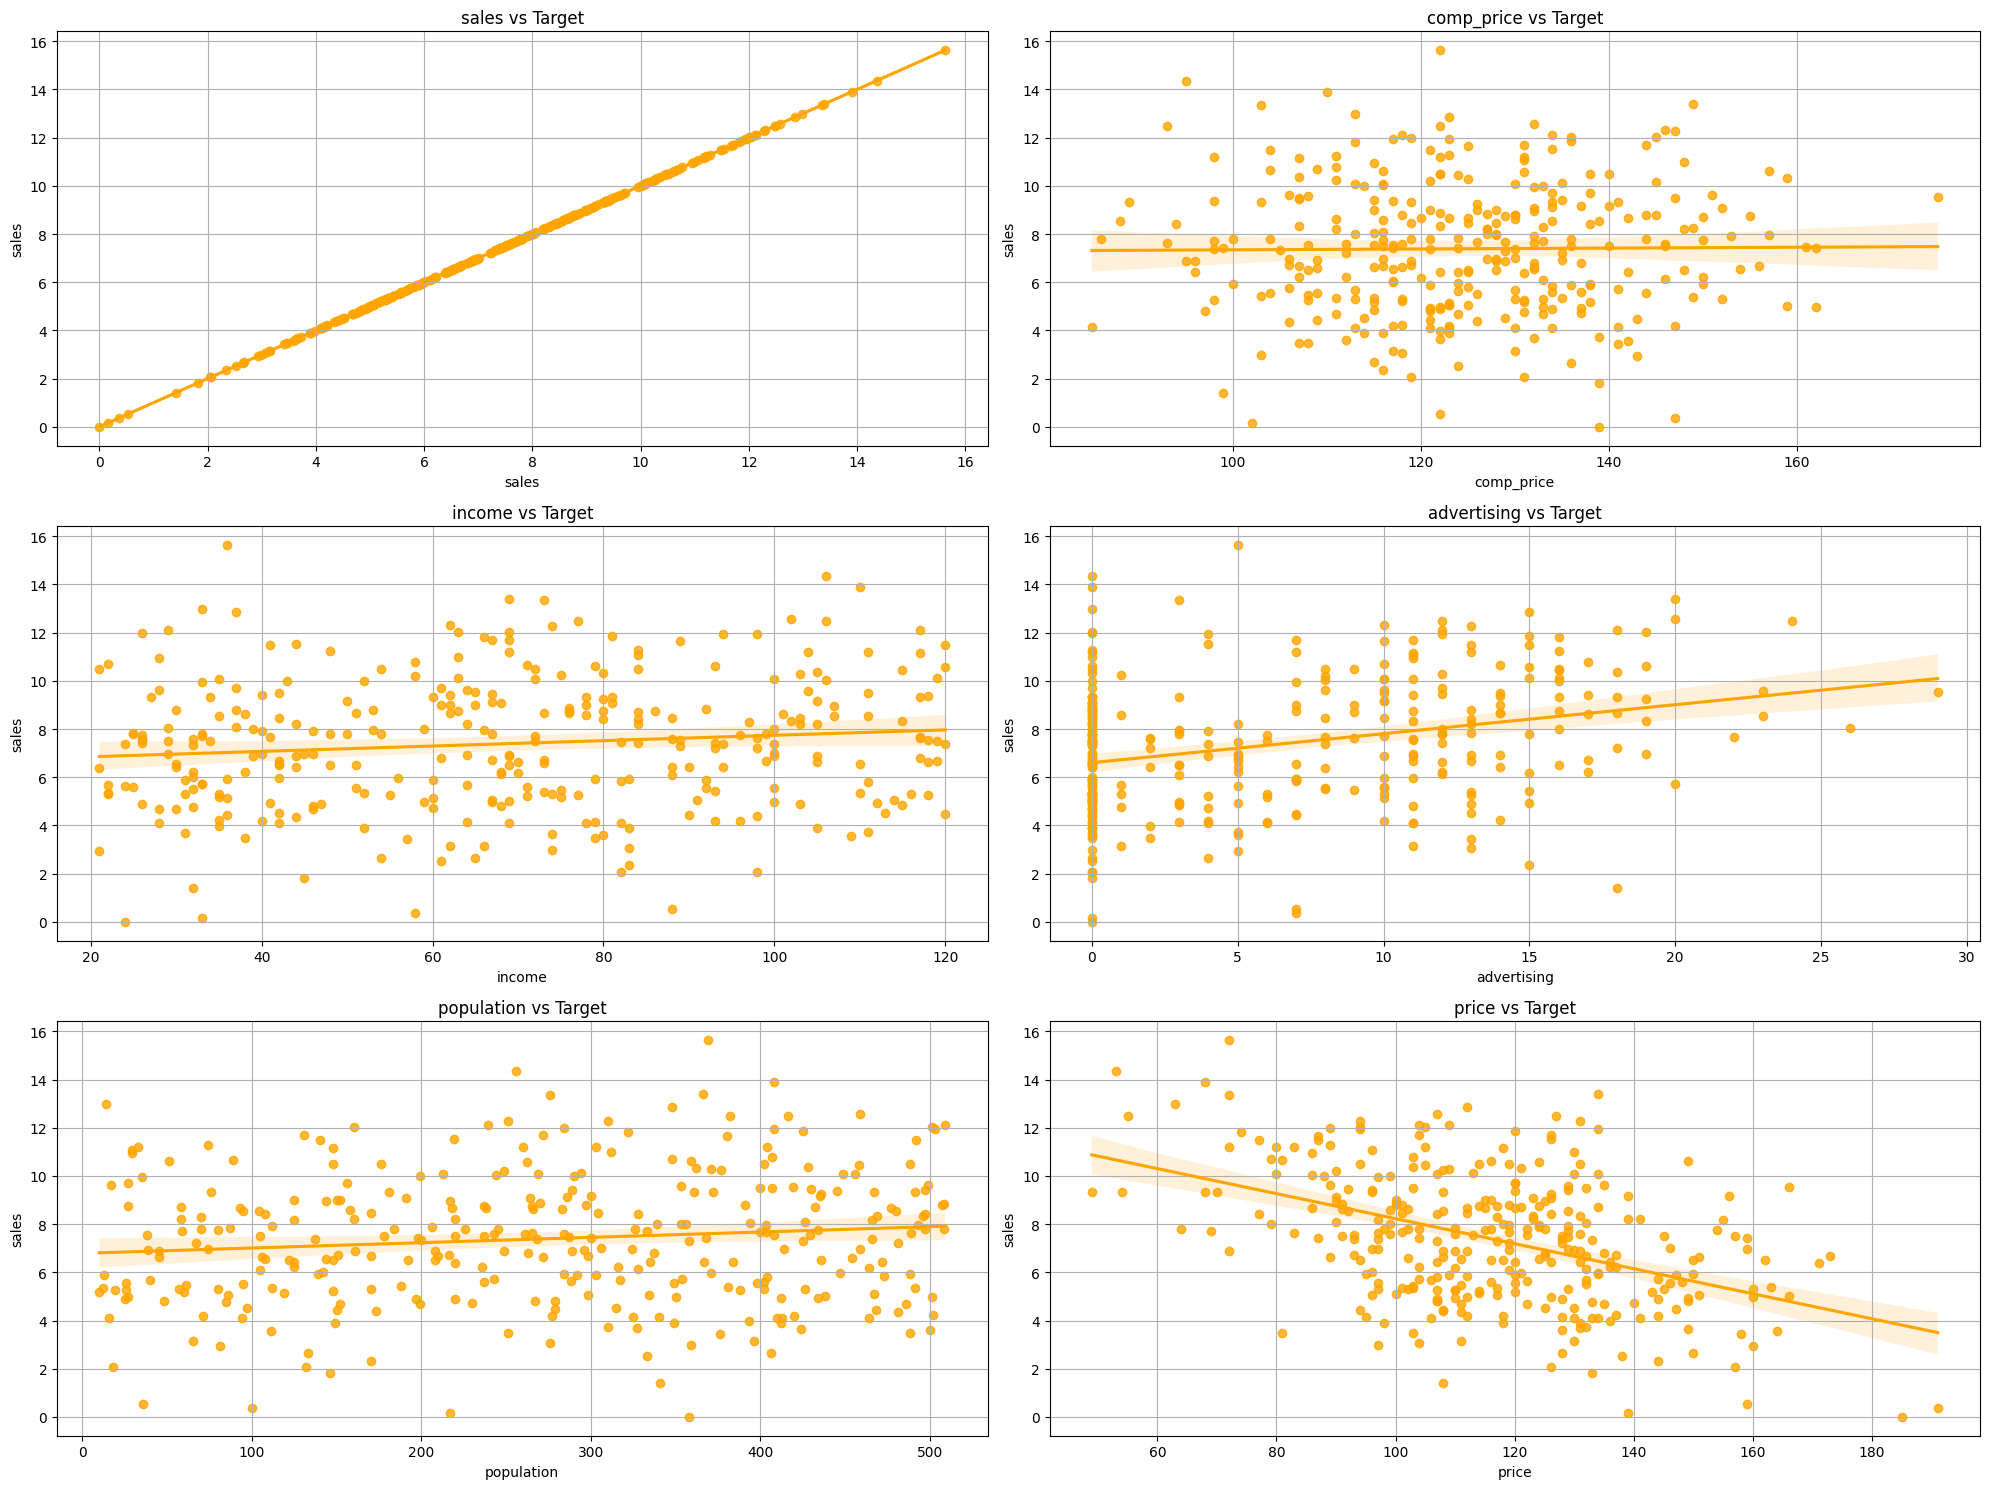

In [ ]:
x_train_sorted = df_train.select_dtypes(include=np.number)
y_train_sorted = df_train['sales']

if not isinstance(x_train_sorted, pd.DataFrame):
    x_train_sorted = pd.DataFrame(x_train_sorted)
if not isinstance(y_train_sorted, pd.Series):
    y_train_sorted = pd.Series(y_train_sorted, name='sales')

fig, ax1 = plt.subplots(3, 2, figsize=(20, 15))

columns = df_train.select_dtypes(include=np.number).columns
k = 0

for i in range(3):
    for j in range(2):
        sns.regplot(x=x_train_sorted[columns[k]], y=y_train_sorted, ax=ax1[i][j], color="orange")
        ax1[i][j].grid(True)
        ax1[i][j].set_title(f"{columns[k]} vs Target")  # Optional: Add title for clarity
        k += 1

plt.tight_layout()
plt.show()

The distribution of the target variable, Sales, appears nearly symmetrical, with the mean and median being very close. This indicates minimal skewness, suggesting that transformations of the target are likely unnecessary for this dataset.

**Distribution of Categorical Features**

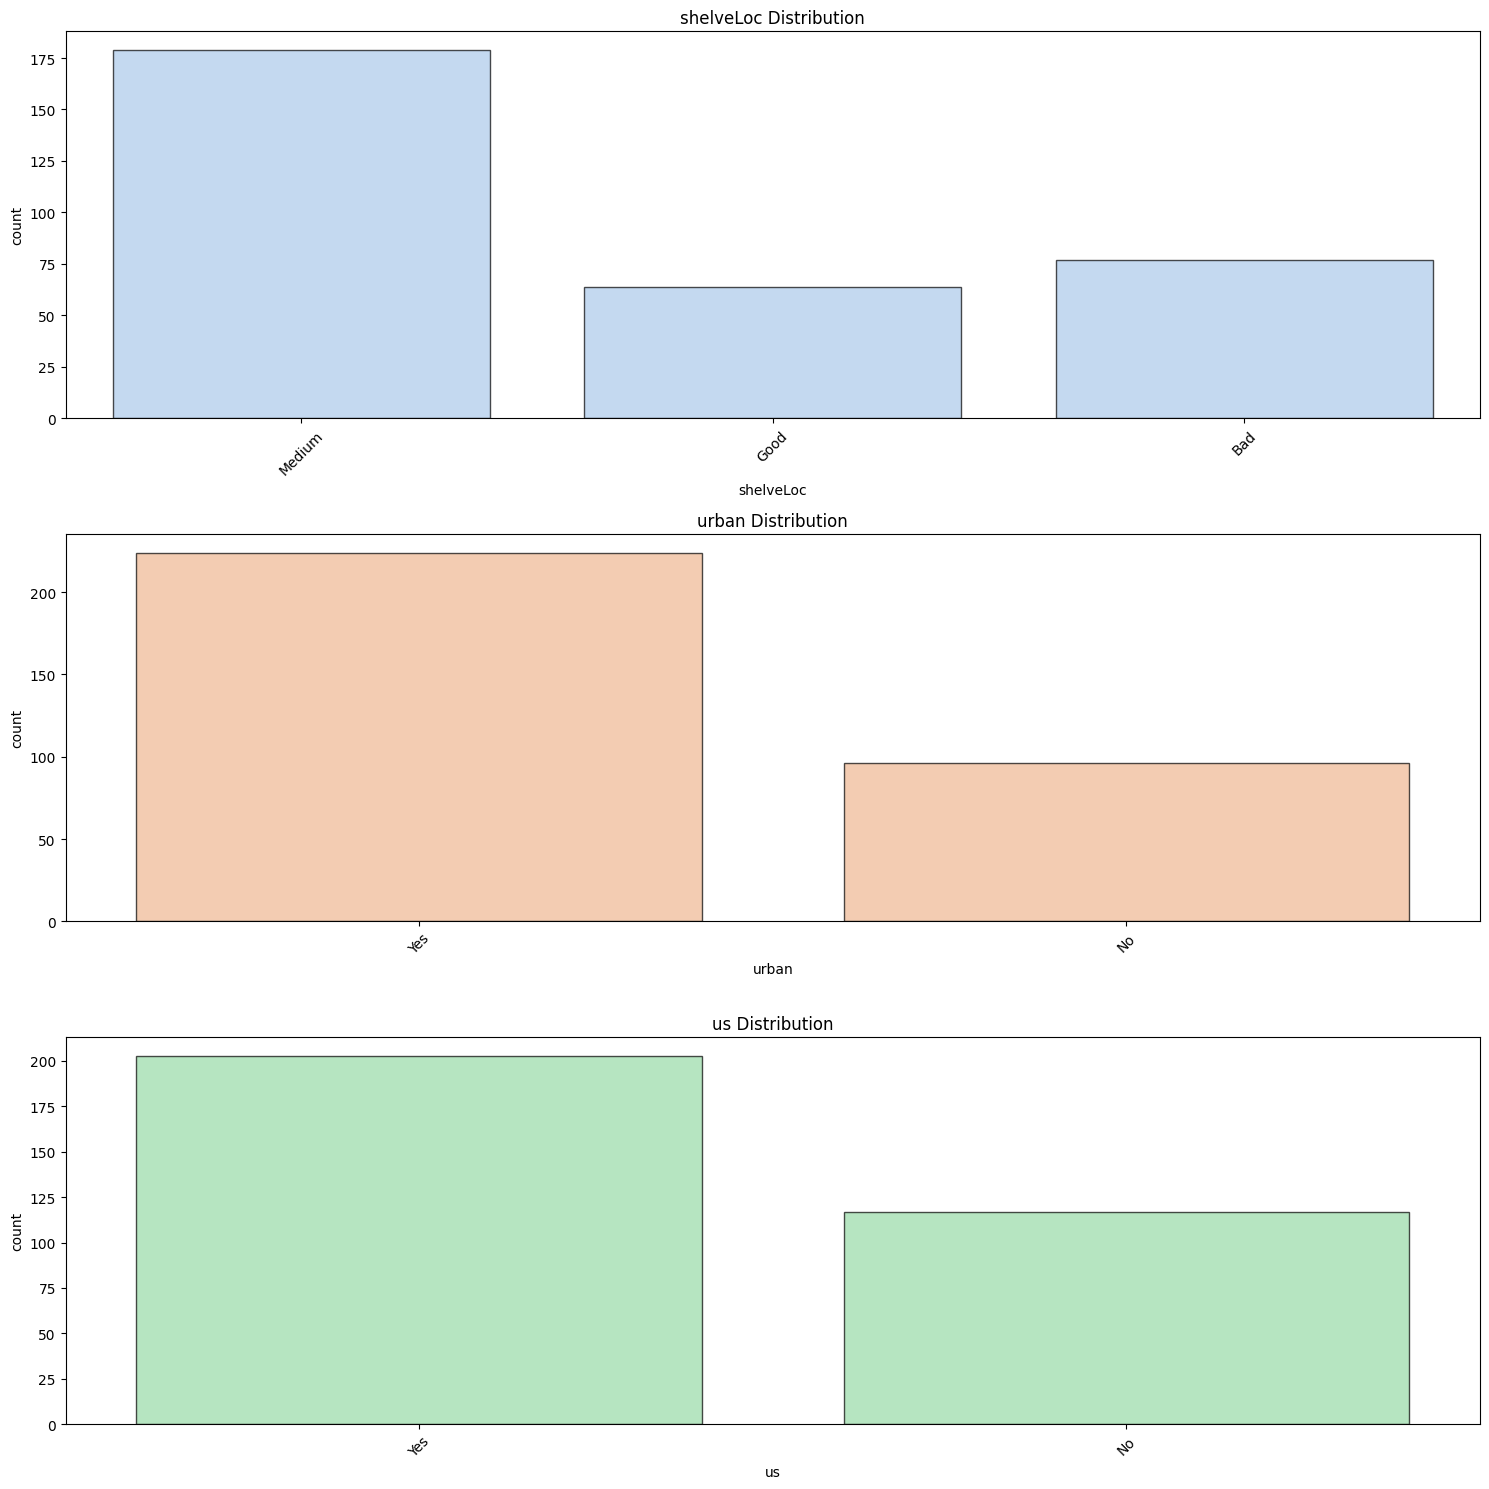

In [ ]:
categorical_cols = df_train.select_dtypes(include=['object', 'category']).columns

pastel_colors = sns.color_palette("pastel")

fig, axes = plt.subplots(len(categorical_cols), 1, figsize=(15, 5 * len(categorical_cols)))

if len(categorical_cols) == 1:
    axes = [axes]

for idx, col in enumerate(categorical_cols):
    sns.countplot(data=df_train, x=col, ax=axes[idx], 
                  color=pastel_colors[idx % len(pastel_colors)], 
                  edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'{col} Distribution')
    axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Target Labels Distribution**

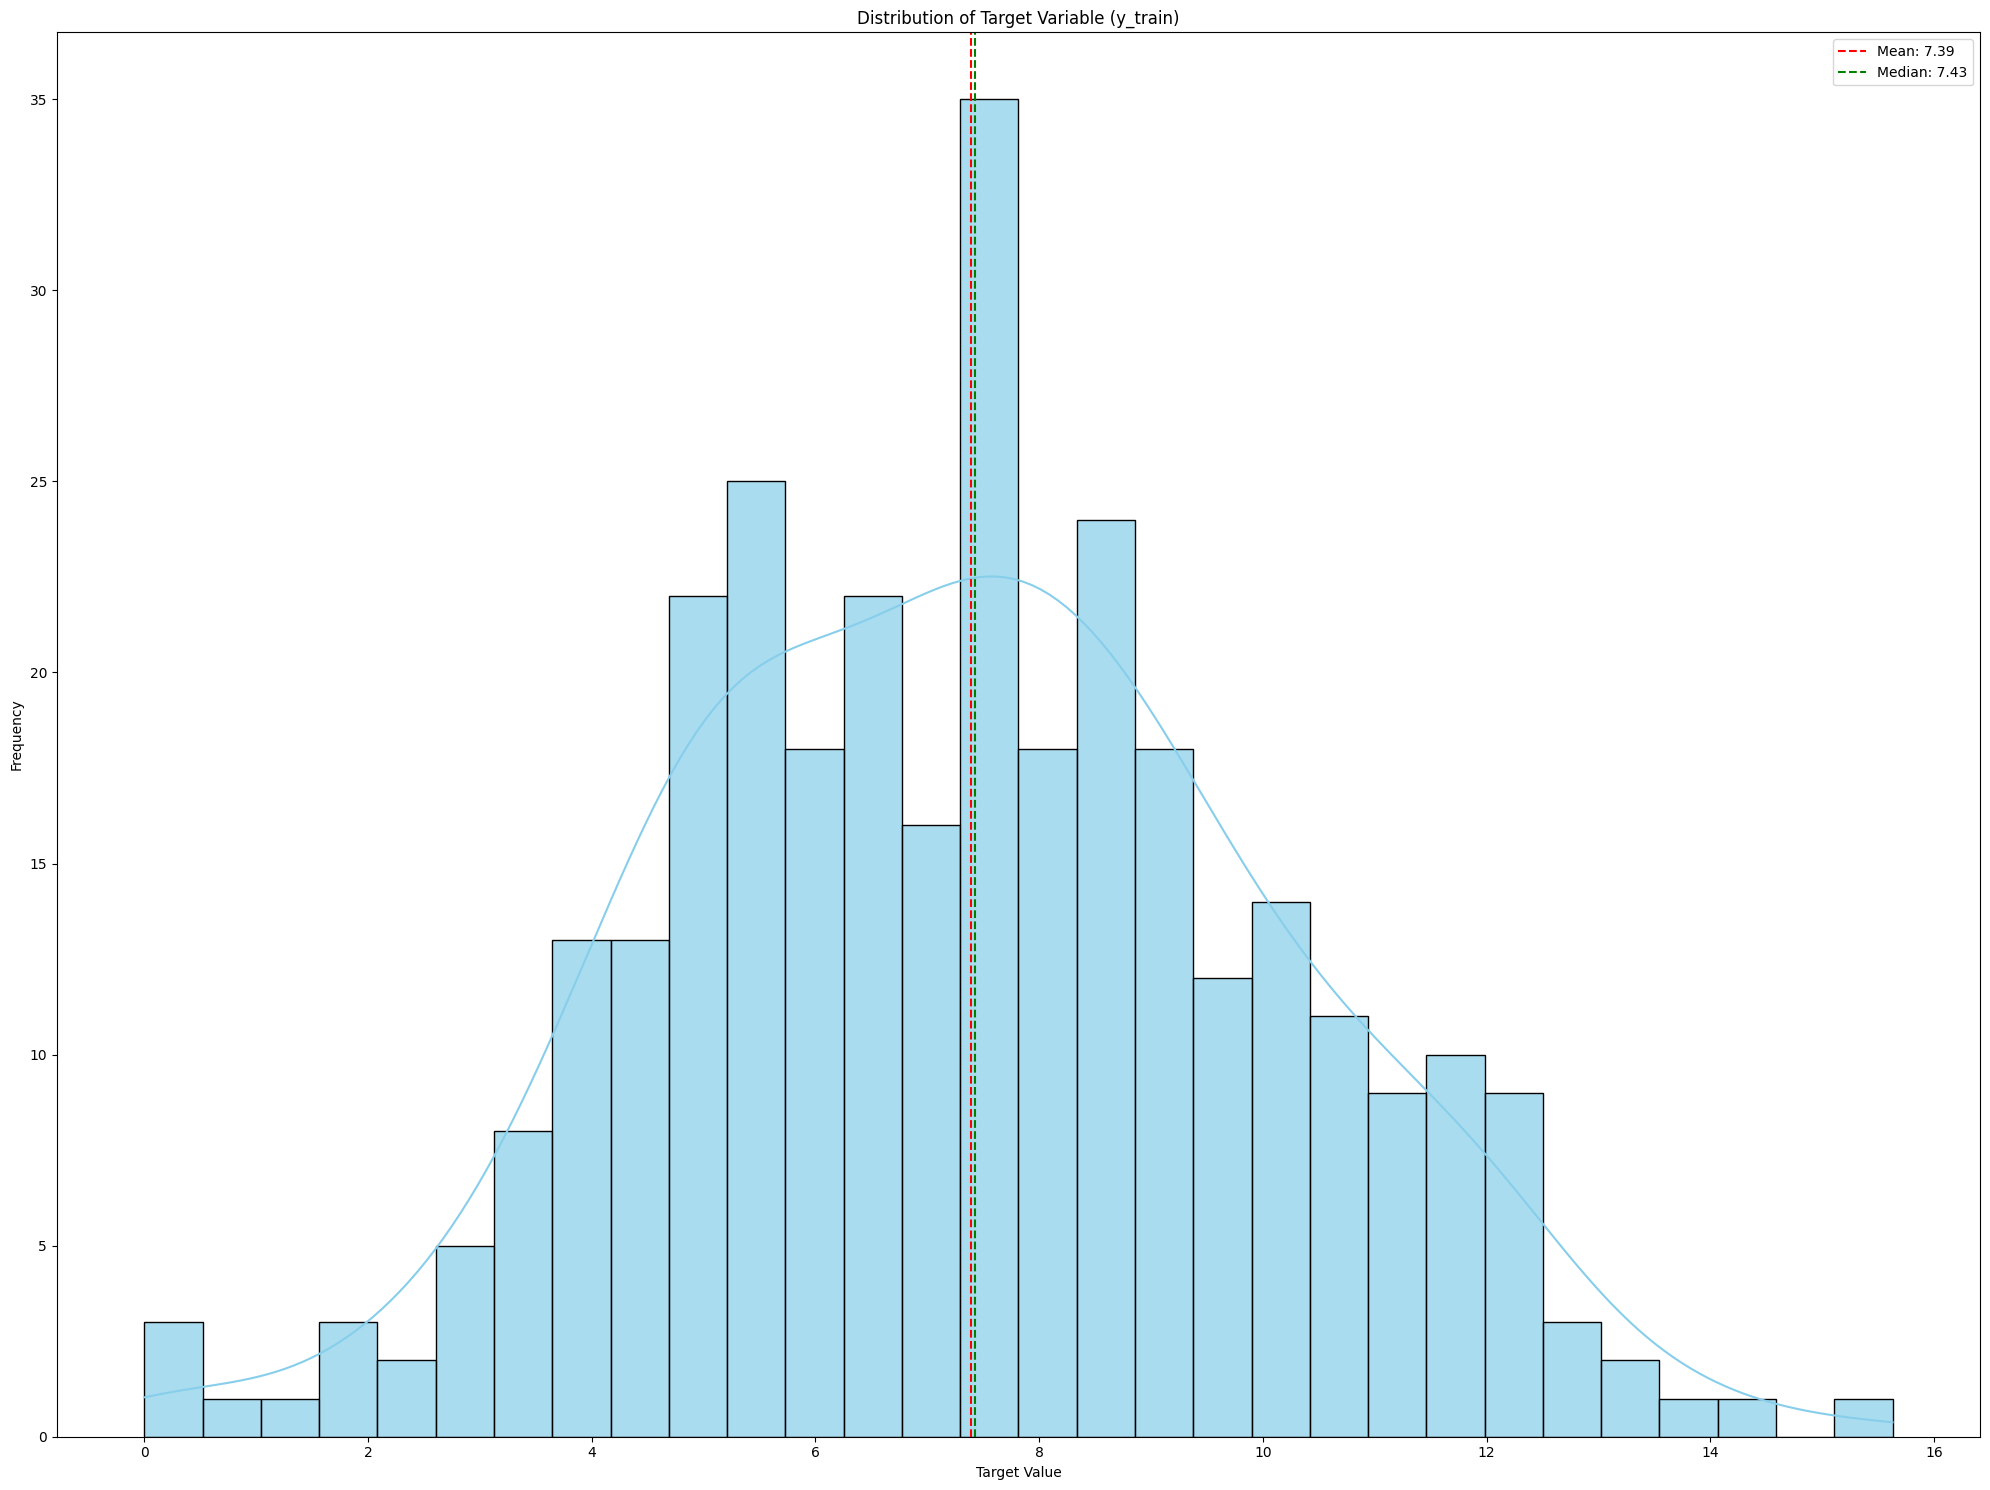

Basic Statistics of y_train:
count    320.000000
mean       7.388188
std        2.726779
min        0.000000
25%        5.327500
50%        7.425000
75%        9.180000
max       15.630000
Name: sales, dtype: float64


In [ ]:
y_train = df_train['sales']
if not isinstance(y_train, pd.Series):
    y_train = pd.Series(y_train, name='target')

plt.figure(figsize=(20, 15))

sns.histplot(data=y_train, bins=30, kde=True, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Distribution of Target Variable (y_train)')
plt.xlabel('Target Value')
plt.ylabel('Frequency')

plt.axvline(y_train.mean(), color='red', linestyle='--', label=f'Mean: {y_train.mean():.2f}')
plt.axvline(y_train.median(), color='green', linestyle='--', label=f'Median: {y_train.median():.2f}')
plt.legend()

plt.tight_layout()
plt.show()

print("Basic Statistics of y_train:")
print(y_train.describe())

The count plots for the categorical variables show a slightly uneven distribution for shelf location (shelveLoc), where 'Medium' is the most frequent category. The binary features, urban and us, show relatively balanced counts, meaning the model will have sufficient data to learn the effect of both states (Yes/No).

**Outlier Detection (Box Plots)**

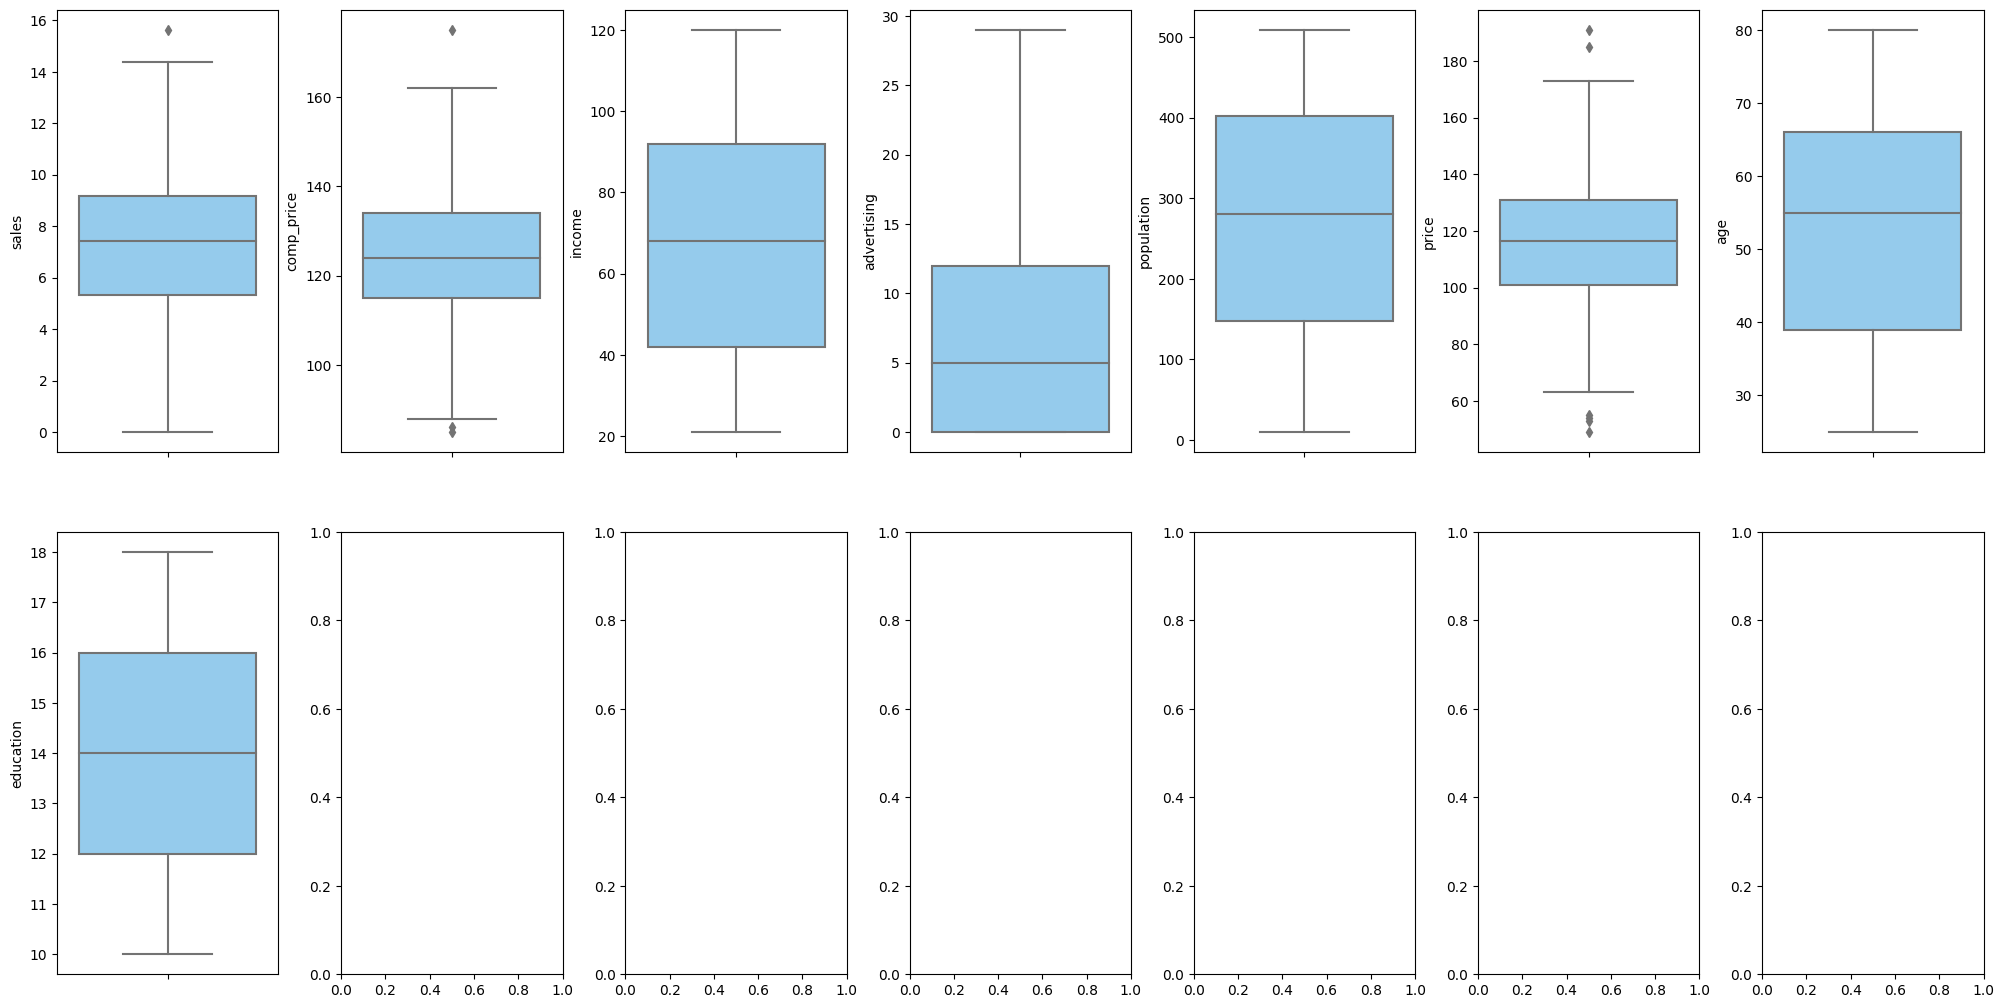

Column sales outliers = 0.31%
Column comp_price outliers = 0.94%
Column income outliers = 0.00%
Column advertising outliers = 0.00%
Column population outliers = 0.00%
Column price outliers = 1.88%
Column age outliers = 0.00%
Column education outliers = 0.00%


In [ ]:
fig, axs = plt.subplots(ncols=7, nrows=2, figsize=(20, 10))
index = 0
axs = axs.flatten()

for k, v in df_train.select_dtypes(include=['int64', 'float64']).items():
    sns.boxplot(y=v, data=df_train, ax=axs[index], color="lightskyblue")
    index += 1

plt.tight_layout(pad=0.4, w_pad=0.5, h_pad=5.0)
plt.show()

for k, v in df_train.select_dtypes(include=['int64', 'float64']).items():
    q1 = v.quantile(0.25)
    q3 = v.quantile(0.75)
    irq = q3 - q1
    v_col = v[(v <= q1 - 1.5 * irq) | (v >= q3 + 1.5 * irq)]
    perc = np.shape(v_col)[0] * 100.0 / np.shape(df_train)[0]
    print("Column %s outliers = %.2f%%" % (k, perc))

The box plots and outlier calculations reveal that most numerical features are relatively clean, with low or zero outlier percentages. Only the Sales target, CompPrice, and Price features exhibit a minor percentage of outliers (all below $2%$), which is generally acceptable for robust regression methods like Decision Trees.

**Correlation Analysis**

A heatmap visualization of the correlation matrix for all numerical features is generated. This identifies both relationships between predictors and the relationship between predictors and the target. High correlation ($\approx \pm 1$) between two predictors (multicollinearity) can be problematic for linear models but typically less so for tree-based models. Strong positive or negative correlation between a feature and the target confirms its importance for prediction.

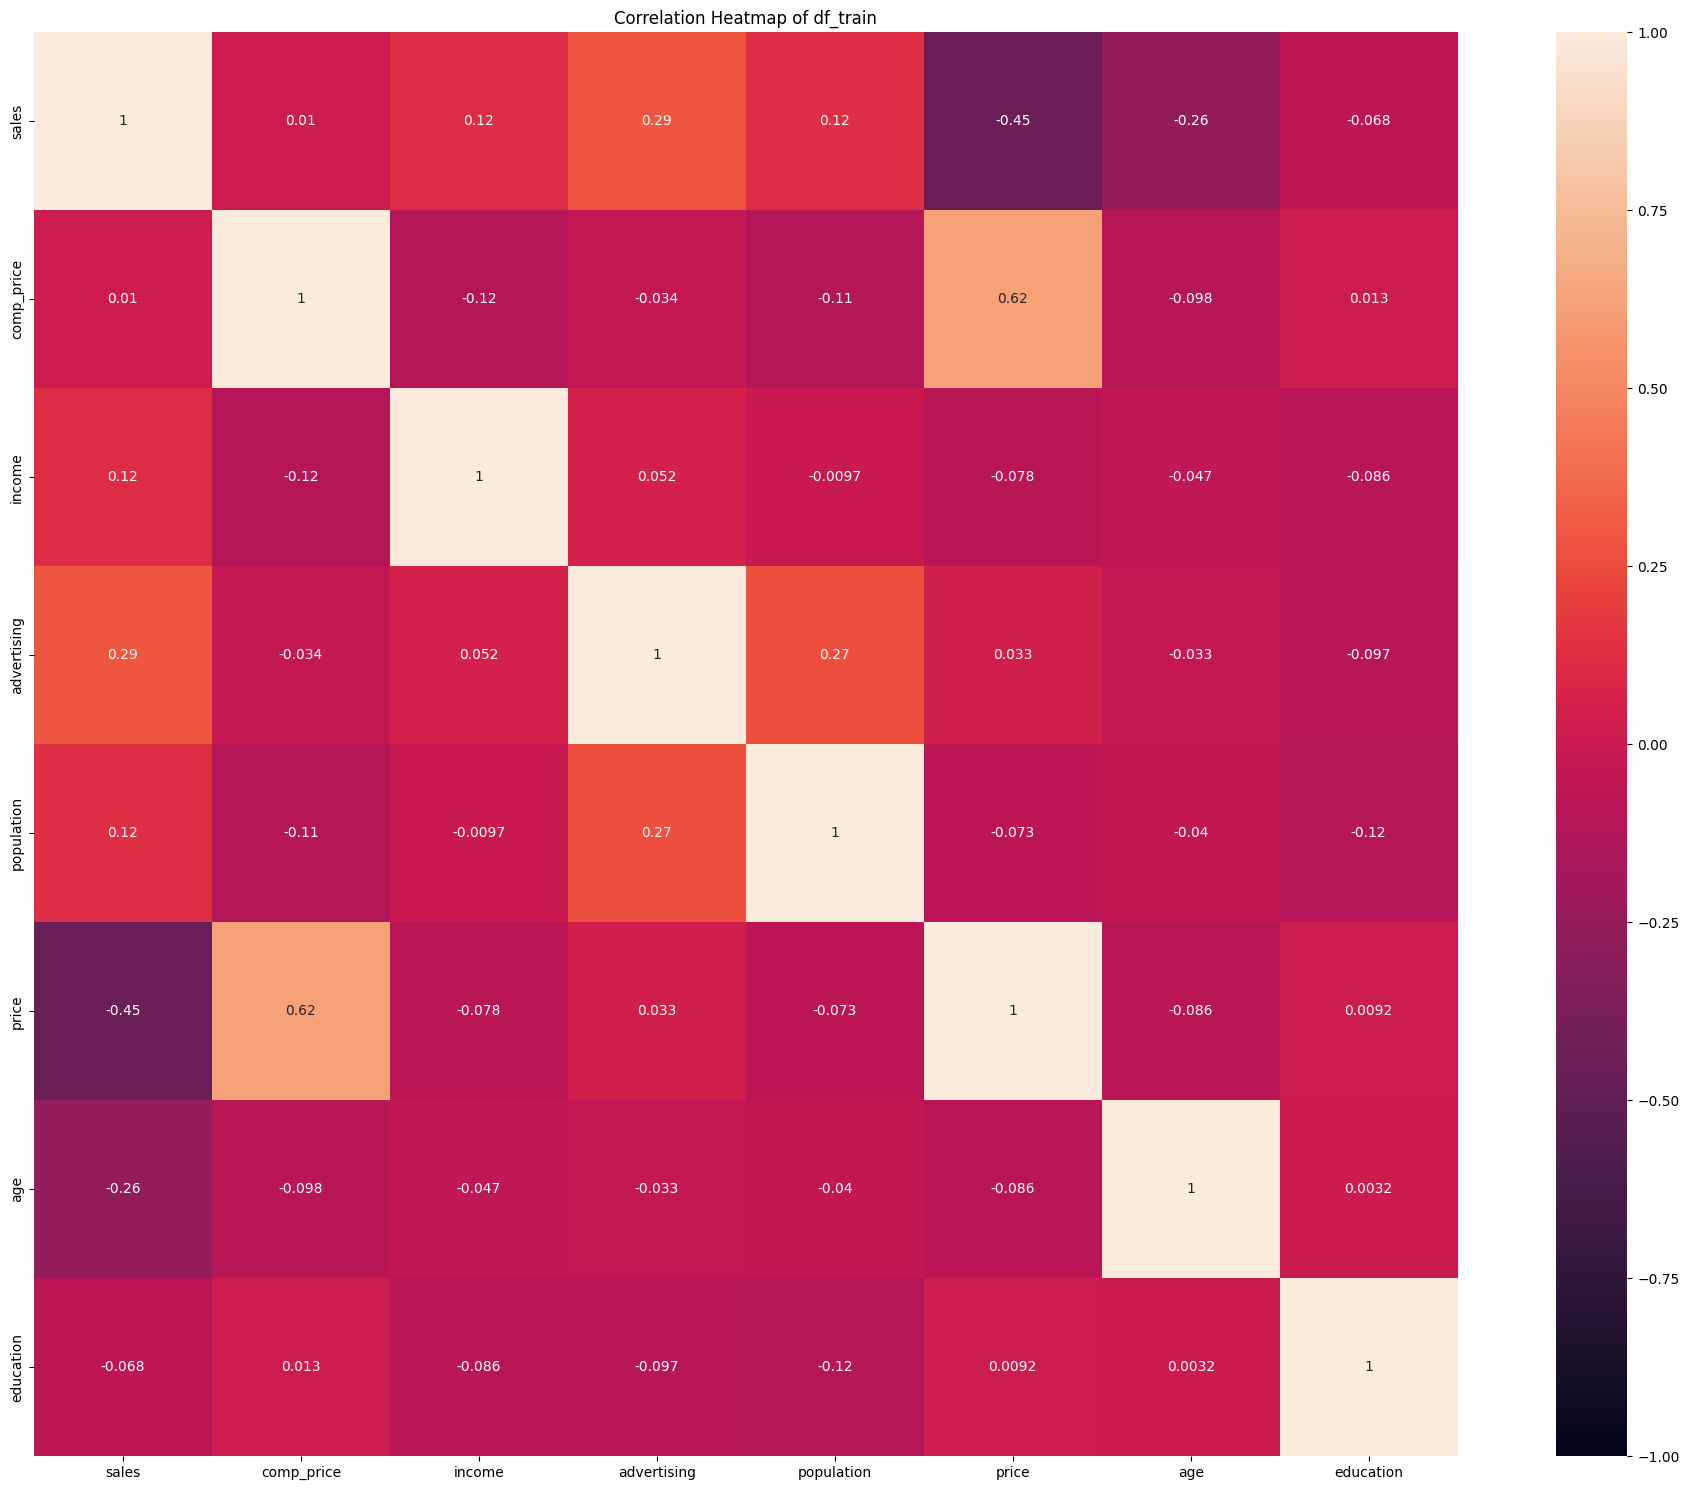

In [ ]:
numeric_df = df_train.select_dtypes(include=['int64', 'float64'])
correlation_matrix = numeric_df.corr()

plt.figure(figsize=(20, 15))
sns.heatmap(correlation_matrix, annot=True, cmap='rocket', vmin=-1, vmax=1, center=0, square=True)
plt.title('Correlation Heatmap of df_train')
plt.tight_layout()
plt.show()

**Feature Relationships (Bivariate and Correlation)**

The regression plots show distinct relationships between the numerical features and the target Sales:
- Advertising: Exhibits a clear positive, nearly linear trend with Sales, suggesting that increased advertising budget strongly correlates with higher sales.
- Price: Displays a clear negative trend with Sales, indicating that as the price increases, sales tend to decrease, which aligns with expected economic behavior.
- CompPrice, Income, and Age: Show either weak or negligible linear relationships with Sales, suggesting their influence might be non-linear or overshadowed by other factors.

The correlation heatmap confirms these observations. The target variable, Sales, shows the highest magnitude of correlation with Price (strong negative) and Advertising (strong positive). Crucially, a strong negative correlation is observed between Price and CompPrice (competitor price), suggesting potential interaction effects or relative pricing strategies. This comprehensive EDA confirms the data quality, highlights the most predictive features (Price and Advertising), and indicates a straightforward path for preprocessing due to the absence of missing values and the general robustness of the numerical data.

# Features Engineering

**Features and Target Labels Split**

Feature Engineering prepares the input data for model consumption by transforming raw features into a format that maximizes predictive performance. The process involves isolating the target variable ($\mathbf{y}$) from the predictor variables ($\mathbf{X}$) in both the training and testing sets to maintain a clean separation.

In [ ]:
y_train = df_train['sales'] 
x_train = df_train.drop('sales', axis=1) 
y_test = df_test['sales'] 
x_test = df_test.drop('sales', axis=1) 

print("X_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (320, 10)
y_train shape: (320,)
X_test shape: (80, 10)
y_test shape: (80,)


**Categorical Feature Encoding**

Decision Trees and ensemble methods can only process numerical data. The three object-type categorical features in the dataset require conversion. Ordinal Encoding is selected for this task, as it maps each unique category to a unique integer. This method is appropriate for tree-based models because:
- Invariance to Scale: Unlike distance-based models (like K-Nearest Neighbors or Support Vector Machines), tree models are not affected by the magnitude or arbitrary numerical assignment of the features. They rely on finding optimal thresholds ($\mathbf{x}_i \leq \text{threshold}$) for splitting, and Ordinal Encoding preserves the necessary ordering information (if implicit) or simply provides unique values for non-ordinal features.
- Preventing Data Leakage: The `OrdinalEncoder` is first fitted exclusively on the training data. This learned mapping is then applied to both the training and testing sets, ensuring that the model is not exposed to any information or categories unique to the test set during the training phase.

In [ ]:
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

x_train_encoded = encoder.fit_transform(x_train)

x_test_encoded = encoder.transform(x_test)

x_train = pd.DataFrame(x_train_encoded, columns=x_train.columns)
x_test = pd.DataFrame(x_test_encoded, columns=x_test.columns)

x_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 320 entries, 0 to 319
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   comp_price   320 non-null    float64
 1   income       320 non-null    float64
 2   advertising  320 non-null    float64
 3   population   320 non-null    float64
 4   price        320 non-null    float64
 5   shelveLoc    320 non-null    float64
 6   age          320 non-null    float64
 7   education    320 non-null    float64
 8   urban        320 non-null    float64
 9   us           320 non-null    float64
dtypes: float64(10)
memory usage: 25.1 KB


In [15]:
x_train_nopca = x_train.copy()
x_test_nopca = x_test.copy()

**Dimensionality Reduction (PCA)**

Following encoding, all features are numerical. Principal Component Analysis (PCA) is then applied, but specifically and solely for data visualization, not for model training (which uses the full feature set, stored in `x_train_nopca`).

PCA is an unsupervised linear dimensionality reduction technique. It transforms the original, potentially correlated features into a new set of orthogonal (uncorrelated) variables called Principal Components (PCs). The first principal component (PC1) captures the largest possible variance in the data, the second (PC2) captures the next largest, and so on. By selecting only the top two components, the high-dimensional data can be projected onto a 2D plane while retaining the maximum amount of structural variance. This projection is essential for visually inspecting the feature space and understanding how the different target values distribute themselves.

In [ ]:
pca = PCA(n_components=2) 
x_train = pca.fit_transform(x_train) 
x_test = pca.transform(x_test)    

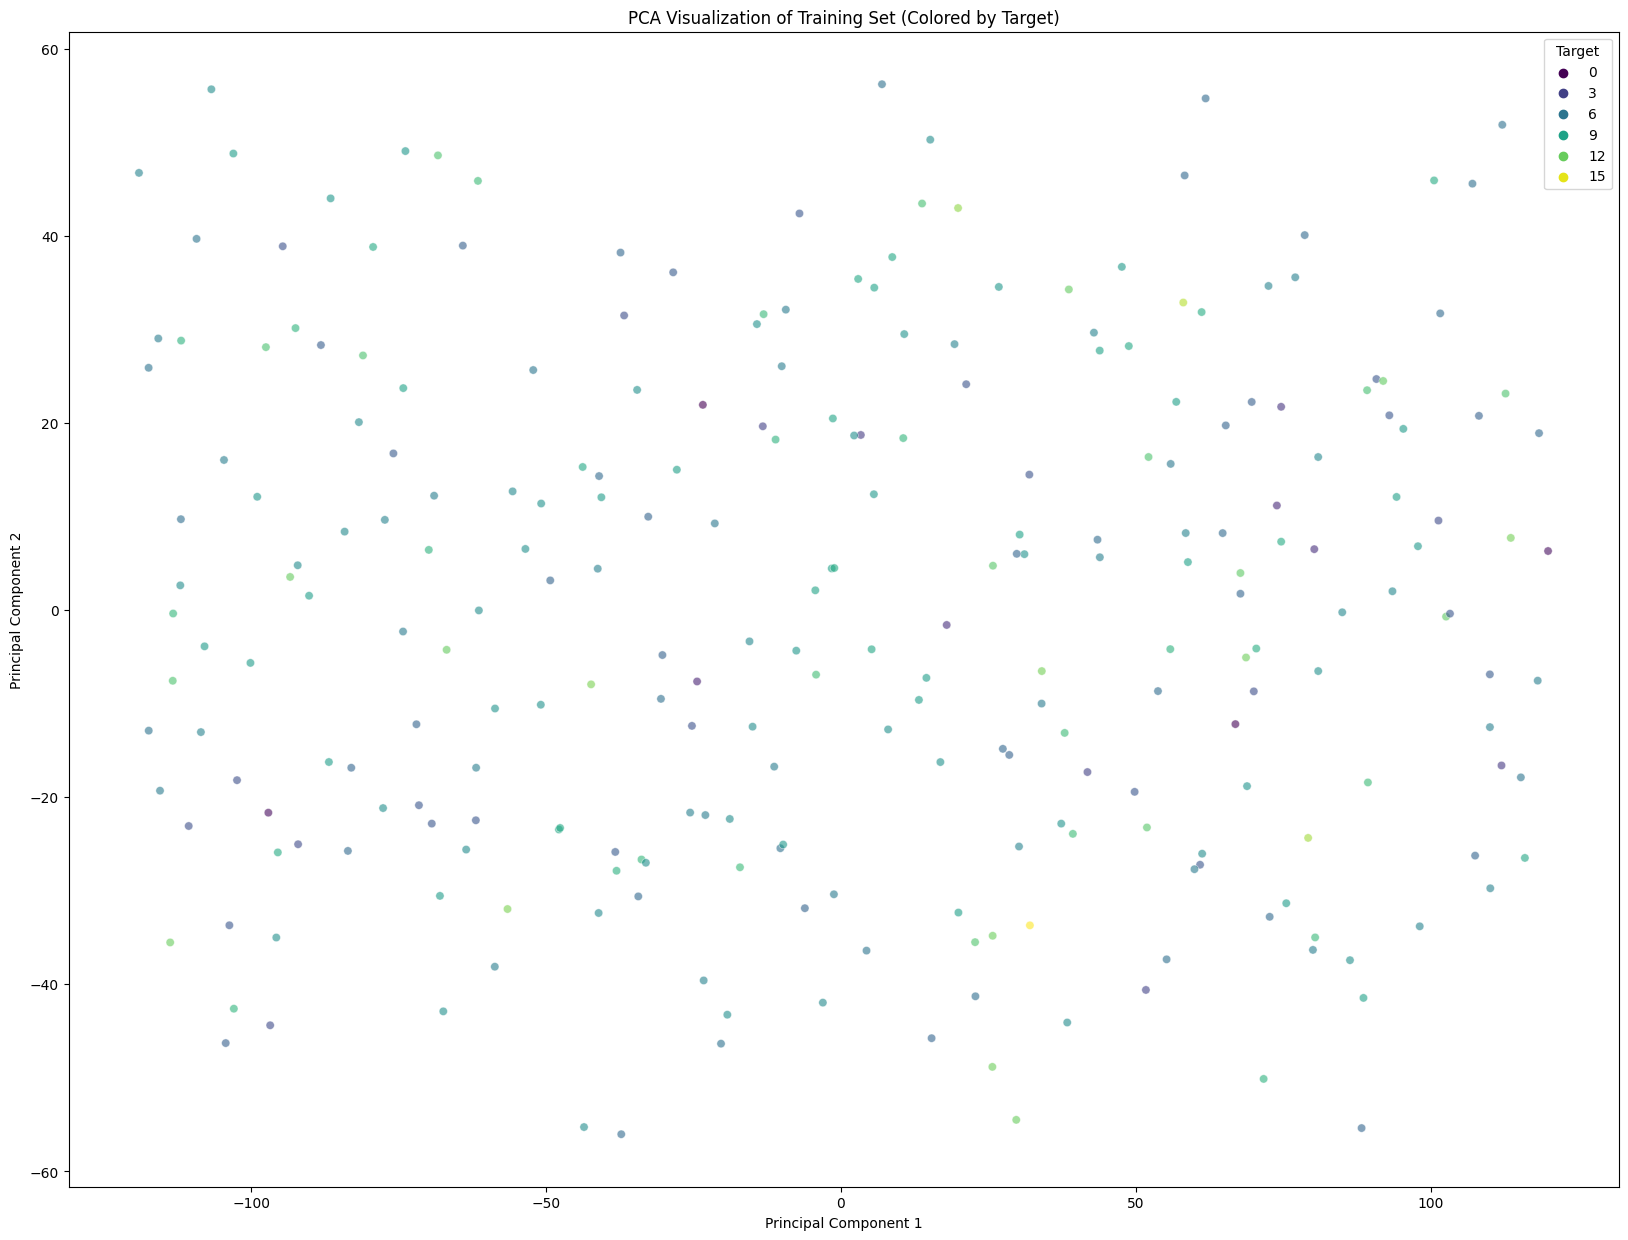

In [ ]:
x_train_pca_df = pd.DataFrame(x_train, columns=['PC1', 'PC2'])
x_test_pca_df = pd.DataFrame(x_test, columns=['PC1', 'PC2'])

plot_data = pd.DataFrame({
    'PC1': x_train_pca_df['PC1'],
    'PC2': x_train_pca_df['PC2'],
    'Target': y_train
})

plt.figure(figsize=(20, 15))
sns.scatterplot(
    data=plot_data,
    x="PC1",
    y="PC2",
    hue="Target",
    palette="viridis",
    alpha=0.6
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization of Training Set (Colored by Target)")

plt.show()

# Model Training

The objective of this modeling step is to evaluate two tree-based regression algorithms, the Decision Tree Regressor (DTR) and the Extra Tree Regressor (ETR), using robust cross-validation, and subsequently analyze the models' structural complexity using pruning techniques.

**Decision Tree Regressor (`sklearn.tree.DecisionTreeRegressor`)**

The Decision Tree Regressor is a model that approximates a continuous function by partitioning the feature space into a set of rectangular regions. The prediction for any point is the mean target value of the training data points that fall into that specific region.

**Core Mechanism: Recursive Binary Splitting**

The tree is built top-down using a greedy approach, meaning at each node, the best feature and split threshold are chosen to locally optimize the split, without considering the overall future structure of the tree.

**Splitting Criterion (Impurity Measure):** In scikit-learn, the splitting criteria for regression are generally measures of impurity that aim to minimize the variance within the child nodes. The default and most common criterion is:
- `squared_error` (formerly mse): This criterion computes the Mean Squared Error (MSE) of the target values within each node. The split chosen is the one that minimizes the total weighted MSE of the resulting child nodes. This is equivalent to variance reduction.

$$\text{MSE}(\text{Node}) = \frac{1}{N} \sum_{i \in \text{Node}} (y_i - \bar{y}_{\text{Node}})^2$$
- `friedman_mse`: This is an improvement over standard MSE that incorporates a potential reduction gain from non-constant splits, often leading to better performance, especially when using ensemble methods.
- `absolute_error` (mae): Measures the Mean Absolute Error (MAE), which is more robust to outliers than squared error.
- `poisson`: Used for target variables that follow a Poisson distribution (e.g., counts).

**Regularization Hyperparameters (Preventing Overfitting)**

Single decision trees are highly susceptible to overfitting, leading to high variance. Scikit-learn provides several critical parameters to control the complexity:
- `max_depth`: Defines the maximum allowed depth of the tree. Limiting depth is the most direct way to prevent the model from learning extremely fine-grained, noisy patterns in the training data.
- `min_samples_split`: The minimum number of samples required to split an internal node. Increasing this value forces the tree to make splits only on large, reliable groups of data.
- `min_samples_leaf`: The minimum number of samples required to be at a leaf node. This ensures that every prediction is based on a sufficiently large group of observations, promoting stability.
- `max_features`: The number of features to consider when looking for the best split. Setting this to a value less than the total number of features introduces randomness and is fundamental to ensemble methods like Random Forest, though it can be used on single trees as well.
- `ccp_alpha (Cost-Complexity Pruning)`: A non-negative value used for Minimal Cost-Complexity Pruning. A larger value increases the amount of pruning, simplifying the tree structure and controlling overfitting by penalizing complexity.

**Extremely Randomized Trees Regressor (`sklearn.ensemble.ExtraTreesRegressor`)**

The Extra Trees Regressor is an ensemble method that fits multiple randomized Decision Tree Regressors on the data and aggregates their individual predictions by averaging. This technique is designed to reduce the variance associated with individual tree models, leading to a more robust final prediction.

**Key Randomization Differences (The "Extra" Step)**

Extra Trees introduces two critical randomization steps compared to a standard Random Forest:
- Non-Bootstrap Sampling: By default (`bootstrap=False`), each tree in the ensemble is trained on the entire original training dataset, rather than a bootstrapped subset. This reduces the risk of bias from using incomplete data subsets.
- Random Split Thresholds: This is the defining characteristic. Instead of exhaustively searching for the optimal split threshold for each candidate feature at every node (which minimizes the impurity), the Extra Tree algorithm selects a random threshold for a random subset of features. It then simply picks the best split among these randomly generated choices.

**Impact on Performance and Training**

- Reduced Variance: The strong randomization in split points leads to individual trees that are highly diverse (decorrelated). Averaging these diverse predictions significantly reduces the overall model variance and minimizes overfitting.
- Computational Efficiency: Since the algorithm skips the computationally expensive optimization step of finding the truly best split threshold, Extra Trees is typically faster to train than standard Decision Trees or Random Forests, especially for large datasets.

**Key Scikit-learn Parameters Specific to Ensemble**

- `n_estimators`: The number of trees in the ensemble. More trees generally lead to better performance and lower variance, but at increased computational cost.
- `bootstrap`: If set to True, trees are built using bootstrapped samples, similar to Random Forest. The default is False to maintain the "Extra Tree" randomization principle.
- `max_features`: Used to select the random subset of features considered for splitting. This parameter is crucial in ensemble methods for introducing necessary diversity among the trees.

**Initial Model Training**

The Decision Tree Regressor is a non-parametric method that constructs a model by recursively partitioning the feature space into regions. The prediction for a given data point is the average target value of all training points that fall into that region (leaf). The Extra Tree Regressor is a variation of the DTR where the split point for each feature is chosen randomly, rather than calculating the optimal threshold. This randomness introduces bias but often reduces the variance of the model, which can improve generalization performance.

Model performance is assessed using K-Fold Cross-Validation with $\text{K}=10$ folds. This technique divides the training data into ten segments, iteratively using nine segments for training and one for validation. This procedure yields ten performance scores, which are averaged to provide a reliable estimate of how well the model generalizes.

The chosen metric is the Negative Mean Squared Error (NMSE). The goal of regression is to minimize the Mean Squared Error (MSE), which measures the average squared difference between the predicted and actual values. By taking the negative of this value, the optimization problem is recast as maximization, aligning with standard hyperparameter tuning practices.

In [ ]:
ml_models = [
    ("DecisionTreeRegressor", DecisionTreeRegressor(random_state=42)), 
    ("ExtraTreeRegressor", ExtraTreeRegressor(random_state=42)),       
]

for name, model in ml_models:
    print(f"{name}: ")
    model.fit(x_train, y_train) 
    cv_scores = cross_val_score(model, x_train, y_train, cv=10, scoring='neg_mean_squared_error') 
    print("\tK-Fold Cross-Validation (Negative Mean Squared Error):", cv_scores)
    print('-'*100)
    print(f'\tAverage K-Fold Cross-Validation (Negative Mean Squared Error): {cv_scores.mean()}')
    print('-'*100)

DecisionTreeRegressor: 
	K-Fold Cross-Validation (Negative Mean Squared Error): [-12.490225   -14.13863437 -14.6019625  -14.42106875 -15.35788437
 -10.94166875 -17.82844375 -13.28423438 -16.47509375 -16.27527812]
----------------------------------------------------------------------------------------------------
	Average K-Fold Cross-Validation (Negative Mean Squared Error): -14.581449375
----------------------------------------------------------------------------------------------------
ExtraTreeRegressor: 
	K-Fold Cross-Validation (Negative Mean Squared Error): [-14.25085938 -13.96175    -16.64424688 -13.44144375 -14.59479375
 -13.47466875 -21.47796563 -15.37464063 -14.82117812 -15.70874375]
----------------------------------------------------------------------------------------------------
	Average K-Fold Cross-Validation (Negative Mean Squared Error): -15.3750290625
----------------------------------------------------------------------------------------------------


**Model Comparison**

The cross-validation results show that the Decision Tree Regressor achieves a slightly higher average Negative Mean Squared Error (closer to zero), indicating marginally superior predictive performance on the training data compared to the Extra Tree Regressor under the current default settings. The variability in scores across the ten folds is substantial for both models, suggesting that the model performance is sensitive to the specific subset of training data used.

**Decision Surface Visualization**

To understand how the models make predictions, the decision surface is visualized. This process fixes all features except for the two most prominent (the first two in the dataset) and plots the model's prediction across a 2D grid defined by these features. The plot reveals the piecewise constant nature of the tree-based predictions, where the prediction value remains uniform within the rectangular regions defined by the splits.

DecisionTreeRegressor: 
	K-Fold Cross-Validation (Negative Mean Squared Error): [-12.490225   -14.13863437 -14.6019625  -14.42106875 -15.35788437
 -10.94166875 -17.82844375 -13.28423438 -16.47509375 -16.27527812]
----------------------------------------------------------------------------------------------------
	Average K-Fold Cross-Validation (Negative Mean Squared Error): -14.581449375
----------------------------------------------------------------------------------------------------


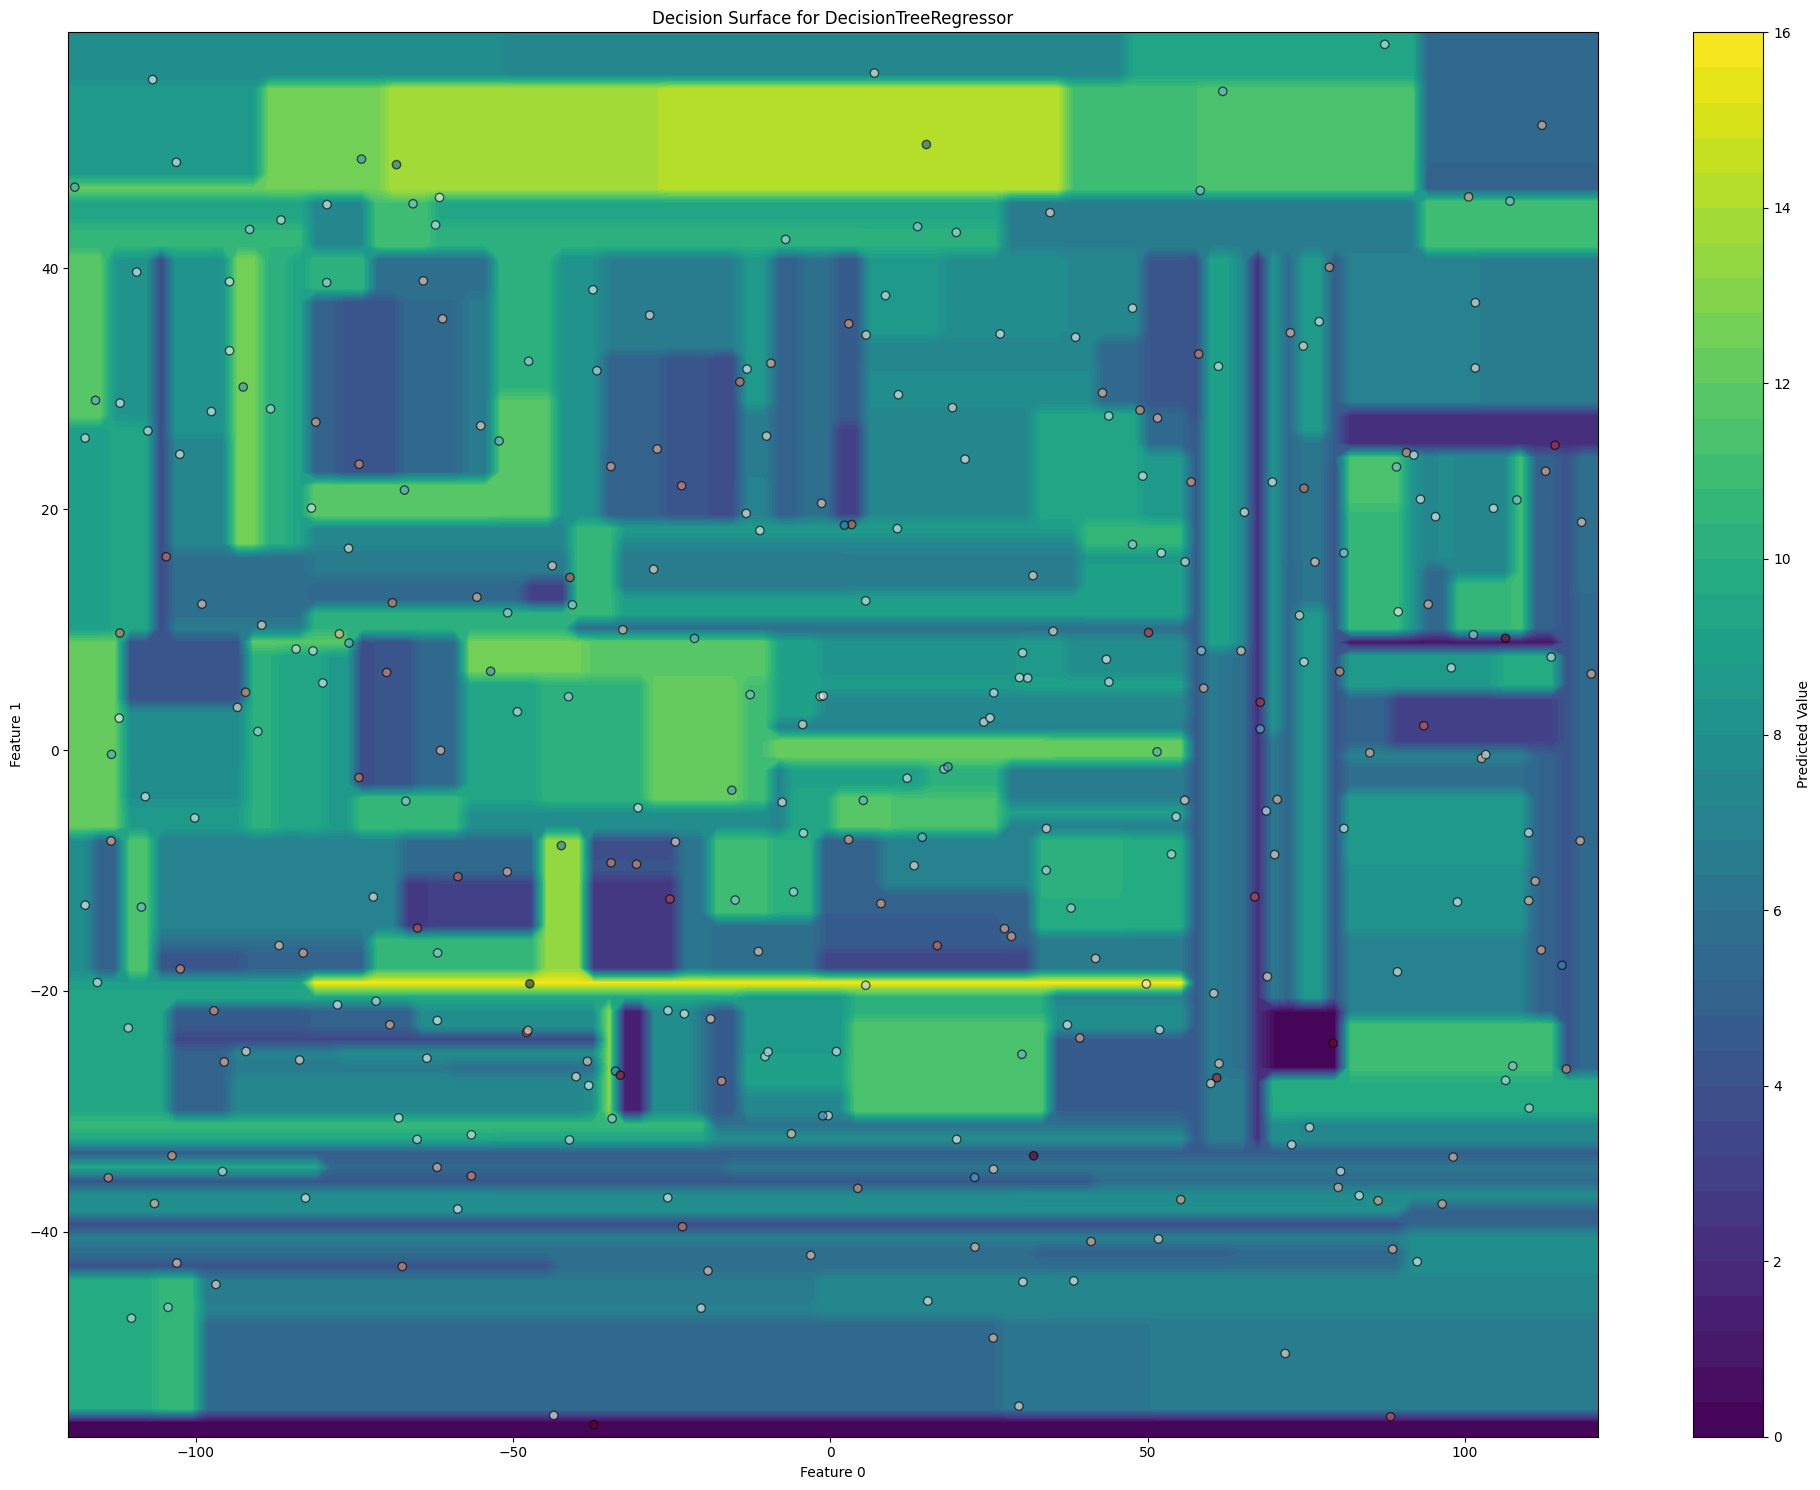

----------------------------------------------------------------------------------------------------


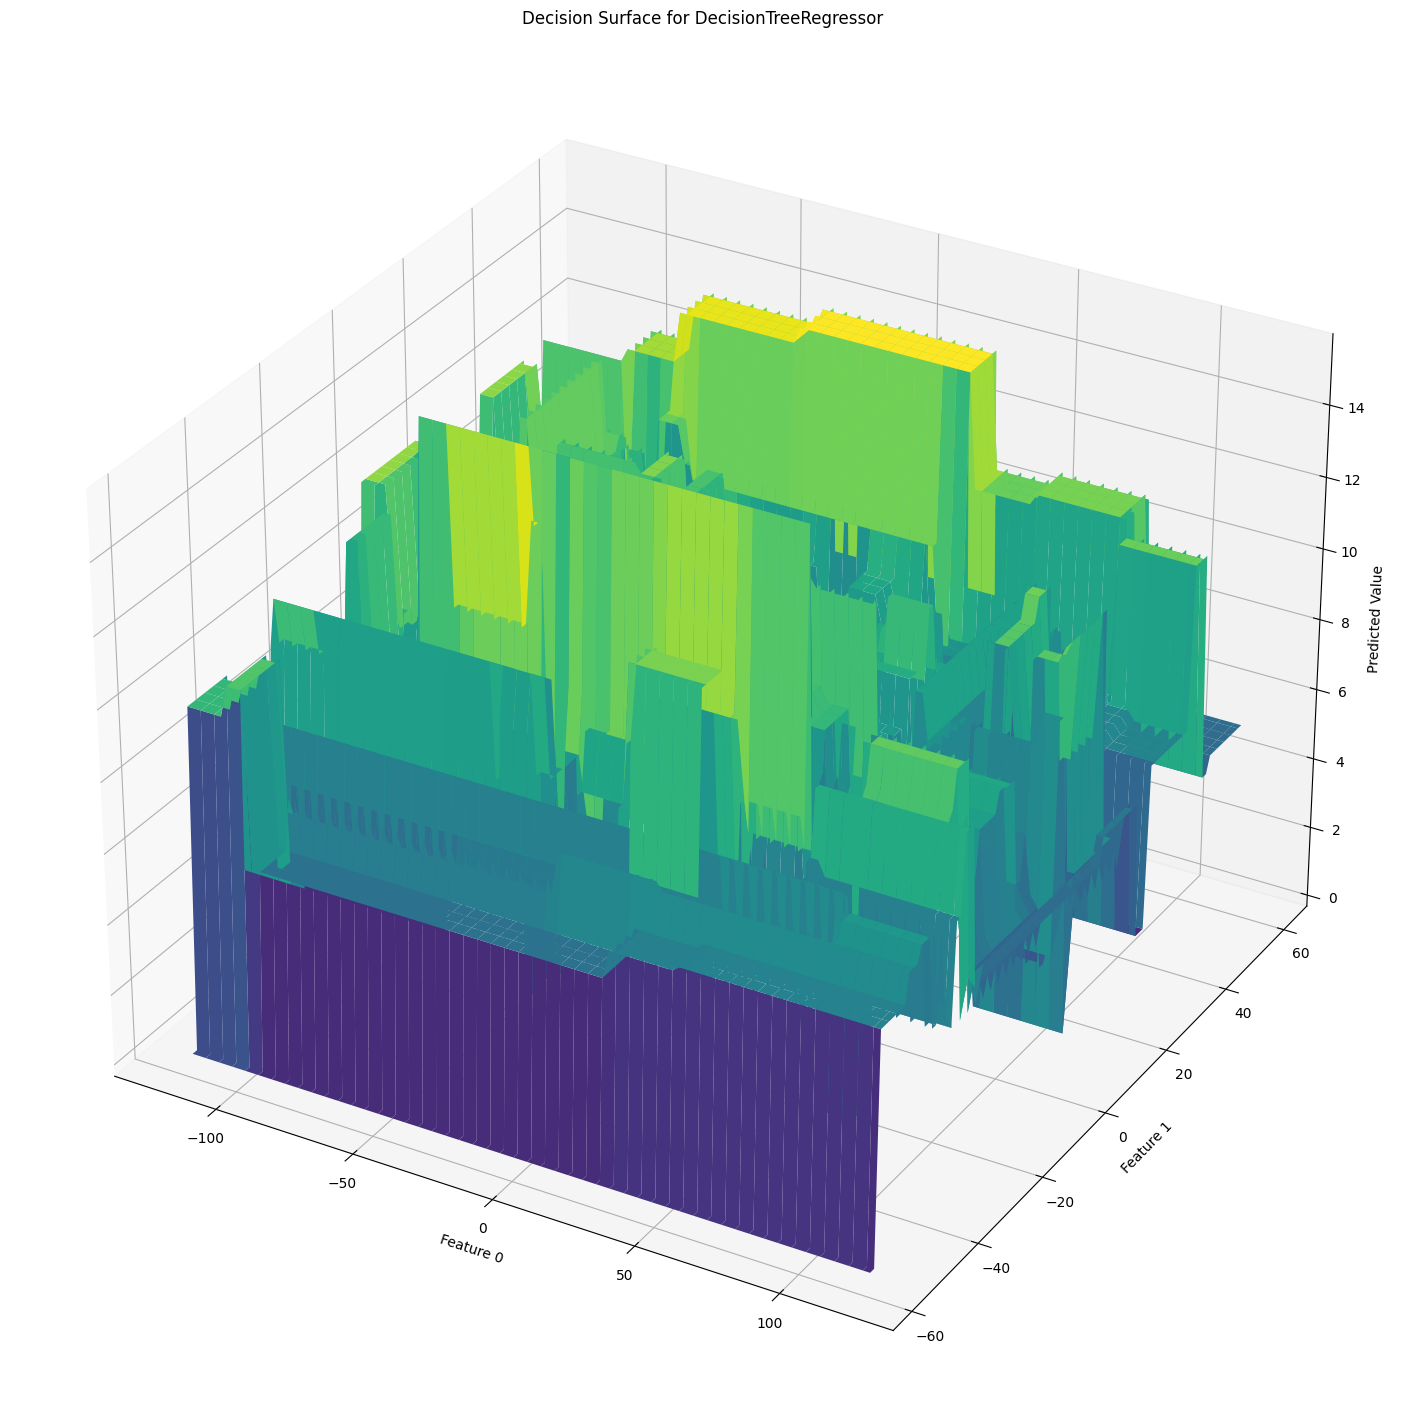

ExtraTreeRegressor: 
	K-Fold Cross-Validation (Negative Mean Squared Error): [-14.25085938 -13.96175    -16.64424688 -13.44144375 -14.59479375
 -13.47466875 -21.47796563 -15.37464063 -14.82117812 -15.70874375]
----------------------------------------------------------------------------------------------------
	Average K-Fold Cross-Validation (Negative Mean Squared Error): -15.3750290625
----------------------------------------------------------------------------------------------------


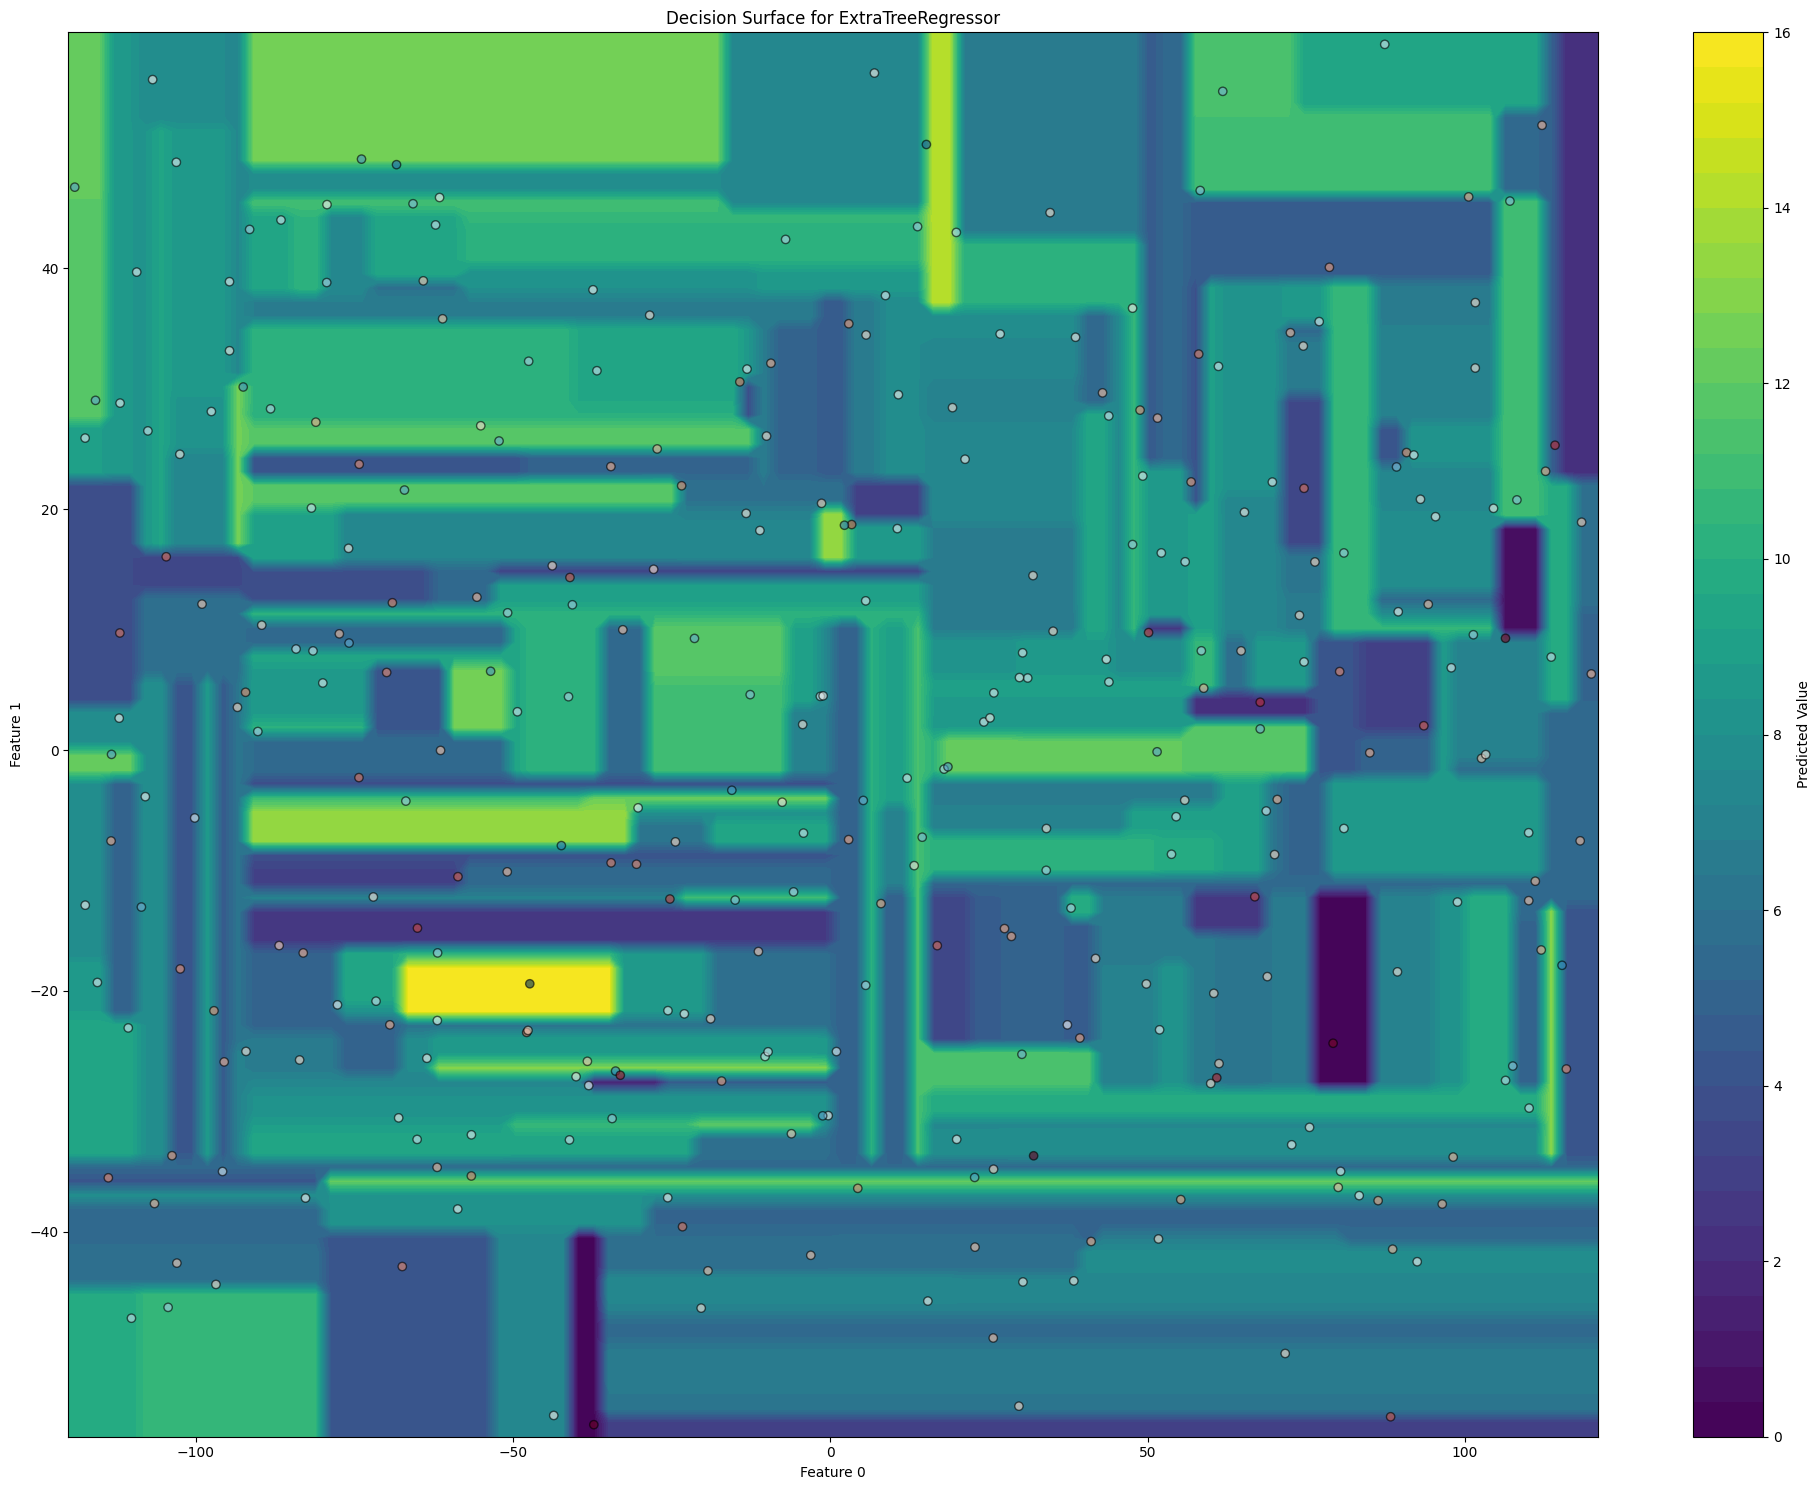

----------------------------------------------------------------------------------------------------


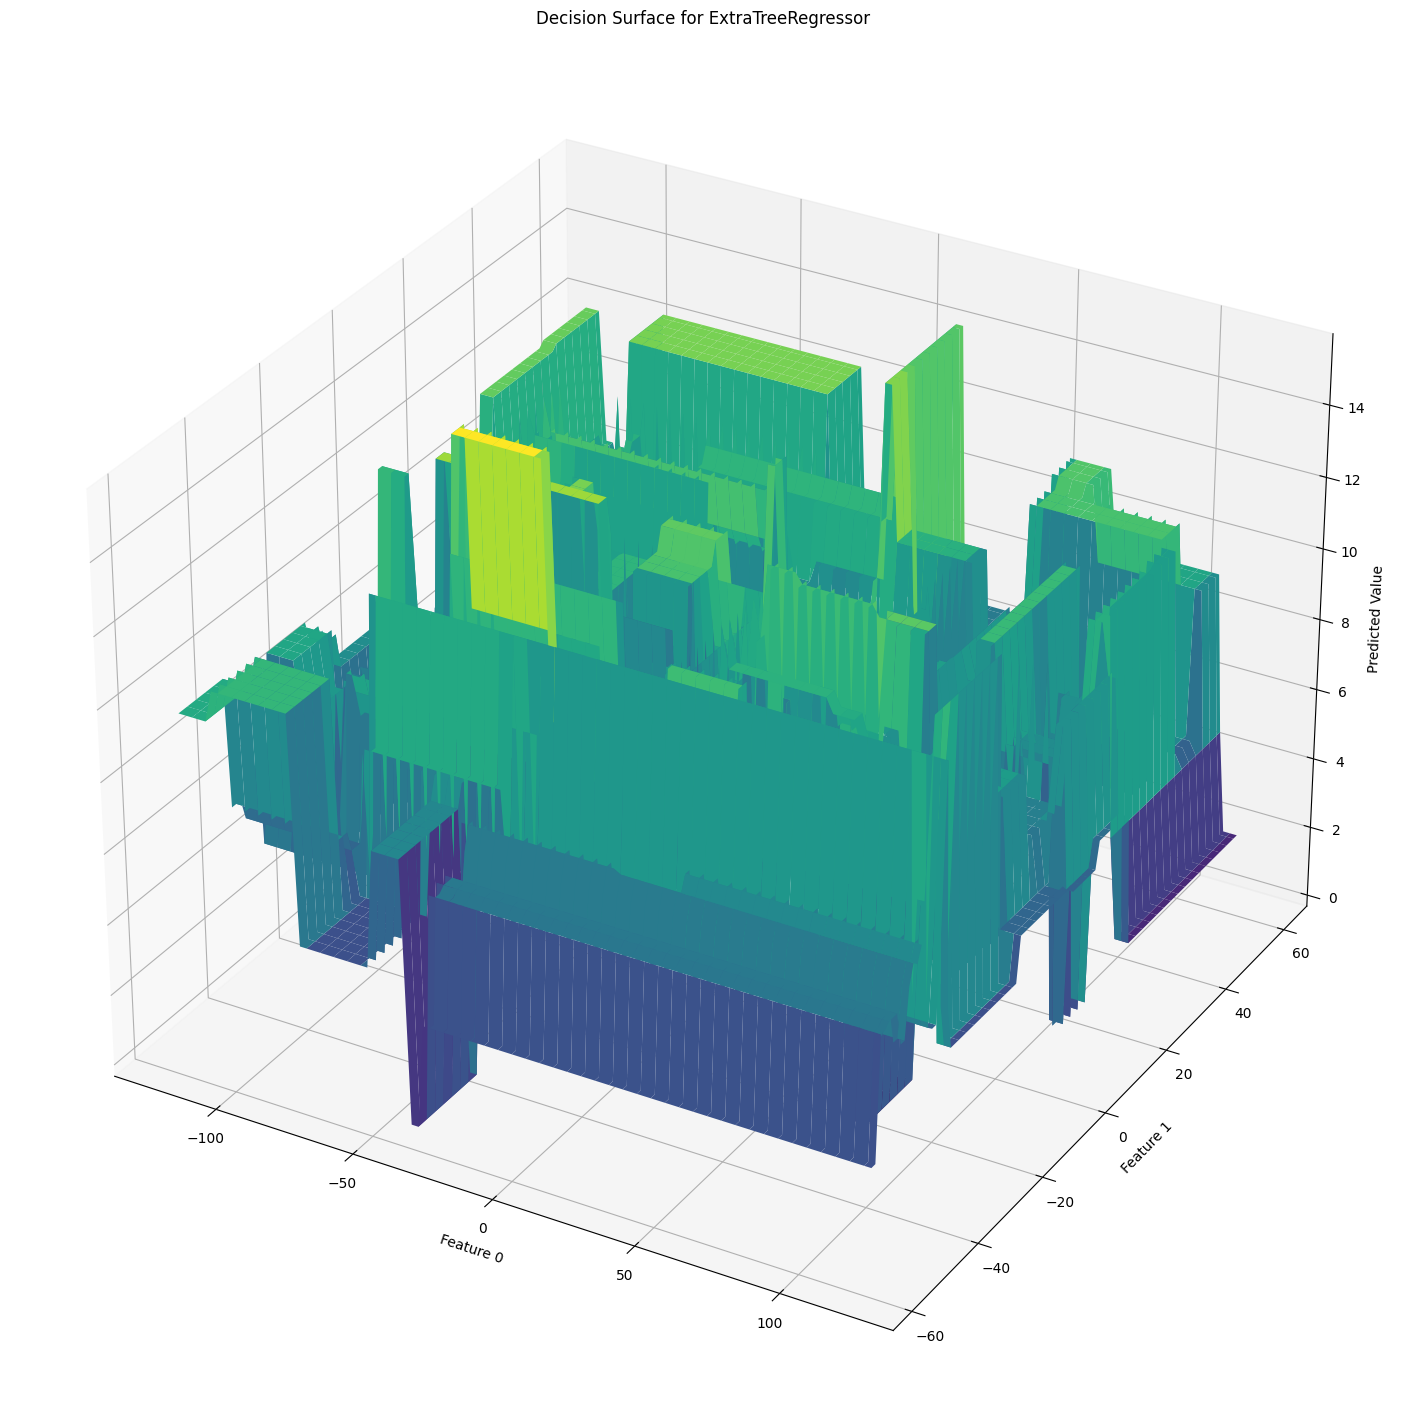

In [ ]:
ml_models = [
    ("DecisionTreeRegressor", DecisionTreeRegressor(random_state=42)),
    ("ExtraTreeRegressor", ExtraTreeRegressor(random_state=42)),
]

if isinstance(x_train, pd.DataFrame):
    x_train = x_train.values
if isinstance(y_train, pd.Series):
    y_train = y_train.values

feature_1_idx, feature_2_idx = 0, 1
feature_1_name = f"Feature {feature_1_idx}" if not isinstance(x_train, pd.DataFrame) else x_train.columns[feature_1_idx]
feature_2_name = f"Feature {feature_2_idx}" if not isinstance(x_train, pd.DataFrame) else x_train.columns[feature_2_idx]

x1_min, x1_max = x_train[:, feature_1_idx].min() - 1, x_train[:, feature_1_idx].max() + 1
x2_min, x2_max = x_train[:, feature_2_idx].min() - 1, x_train[:, feature_2_idx].max() + 1
x1, x2 = np.meshgrid(
    np.linspace(x1_min, x1_max, 100),
    np.linspace(x2_min, x2_max, 100)
)

for name, model in ml_models:
    print(f"{name}: ")
    
    model.fit(x_train, y_train)
    
    cv_scores = cross_val_score(model, x_train, y_train, cv=10, scoring='neg_mean_squared_error')
    print("\tK-Fold Cross-Validation (Negative Mean Squared Error):", cv_scores)
    print('-'*100)
    print(f'\tAverage K-Fold Cross-Validation (Negative Mean Squared Error): {cv_scores.mean()}')
    print('-'*100)

    mesh_points = np.zeros((x1.size, x_train.shape[1]))
    mesh_points[:, feature_1_idx] = x1.ravel()
    mesh_points[:, feature_2_idx] = x2.ravel()
    
    for i in range(x_train.shape[1]):
        if i not in [feature_1_idx, feature_2_idx]:
            mesh_points[:, i] = x_train[:, i].mean()

    predictions = model.predict(mesh_points)
    predictions = predictions.reshape(x1.shape)

    plt.figure(figsize=(20, 15))
    plt.contourf(x1, x2, predictions, cmap='viridis', levels=50)
    plt.colorbar(label='Predicted Value')
    plt.scatter(x_train[:, feature_1_idx], x_train[:, feature_2_idx], c=y_train, edgecolor='k', cmap='RdBu', alpha=0.6)
    plt.xlabel(feature_1_name)
    plt.ylabel(feature_2_name)
    plt.title(f'Decision Surface for {name}')
    plt.tight_layout()
    plt.show()
    print('-'*100)
    from mpl_toolkits.mplot3d import Axes3D
    fig = plt.figure(figsize=(25, 18))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_surface(x1, x2, predictions, cmap='viridis')
    ax.set_xlabel(feature_1_name)
    ax.set_ylabel(feature_2_name)
    ax.set_zlabel('Predicted Value')
    plt.title(f'Decision Surface for {name}')
    plt.show()

**Decision Surfaces**

The visualization of the decision surfaces (both 2D contours and 3D surfaces) clearly displays the characteristic step-function output of decision trees. The feature space is carved into many small, distinct, rectangular regions. Within each region, the predicted Sales value is constant (represented by a solid color block). The high complexity and fine granularity of these regions suggest that the unpruned trees are highly flexible and likely overfitting the training data, capturing noise rather than broad trends.

**Goodness of Models Fit**

**Goodness of Models Fit on First Feature**

DecisionTreeRegressor: 


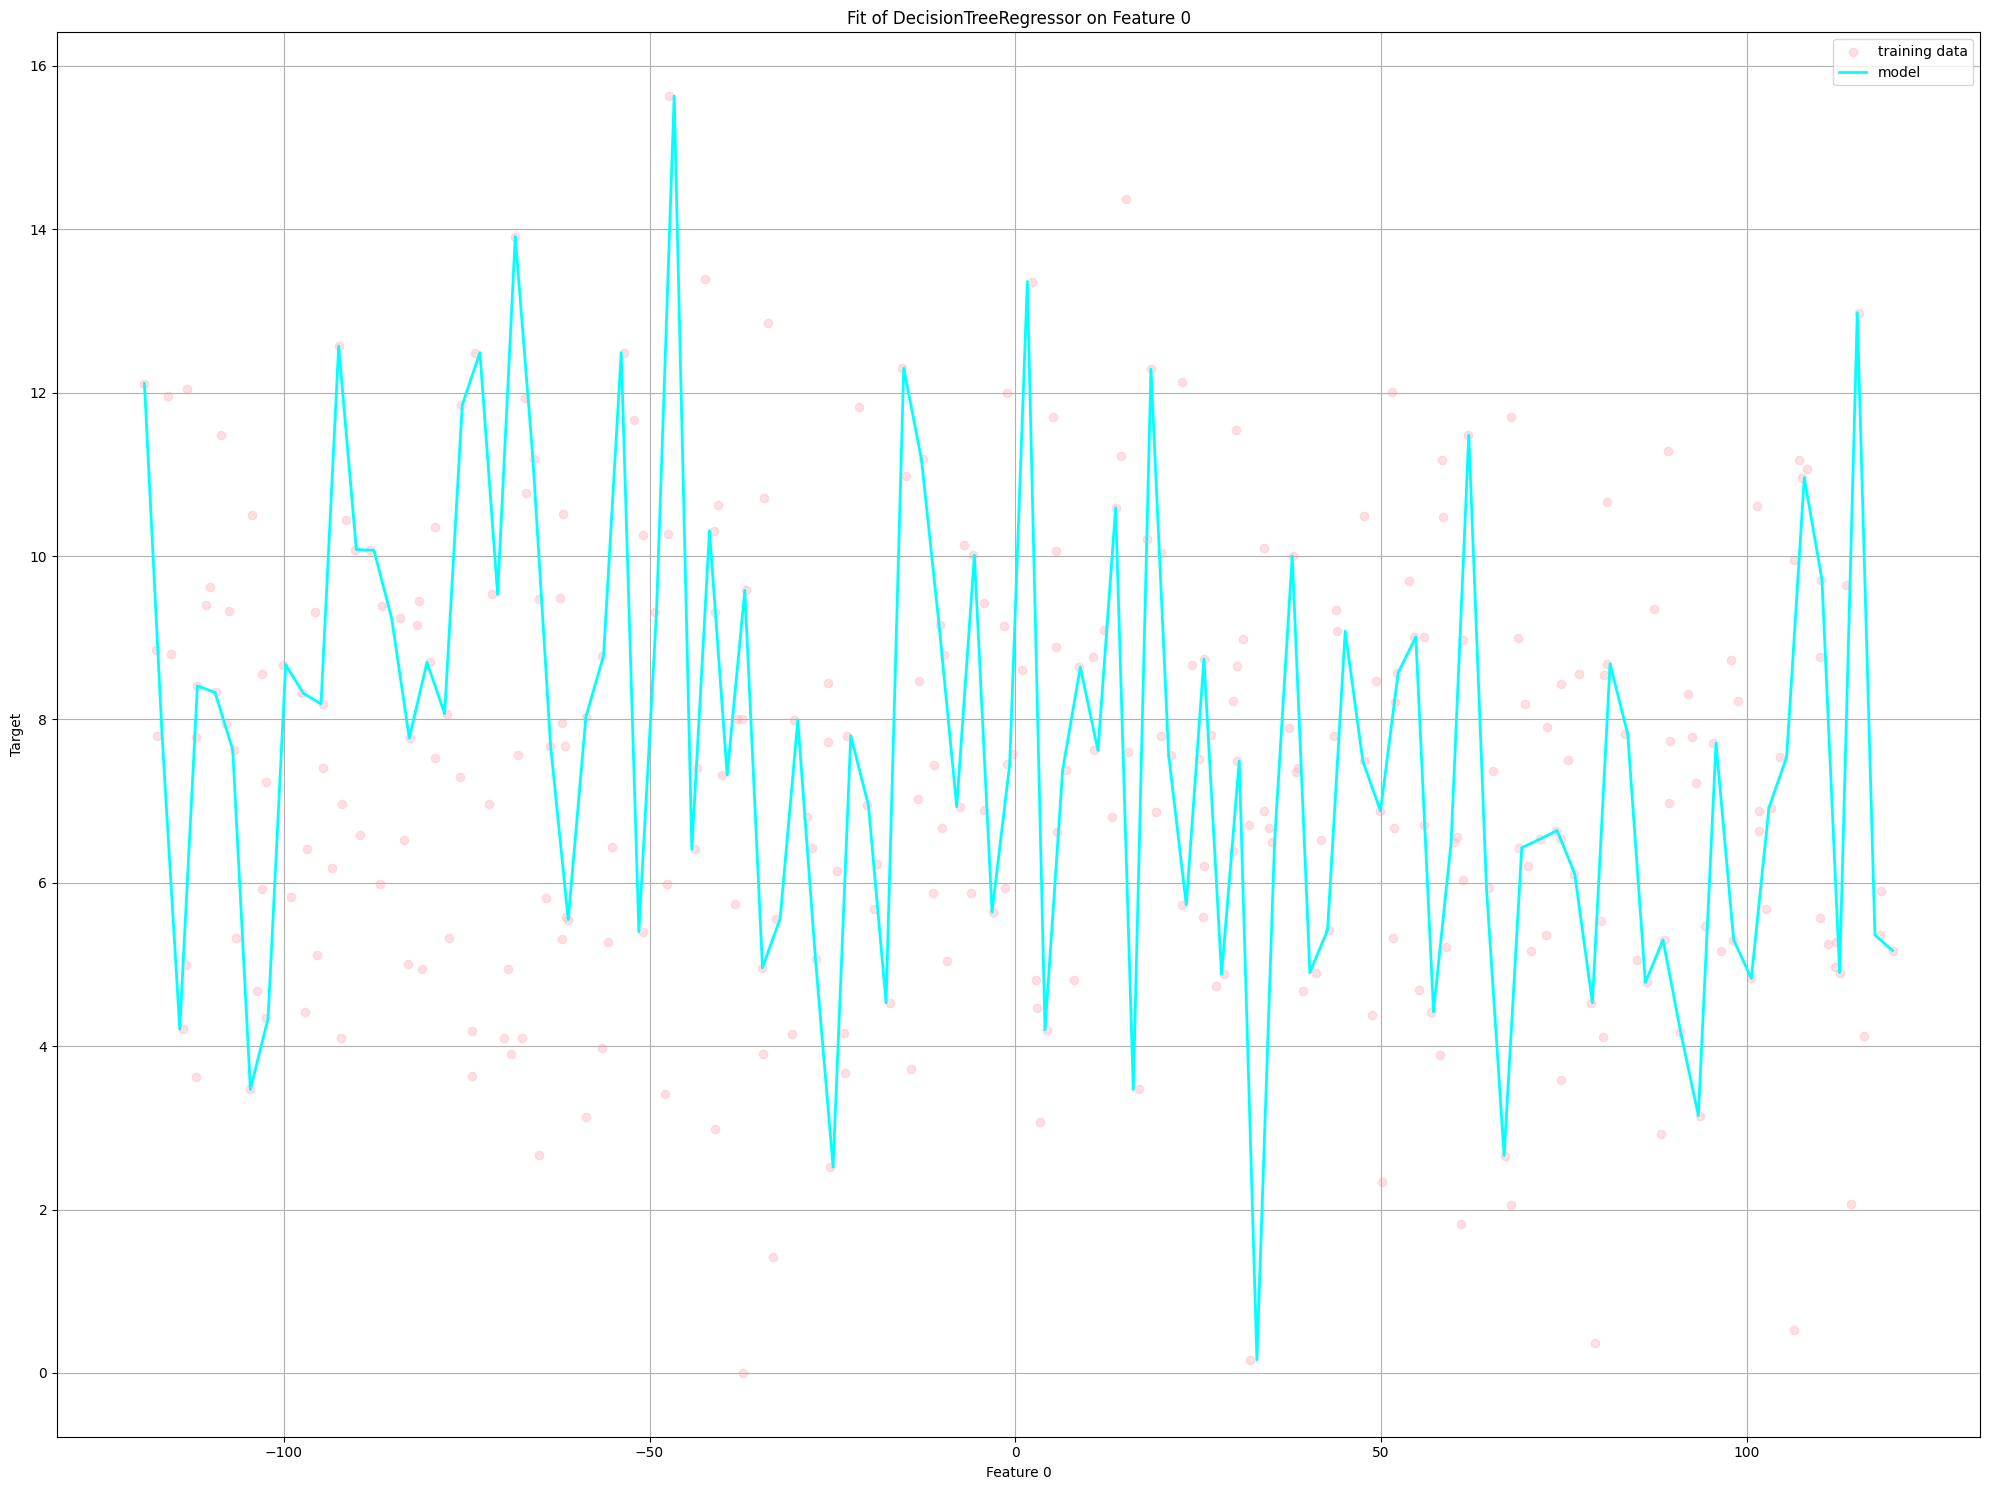

ExtraTreeRegressor: 


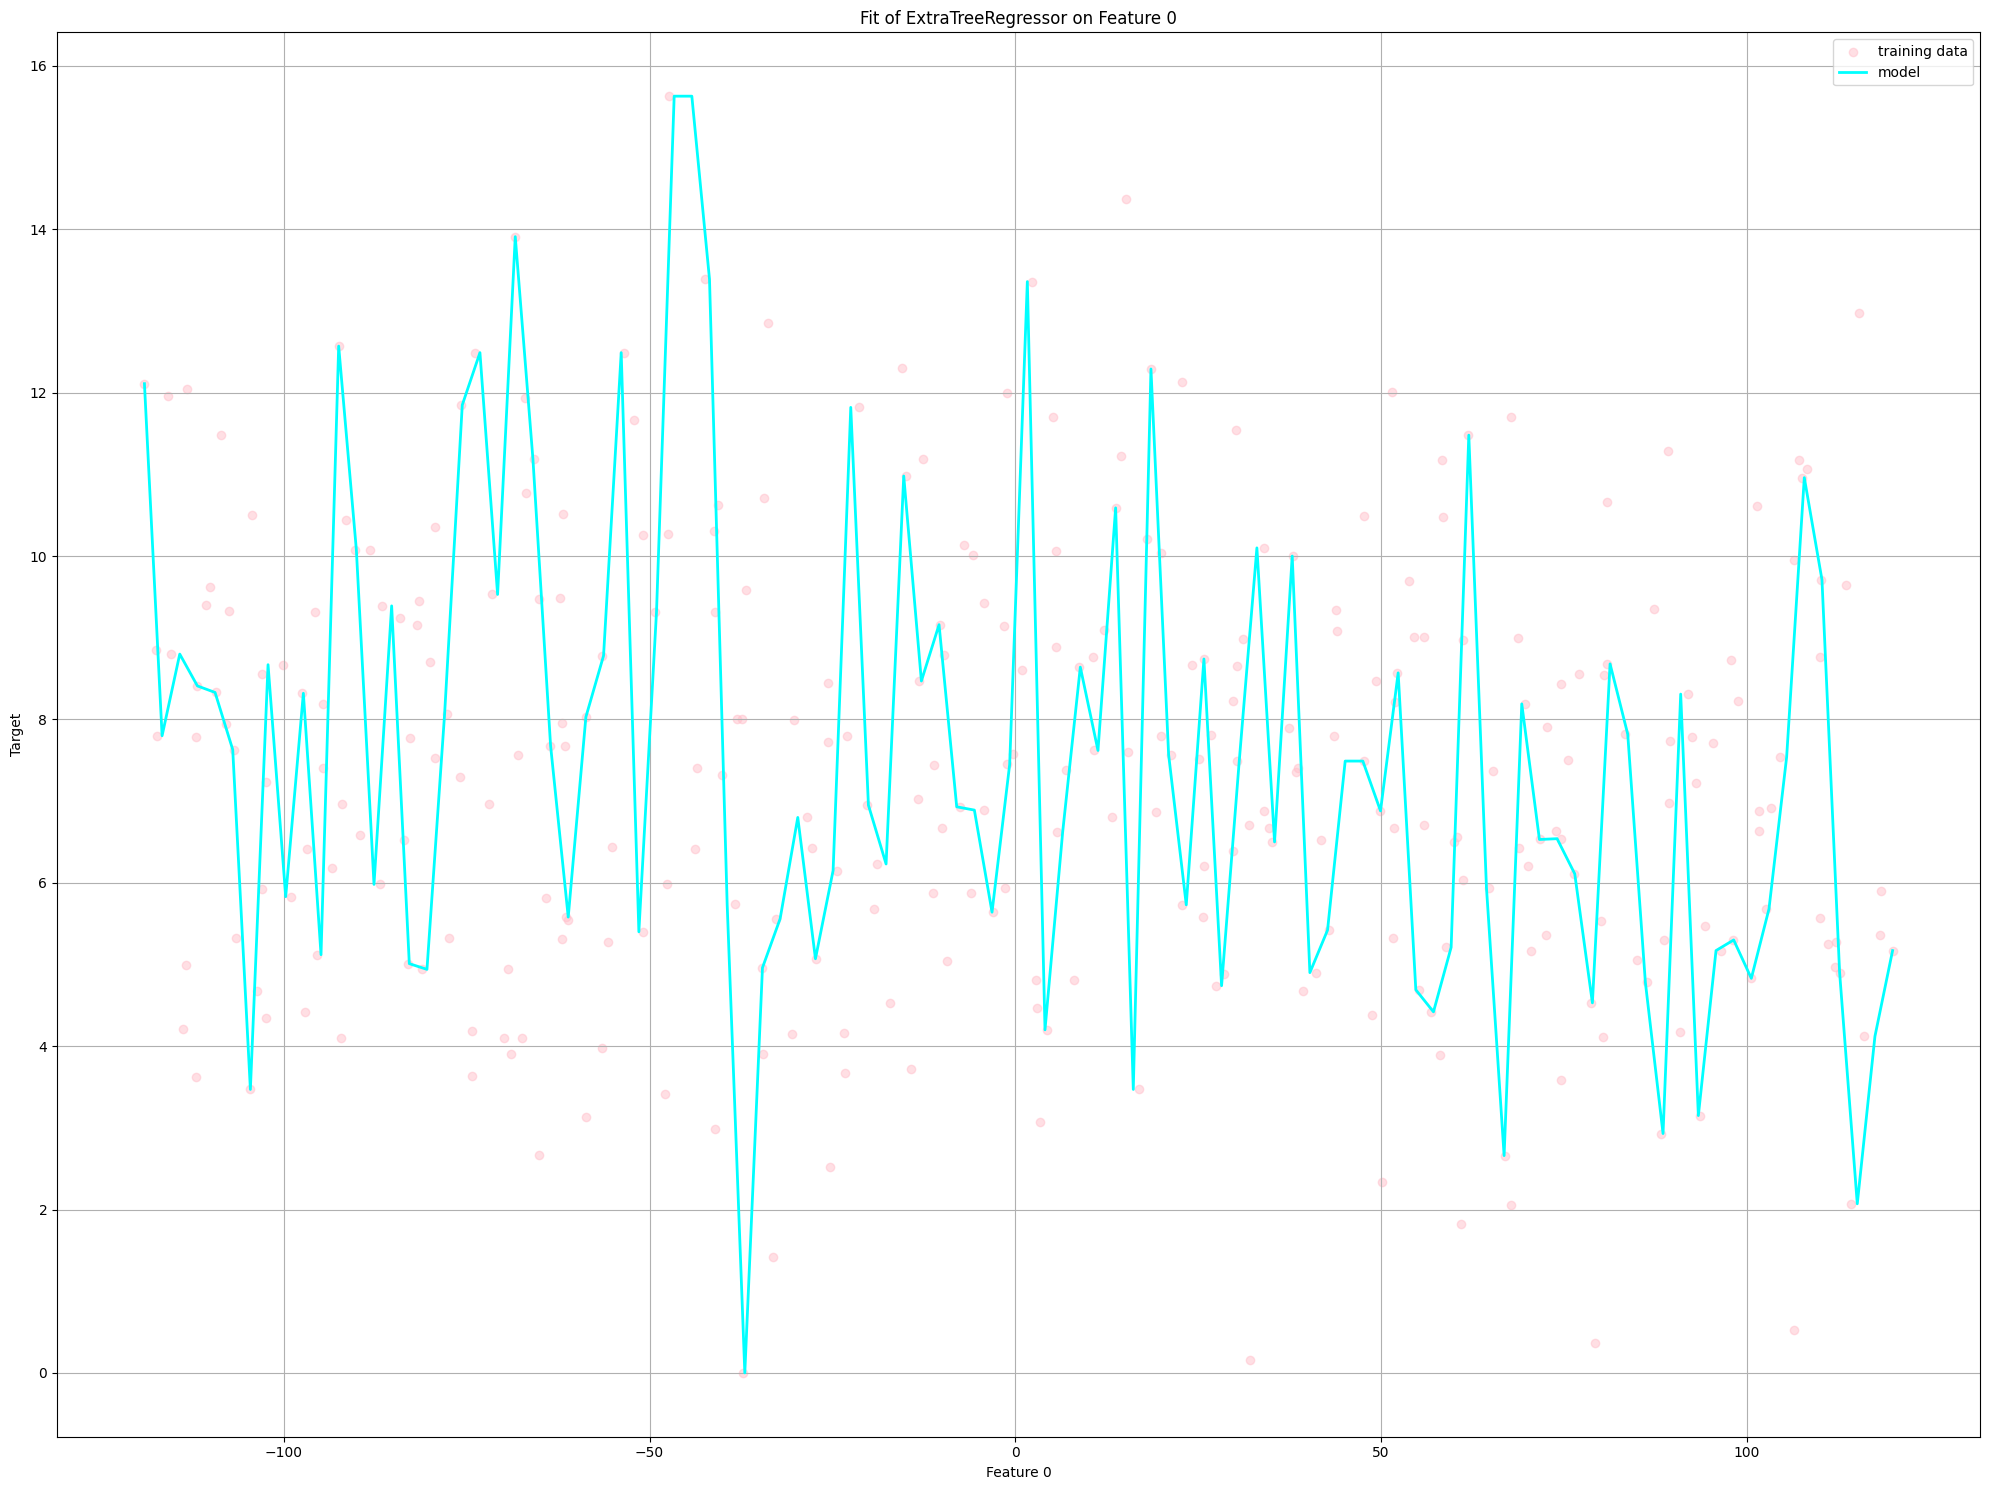

In [ ]:
ml_models = [
    ("DecisionTreeRegressor", DecisionTreeRegressor(random_state=42)),
    ("ExtraTreeRegressor", ExtraTreeRegressor(random_state=42)),
]

if isinstance(x_train, pd.DataFrame):
    x_train = x_train.values
if isinstance(y_train, pd.Series):
    y_train = y_train.values

feature_idx = 0
feature_name = f"Feature {feature_idx}" if not isinstance(x_train, pd.DataFrame) else x_train.columns[feature_idx]
x_feature = x_train[:, feature_idx]

for name, model in ml_models:
    print(f"{name}: ")
    
    model.fit(x_feature.reshape(-1, 1), y_train)

    x_range = np.linspace(x_feature.min(), x_feature.max(), 100).reshape(-1, 1)
    y_pred = model.predict(x_range)

    plt.figure(figsize=(20, 15))
    plt.scatter(x_feature, y_train, color='pink', alpha=0.5, label='training data')
    plt.plot(x_range, y_pred, color='cyan', label='model', linewidth=2)
    plt.xlabel(feature_name)
    plt.ylabel('Target')
    plt.title(f'Fit of {name} on {feature_name}')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

**Goodness of Models Fit on Second Feature**

DecisionTreeRegressor: 


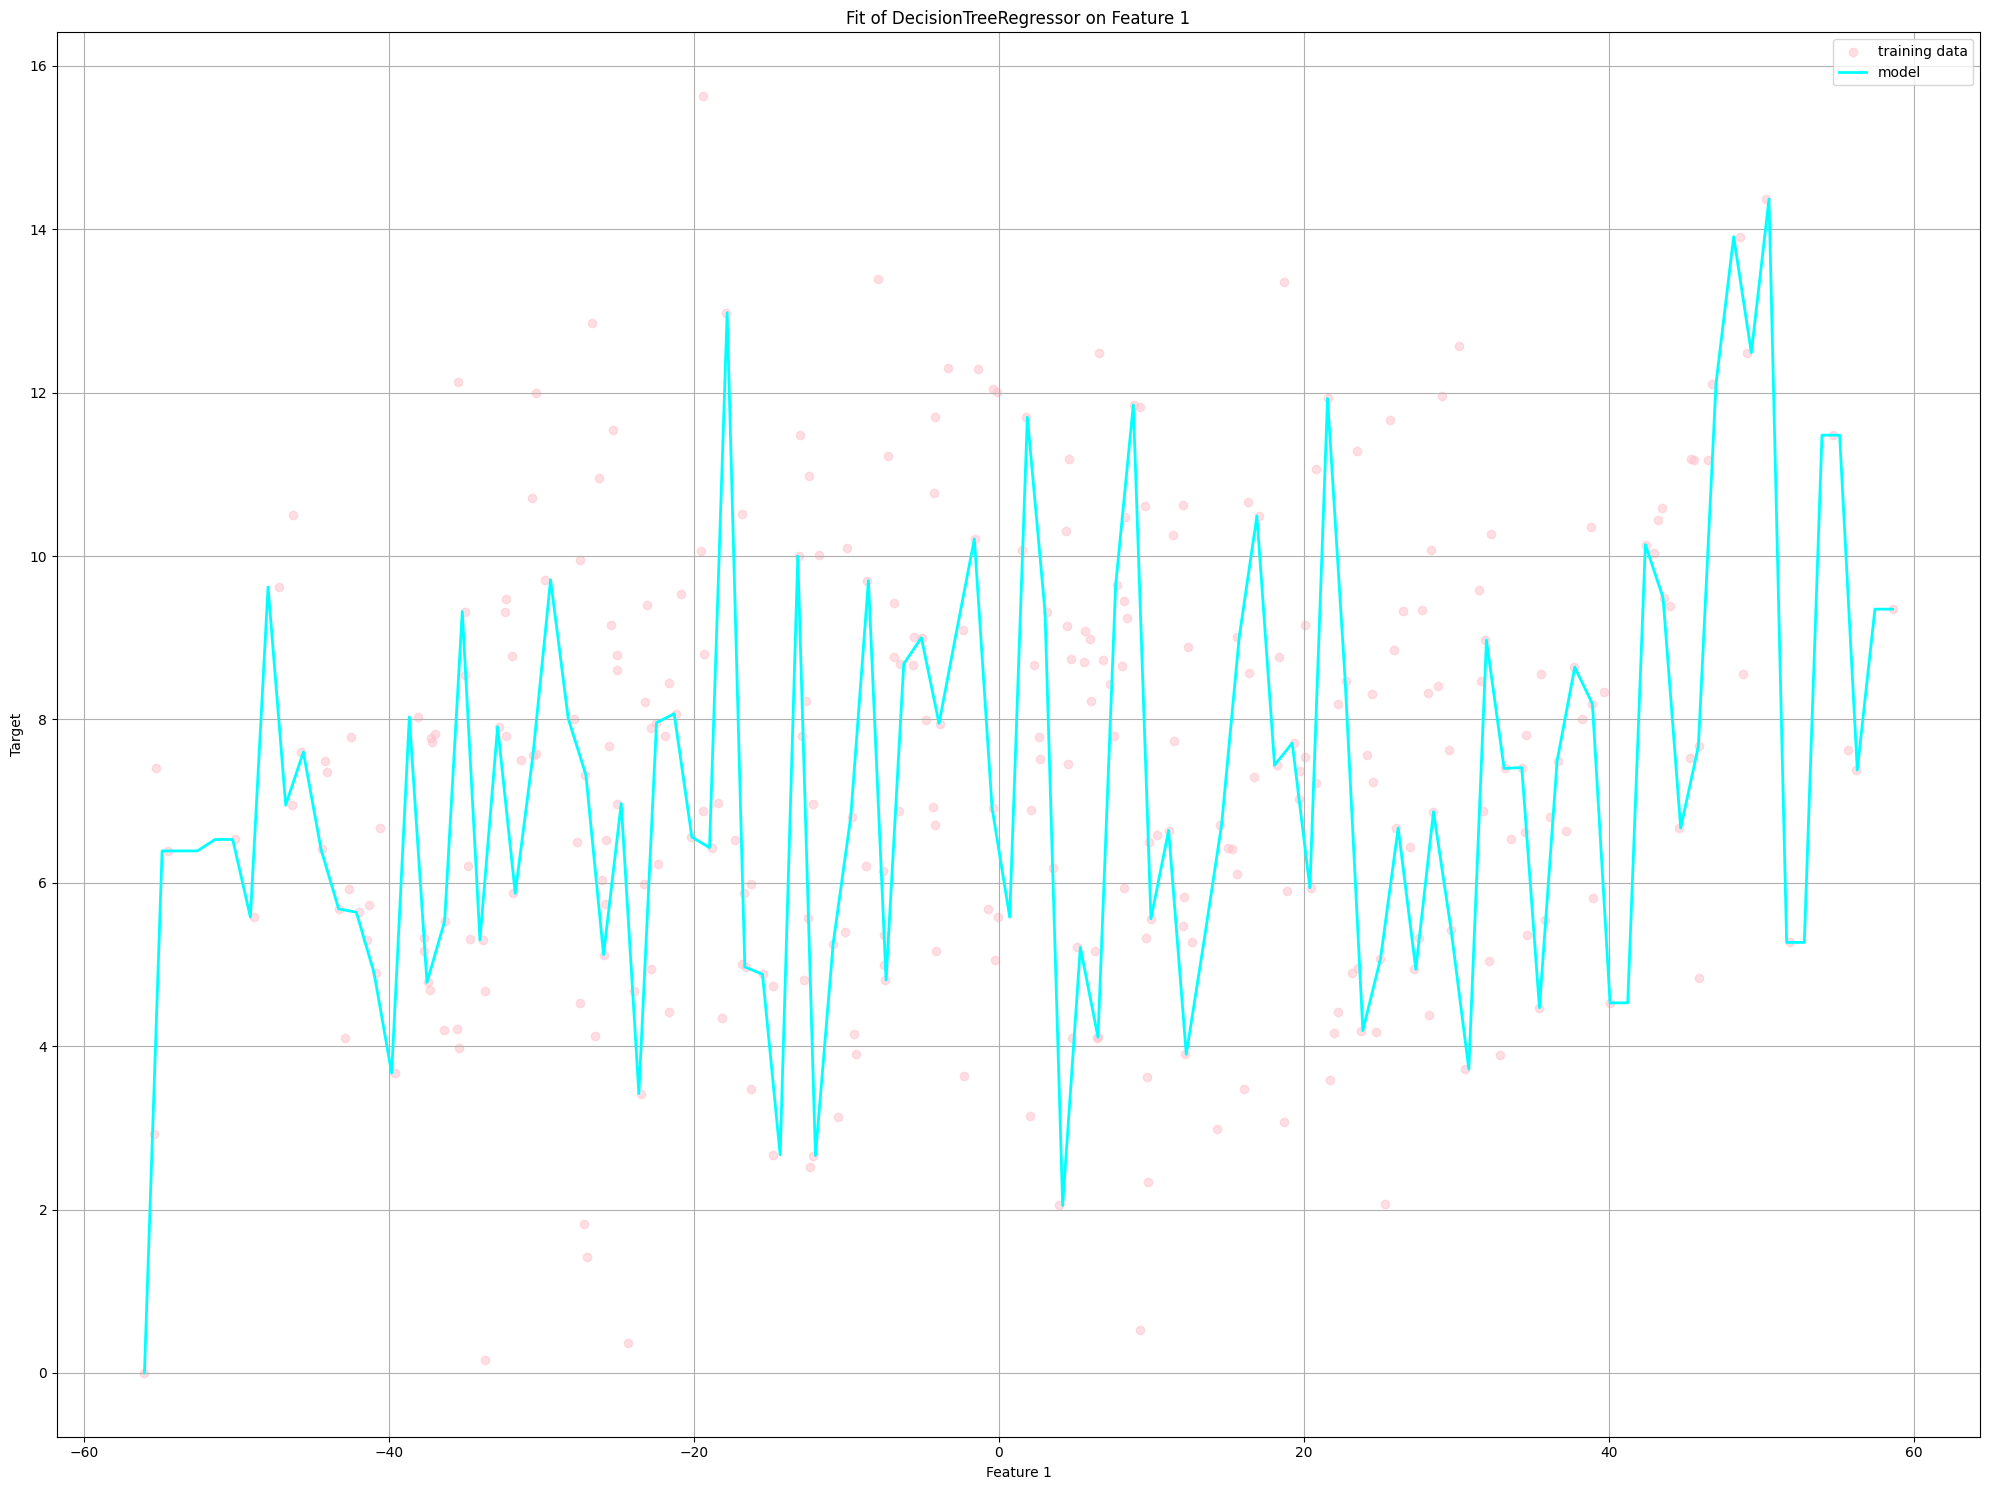

ExtraTreeRegressor: 


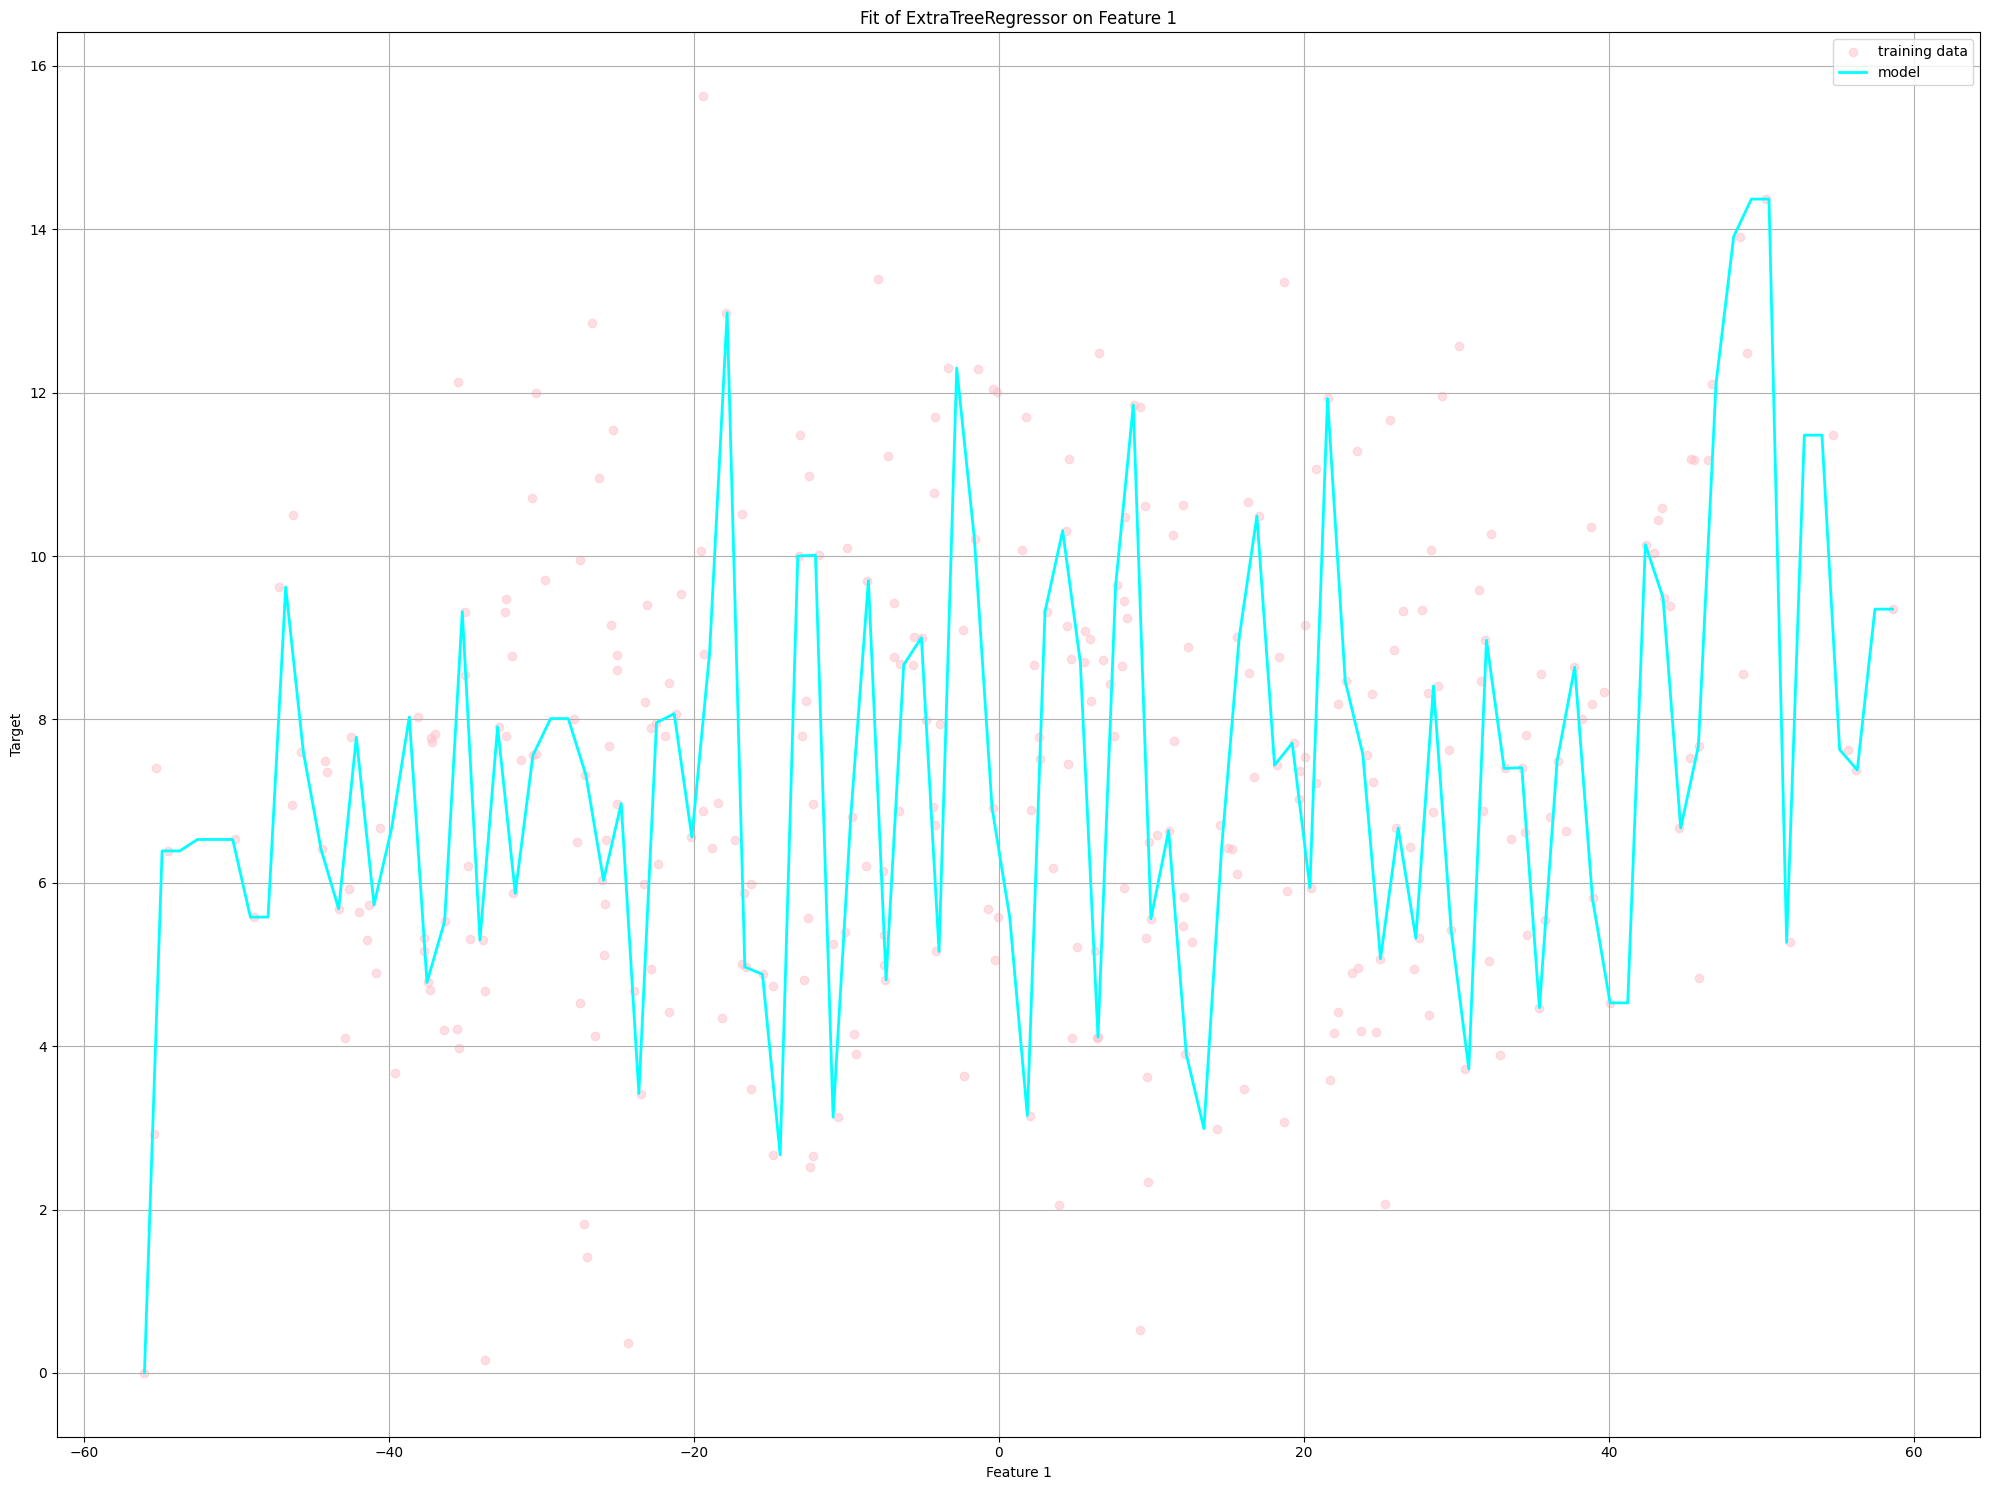

In [ ]:
ml_models = [
    ("DecisionTreeRegressor", DecisionTreeRegressor(random_state=42)),
    ("ExtraTreeRegressor", ExtraTreeRegressor(random_state=42)),
]

if isinstance(x_train, pd.DataFrame):
    x_train = x_train.values
if isinstance(y_train, pd.Series):
    y_train = y_train.values

feature_idx = 1
feature_name = f"Feature {feature_idx}" if not isinstance(x_train, pd.DataFrame) else x_train.columns[feature_idx]
x_feature = x_train[:, feature_idx]

for name, model in ml_models:
    print(f"{name}: ")
    
    model.fit(x_feature.reshape(-1, 1), y_train)

    x_range = np.linspace(x_feature.min(), x_feature.max(), 100).reshape(-1, 1)
    y_pred = model.predict(x_range)

    plt.figure(figsize=(20, 15))
    plt.scatter(x_feature, y_train, color='pink', alpha=0.5, label='training data')
    plt.plot(x_range, y_pred, color='cyan', label='model', linewidth=2)
    plt.xlabel(feature_name)
    plt.ylabel('Target')
    plt.title(f'Fit of {name} on {feature_name}')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

The 1D fit plots, showing the model's prediction against individual features, further confirm this step-wise behavior, with the predicted Sales value making sharp, discontinuous jumps at the split thresholds defined by the model.

**Post Pruning with Cost Complexity Pruning**

**Pruning and Regularization**

Tree models are susceptible to overfitting, where they learn noise in the training data rather than the underlying pattern. Cost Complexity Pruning (CCP) is a technique used to mitigate this by simplifying the tree. CCP introduces a regularization parameter, $\text{ccp}\_\text{alpha}$, which controls the trade-off between the tree's size and its fit to the training data. The technique finds a sequence of nested optimal sub-trees, where larger values of $\text{ccp}\_\text{alpha}$ result in smaller, more generalized trees.

**Post Pruning with Cost Complexity Pruning (Decision Tree)**

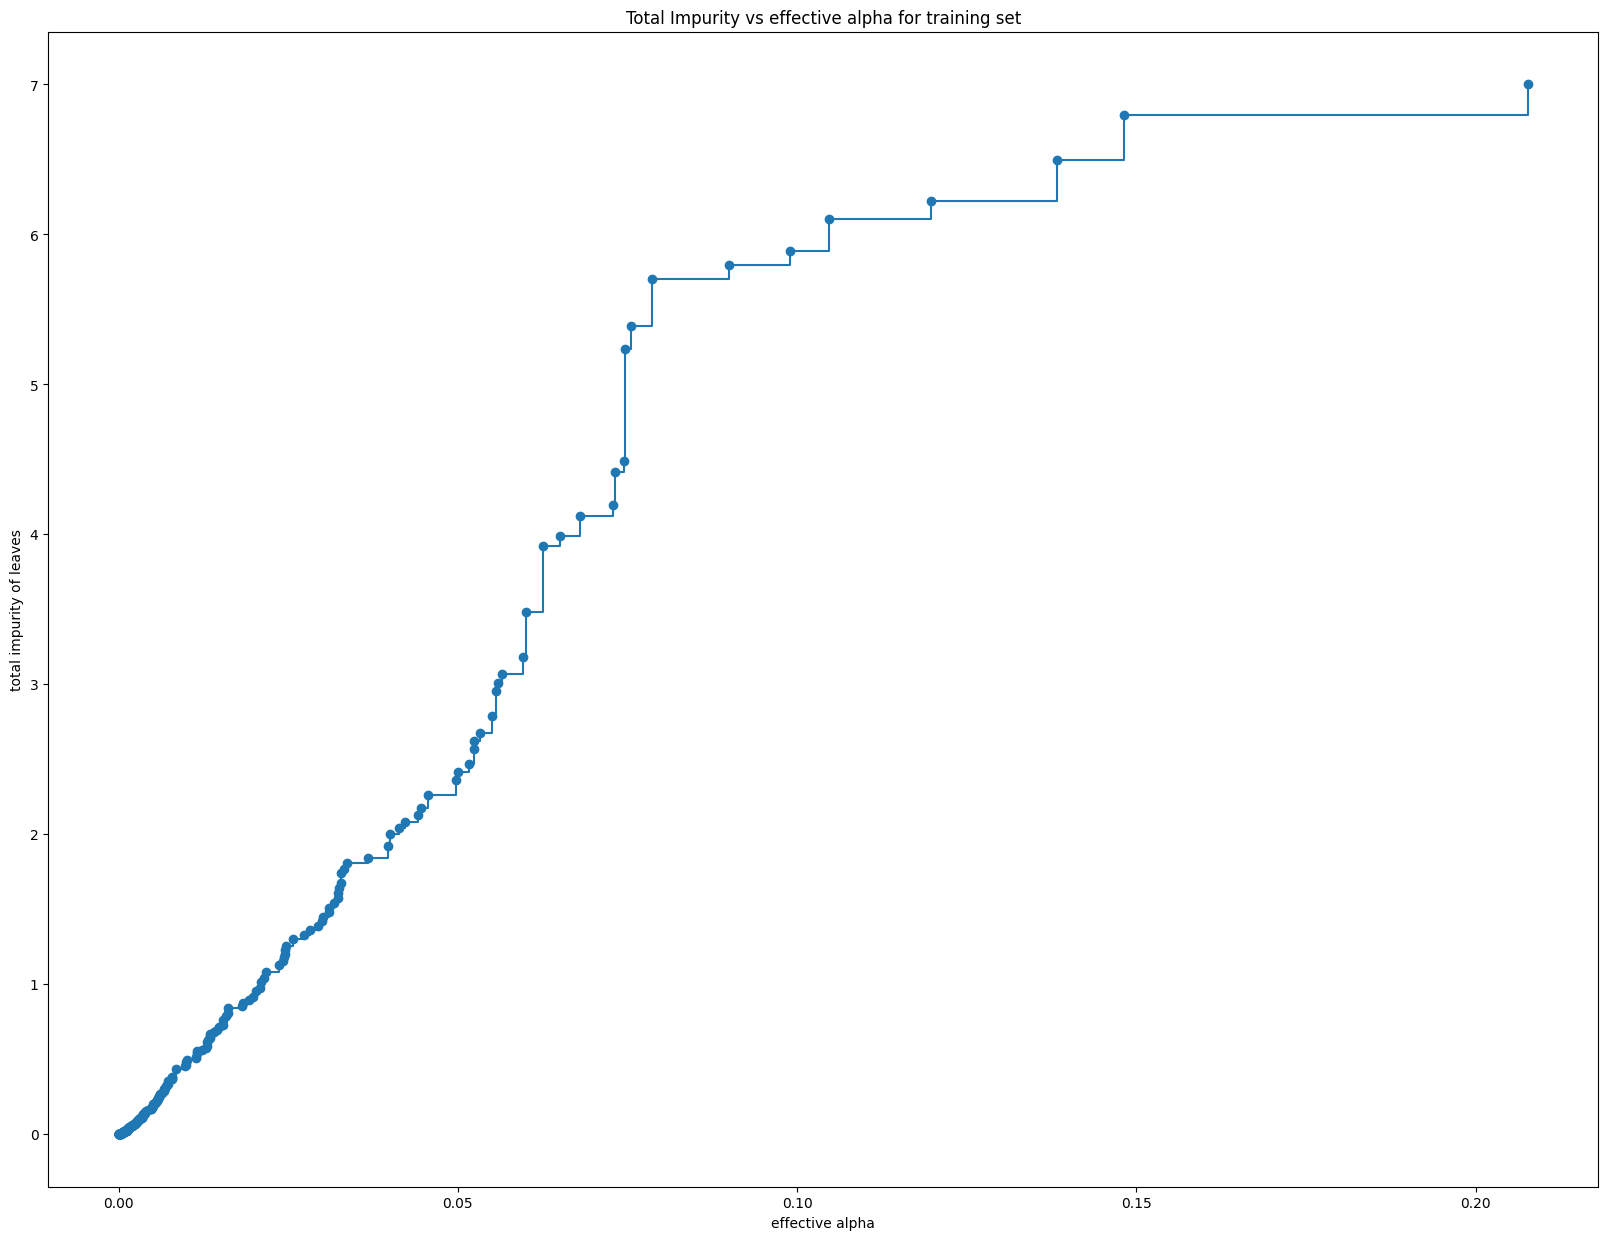

Number of nodes in the last tree is: 1 with ccp_alpha: 0.4103092190524906


In [ ]:
clf = DecisionTreeRegressor(random_state=42)
path = clf.cost_complexity_pruning_path(x_train, y_train) 
ccp_alphas, impurities = path.ccp_alphas, path.impurities
plt.figure(figsize=(20, 15))
plt.plot(ccp_alphas[:-1], impurities[:-1], marker="o", drawstyle="steps-post")
plt.xlabel("effective alpha")  
plt.ylabel("total impurity of leaves")
plt.title("Total Impurity vs effective alpha for training set")
plt.show()
clfs = []
for ccp_alpha in ccp_alphas:
    clf = DecisionTreeRegressor(random_state=42, ccp_alpha=ccp_alpha)
    clf.fit(x_train, y_train)
    clfs.append(clf)
print(
    "Number of nodes in the last tree is: {} with ccp_alpha: {}".format(
        clfs[-1].tree_.node_count, ccp_alphas[-1]
    )
)


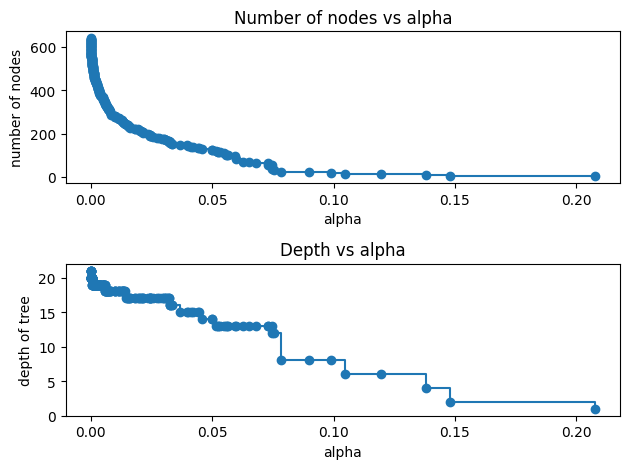

In [23]:
clfs = clfs[:-1]
ccp_alphas = ccp_alphas[:-1]

node_counts = [clf.tree_.node_count for clf in clfs]
depth = [clf.tree_.max_depth for clf in clfs]
fig, ax = plt.subplots(2, 1)
ax[0].plot(ccp_alphas, node_counts, marker="o", drawstyle="steps-post")
ax[0].set_xlabel("alpha")
ax[0].set_ylabel("number of nodes")
ax[0].set_title("Number of nodes vs alpha")
ax[1].plot(ccp_alphas, depth, marker="o", drawstyle="steps-post")
ax[1].set_xlabel("alpha")
ax[1].set_ylabel("depth of tree")
ax[1].set_title("Depth vs alpha")
fig.tight_layout()

**Post Pruning with Cost Complexity Pruning (Extra Tree)**

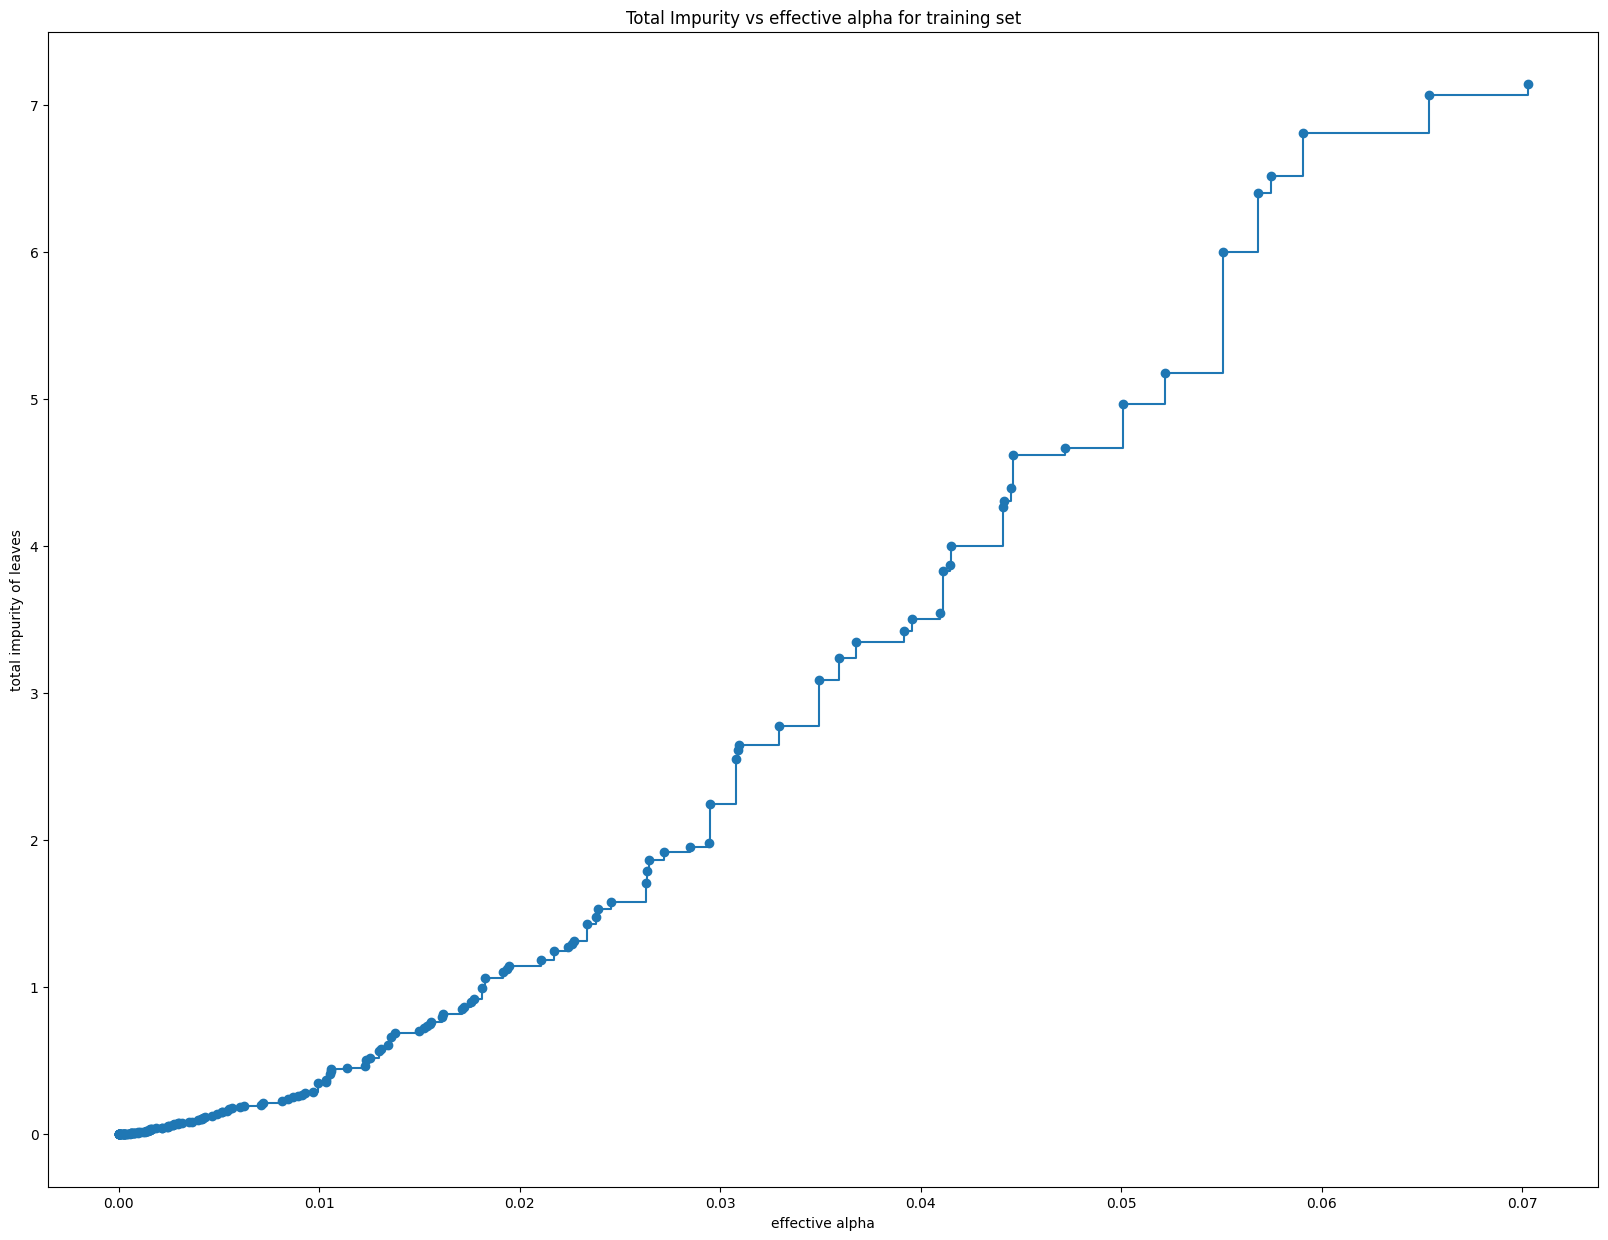

Number of nodes in the last tree is: 1 with ccp_alpha: 0.26954826015900046


In [ ]:
clf = ExtraTreeRegressor(random_state=42)
path = clf.cost_complexity_pruning_path(x_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities
plt.figure(figsize=(20, 15))
plt.plot(ccp_alphas[:-1], impurities[:-1], marker="o", drawstyle="steps-post")
plt.xlabel("effective alpha") 
plt.ylabel("total impurity of leaves")
plt.title("Total Impurity vs effective alpha for training set")
plt.show()
clfs = []
for ccp_alpha in ccp_alphas:
    clf = ExtraTreeRegressor(random_state=42, ccp_alpha=ccp_alpha)
    clf.fit(x_train, y_train)
    clfs.append(clf)
print(
    "Number of nodes in the last tree is: {} with ccp_alpha: {}".format(
        clfs[-1].tree_.node_count, ccp_alphas[-1]
    )
)

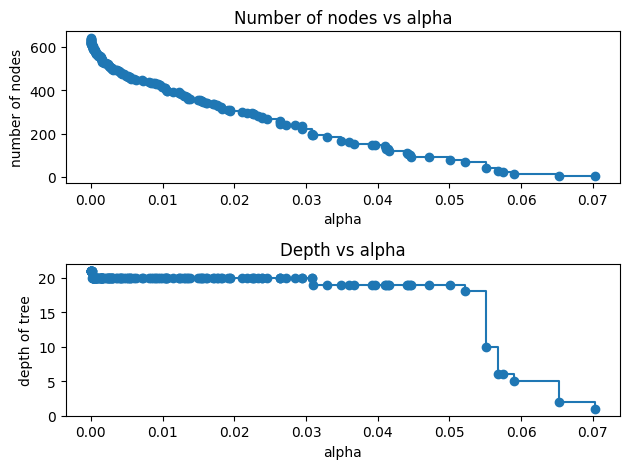

In [25]:
clfs = clfs[:-1]
ccp_alphas = ccp_alphas[:-1]

node_counts = [clf.tree_.node_count for clf in clfs]
depth = [clf.tree_.max_depth for clf in clfs]
fig, ax = plt.subplots(2, 1)
ax[0].plot(ccp_alphas, node_counts, marker="o", drawstyle="steps-post")
ax[0].set_xlabel("alpha")
ax[0].set_ylabel("number of nodes")
ax[0].set_title("Number of nodes vs alpha")
ax[1].plot(ccp_alphas, depth, marker="o", drawstyle="steps-post")
ax[1].set_xlabel("alpha")
ax[1].set_ylabel("depth of tree")
ax[1].set_title("Depth vs alpha")
fig.tight_layout()

**Cost Complexity Pruning Analysis**

The pruning path analysis provides crucial insight into structural control:
- Total Impurity vs. Effective Alpha: The plot shows a clear and steady increase in the total impurity of leaves as the effective $\text{ccp}\_\text{alpha}$ increases. This confirms the fundamental trade-off of pruning: a simpler tree (higher $\text{ccp}\_\text{alpha}$) necessarily results in less pure (higher impurity) terminal nodes because fewer splits are permitted to refine the predictions.
- Number of Nodes and Depth vs. Alpha: Both the number of nodes and the maximum depth of the trees show an inverse relationship with $\text{ccp}\_\text{alpha}$. As the penalty for complexity increases, the trees rapidly become simpler, exhibiting fewer internal nodes and shallower depth. This diagnostic plot confirms that $\text{ccp}\_\text{alpha}$ successfully controls the model's complexity, providing a robust means for selecting an optimal, generalized tree structure by balancing impurity and size.

**Hyperparameters Tuning**

**Decision Tree Regressor Hyperparameters**

The Decision Tree Regressor (DTR) is a fundamental non-linear model that partitions the feature space into distinct regions. The prediction for a new data point is the average of the target values of all training points that fall into its corresponding region. This method yields a step-function approximation of the underlying relationship. 

**Core Concepts**

- Greedy Splitting: The tree is constructed using a greedy algorithm that chooses the best local split at each node.
- Impurity/Criterion: For regression, the objective is to minimize the output variance (impurity) within the resulting child nodes. The most common criteria include `squared_error` (equivalent to minimizing MSE), `friedman_mse` (an adjusted MSE criterion for better performance), and `absolute_error` (MAE, more robust to outliers).
- Overfitting Tendency: A single unconstrained DTR tends to grow fully and perfectly memorize the training data, resulting in extremely low bias but critically high variance and poor generalization.

**Important Hyperparameters for DTR (Controlling Complexity)**

- `max_depth`: Defines the maximum depth of the tree. This is the primary parameter for controlling complexity and is essential for preventing overfitting.
- `min_samples_split`: The minimum number of samples an internal node must contain before it can be considered for splitting. Increasing this value prevents the creation of overly specific nodes.
- `min_samples_leaf`: The minimum number of samples required to be at a leaf node. This ensures that every prediction is based on a meaningful number of data points.
- `max_features`: The number of features to consider when searching for the best split. Restricting this introduces randomness and is often used to improve stability.
- `ccp_alpha` (Cost-Complexity Pruning): The complexity parameter used for pruning. Higher values result in more aggressive pruning, effectively penalizing complex structures and yielding a simpler, more generalized tree.

**Extremely Randomized Trees Regressor (Extra Trees) Hyperparameters**

The Extra Trees Regressor is an ensemble method that builds multiple de-correlated Decision Trees and averages their predictions to reduce overall model variance. It shares the structure of a Random Forest but introduces more extreme randomization.

**Core Differences and Concepts**

- No Bootstrapping (Default): Unlike Random Forests, which sample data with replacement (bootstrapping), Extra Trees usually trains each individual tree on the entire original training dataset. This avoids the introduction of bias from data subsetting.
- Random Split Thresholds: This is the defining feature. At each node, instead of calculating the optimal threshold for the best split (which minimizes variance), the algorithm selects a random subset of features and, for each selected feature, it chooses a random threshold. It then picks the best split among these random candidates.
- Variance Reduction: The strong element of randomization in split selection significantly decorrelates the individual trees. By averaging the predictions of these highly diverse trees, the ensemble achieves a substantial reduction in variance, leading to better generalization.
- Computational Efficiency: Skipping the exhaustive search for the optimal split threshold makes the training process for Extra Trees computationally faster than standard Decision Trees and Random Forests.

**Important Hyperparameters for Extra Trees (Ensemble and Randomization)**

- `n_estimators`: The number of trees in the forest. A higher number typically improves performance by reducing variance but increases training time.
- `max_depth, min_samples_split, min_samples_leaf`: These parameters serve the same complexity control function as in DTR, though the individual trees are often grown deeper due to the variance-reducing ensemble nature.
- `max_features`: The number of features to consider when looking for the best random split. This is crucial for injecting diversity into the ensemble.
- `bootstrap`: If set to True, trees are built on bootstrapped samples. The default is False to preserve the core concept of Extra Trees.

**Hyperparameters Tuning Implementation**

The process of Hyperparameter Tuning is critical for maximizing a machine learning model's performance by finding the optimal combination of settings that are not learned from the data (unlike parameters like split points). This step utilizes Optuna, a hyperparameter optimization framework, to tune both the Decision Tree Regressor (DTR) and the Extra Tree Regressor (ETR).

Optuna employs a Bayesian Optimization strategy, specifically Tree-structured Parzen Estimator (TPE), to intelligently search the hyperparameter space. Unlike exhaustive methods (like Grid Search) or random methods, TPE models the probability of a hyperparameter set yielding a good result based on past trials. This allows the search to quickly converge on promising regions, making the process highly efficient.

The performance metric used for optimization is the Mean Squared Error (MSE), derived from the cross-validated Negative Mean Squared Error (NMSE). The objective function is configured to minimize the MSE, ensuring that the selected hyperparameters produce the smallest average squared prediction error across the 10-fold cross-validation. K-Fold Cross-Validation (with $K=10$ and shuffled data) remains the backbone of the evaluation, providing an unbiased estimate of the model's true generalization capacity by testing it on multiple held-out data segments.The key hyperparameters tuned for both tree models include:
- `max_depth`: Limits the depth of the tree, directly controlling complexity and preventing overfitting.
- `min_samples_split / min_samples_leaf`: Define the minimum number of data points required to split an internal node or to be in a leaf node, acting as regularization against over-segmentation.
- `ccp_alpha`: The effective alpha for Cost Complexity Pruning, which penalizes complexity and simplifies the tree structure.
- `max_features`: The number of features considered when looking for the best split, introducing randomness (especially important for Extra Trees).
- `criterion`: The function used to measure the quality of a split (squared_error, friedman_mse, absolute_error, or poisson).

In [ ]:
def objective(trial, model_name, x_train, y_train):
    if model_name == "DecisionTreeRegressor":
        params = {
            'criterion': trial.suggest_categorical('criterion', ['squared_error', 'friedman_mse', 'absolute_error', 'poisson']),
            'max_depth': trial.suggest_int('max_depth', 3, 20),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 5),
            'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
            'min_impurity_decrease': trial.suggest_float('min_impurity_decrease', 0.0, 0.2),
            'ccp_alpha': trial.suggest_float('ccp_alpha', 0.0, 0.1)
        }
        model = DecisionTreeRegressor(random_state=42, **params)
    elif model_name == "ExtraTreeRegressor":
        params = {
            'criterion': trial.suggest_categorical('criterion', ['squared_error', 'friedman_mse', 'absolute_error', 'poisson']),
            'max_depth': trial.suggest_int('max_depth', 3, 20),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 5),
            'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
            'min_impurity_decrease': trial.suggest_float('min_impurity_decrease', 0.0, 0.2),
            'ccp_alpha': trial.suggest_float('ccp_alpha', 0.0, 0.1)
        }
        model = ExtraTreeRegressor(random_state=42, **params)

    cv = KFold(n_splits=10, shuffle=True, random_state=42)
    scores = cross_val_score(model, x_train, y_train, cv=cv, scoring='neg_mean_squared_error', n_jobs=-1)
    mean_score = -scores.mean()

    return mean_score

ml_models = [
    ("DecisionTreeRegressor", DecisionTreeRegressor(random_state=42)),
    ("ExtraTreeRegressor", ExtraTreeRegressor(random_state=42))
]

overall_best_model = None
overall_best_model_name = None
overall_best_params = None
overall_best_score = float('inf')

for name, base_model in ml_models:
    print(f"\nOptimizing {name} with Optuna:")
    
    study = optuna.create_study(direction='minimize')
    study.optimize(lambda trial: objective(trial, name, x_train, y_train), n_trials=50)
    
    print(f"\tBest Parameters: {study.best_params}")
    print(f"\tBest Cross-Validation Score (Negative MSE): {study.best_value:.4f}")
    
    best_model = base_model.__class__(random_state=42, **study.best_params)
    best_model.fit(x_train, y_train)
    
    cv = KFold(n_splits=10, shuffle=True, random_state=42)
    cv_scores = cross_val_score(best_model, x_train, y_train, cv=cv, scoring='neg_mean_squared_error')
    avg_cv_score = -cv_scores.mean()
    print(f"\tCross-Validation Scores with Best Model: {-cv_scores}")
    print(f"\tAverage Cross-Validation Score (MSE): {avg_cv_score:.4f}")
    print("-" * 100)

    if avg_cv_score < overall_best_score:
        overall_best_score = avg_cv_score
        overall_best_model = best_model
        overall_best_model_name = name
        overall_best_params = study.best_params

print(f"Overall Best Model: {overall_best_model_name}")
print(f"Best Hyperparameters: {overall_best_params}")
print(f"Best Cross-Validation Score (MSE): {overall_best_score:.4f}")
print("=" * 100)

[I 2025-11-24 22:34:27,671] A new study created in memory with name: no-name-a4af2182-c1ba-434e-b6ba-64691c13974c



Optimizing DecisionTreeRegressor with Optuna:


[I 2025-11-24 22:34:29,247] Trial 0 finished with value: 7.4374959375000005 and parameters: {'criterion': 'absolute_error', 'max_depth': 3, 'min_samples_split': 6, 'min_samples_leaf': 5, 'max_features': None, 'min_impurity_decrease': 0.06803233535359442, 'ccp_alpha': 0.0949621431124186}. Best is trial 0 with value: 7.4374959375000005.
[I 2025-11-24 22:34:29,276] Trial 1 finished with value: 7.440245604021991 and parameters: {'criterion': 'poisson', 'max_depth': 3, 'min_samples_split': 4, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'min_impurity_decrease': 0.08324462428633095, 'ccp_alpha': 0.02894103284267977}. Best is trial 0 with value: 7.4374959375000005.
[I 2025-11-24 22:34:29,302] Trial 2 finished with value: 7.4374959375000005 and parameters: {'criterion': 'absolute_error', 'max_depth': 14, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': None, 'min_impurity_decrease': 0.18124871160342604, 'ccp_alpha': 0.08496528603492279}. Best is trial 0 with value: 7.4374959375

	Best Parameters: {'criterion': 'squared_error', 'max_depth': 4, 'min_samples_split': 5, 'min_samples_leaf': 5, 'max_features': None, 'min_impurity_decrease': 0.09813643837737535, 'ccp_alpha': 0.08953010067815276}
	Best Cross-Validation Score (Negative MSE): 7.1019
	Cross-Validation Scores with Best Model: [ 6.43750721  7.65385419  4.83157476  6.61673316  6.52216124  4.67760405
  9.22580423 10.92016398  6.81466402  7.31914824]
	Average Cross-Validation Score (MSE): 7.1019
----------------------------------------------------------------------------------------------------

Optimizing ExtraTreeRegressor with Optuna:


[I 2025-11-24 22:34:31,887] Trial 9 finished with value: 7.338221276836558 and parameters: {'criterion': 'squared_error', 'max_depth': 11, 'min_samples_split': 8, 'min_samples_leaf': 4, 'max_features': None, 'min_impurity_decrease': 0.18107030746836328, 'ccp_alpha': 0.034509575618364256}. Best is trial 3 with value: 7.124619561604817.
[I 2025-11-24 22:34:31,928] Trial 10 finished with value: 7.175832211188707 and parameters: {'criterion': 'friedman_mse', 'max_depth': 11, 'min_samples_split': 3, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'min_impurity_decrease': 0.0006212010554900588, 'ccp_alpha': 0.09913627522544854}. Best is trial 3 with value: 7.124619561604817.
[I 2025-11-24 22:34:31,980] Trial 11 finished with value: 7.175832211188707 and parameters: {'criterion': 'friedman_mse', 'max_depth': 11, 'min_samples_split': 3, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'min_impurity_decrease': 0.010983302016978676, 'ccp_alpha': 0.09637039880599804}. Best is trial 3 with value: 7.1

	Best Parameters: {'criterion': 'friedman_mse', 'max_depth': 12, 'min_samples_split': 6, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'min_impurity_decrease': 0.10118081432915912, 'ccp_alpha': 0.04453693755558492}
	Best Cross-Validation Score (Negative MSE): 7.0160
	Cross-Validation Scores with Best Model: [6.75917858 8.22294846 5.00333869 5.66454329 7.37903393 5.20936382
 8.1336866  9.70430075 6.85168991 7.23189848]
	Average Cross-Validation Score (MSE): 7.0160
----------------------------------------------------------------------------------------------------
Overall Best Model: ExtraTreeRegressor
Best Hyperparameters: {'criterion': 'friedman_mse', 'max_depth': 12, 'min_samples_split': 6, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'min_impurity_decrease': 0.10118081432915912, 'ccp_alpha': 0.04453693755558492}
Best Cross-Validation Score (MSE): 7.0160


**Interpretation of Visualization and Results**

Optimization OutcomeThe hyperparameter tuning successfully identified the Extra Tree Regressor as the overall best model, achieving an optimized Cross-Validation Score (MSE) of $7.0160$. This represents a significant improvement over the initial unoptimized performance. The optimal parameters show a balanced approach to complexity control, including a moderate maximum depth (`max_depth: 12`), clear regularization constraints (`min_samples_leaf: 5, min_samples_split: 6`), and effective pruning (`ccp_alpha: 0.0445`), alongside feature subsampling (`max_features: 'sqrt'`).

**Model Comparision Before and After Hyperparameters Tuning (Extra Tree)**

**Before Hyperparameters Tuning (Extra Tree)**

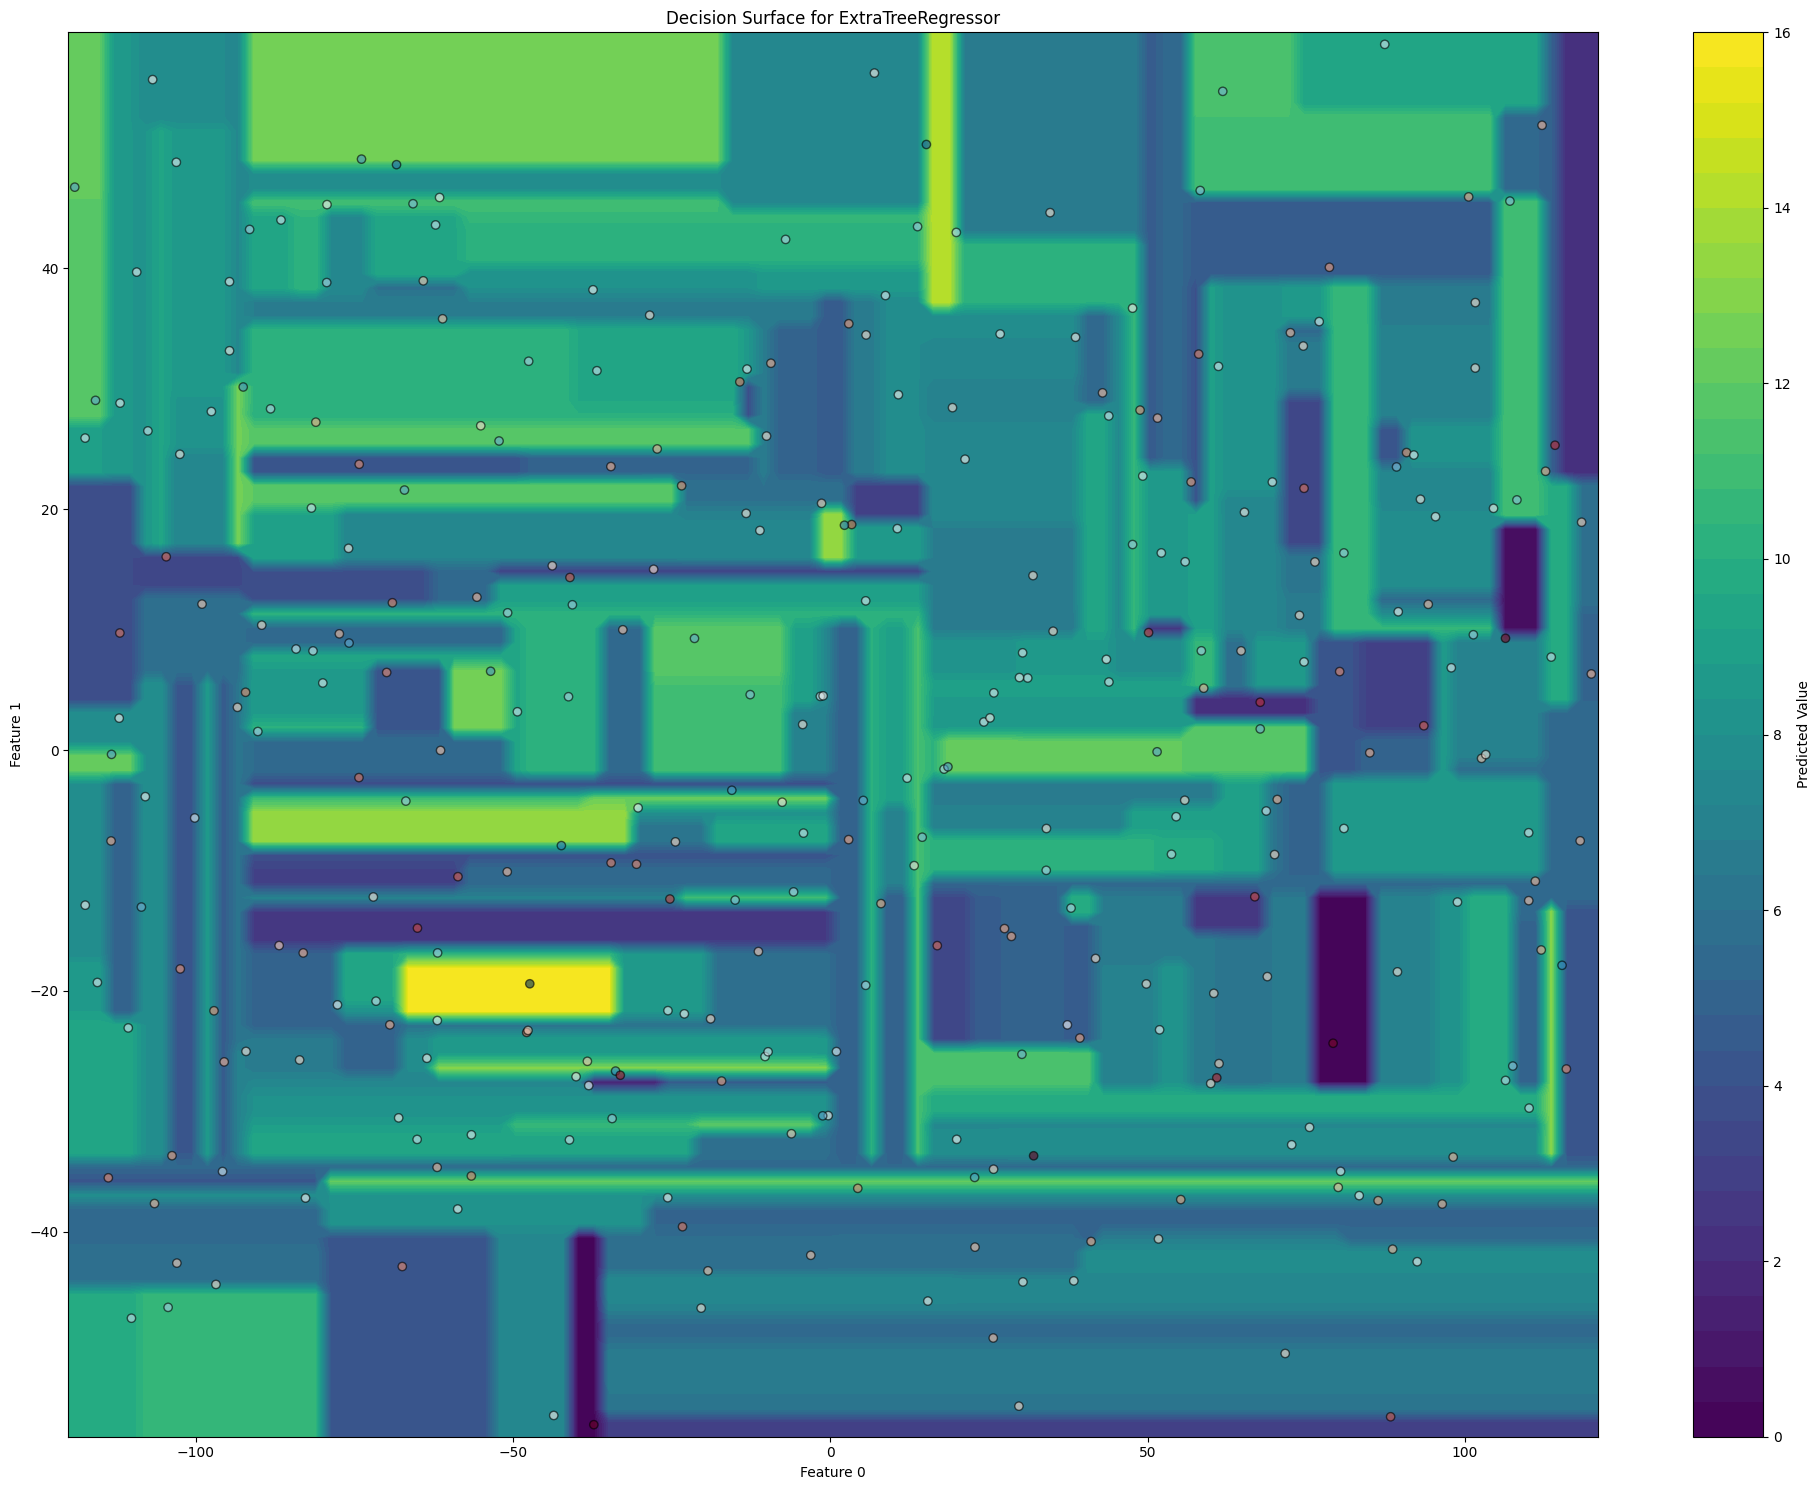

----------------------------------------------------------------------------------------------------


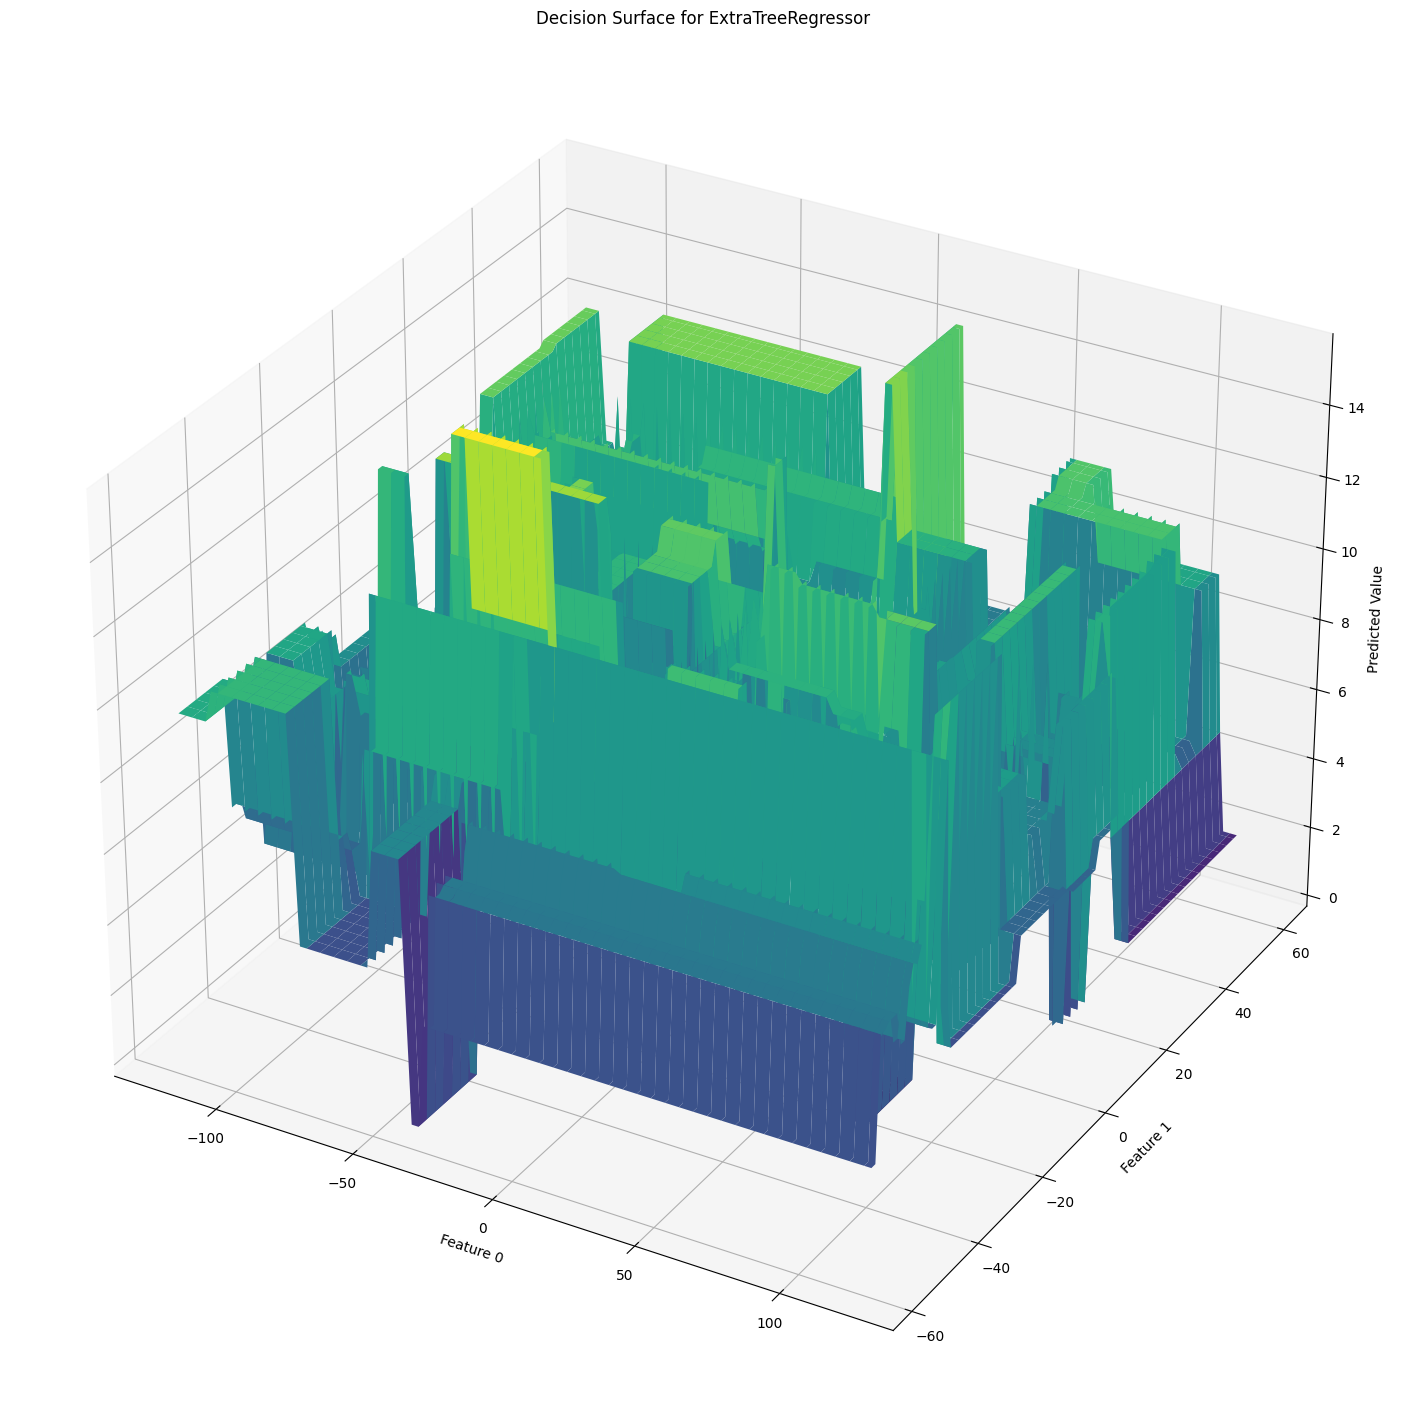

In [ ]:
mesh_points = np.zeros((x1.size, x_train.shape[1]))
mesh_points[:, feature_1_idx] = x1.ravel()
mesh_points[:, feature_2_idx] = x2.ravel()

for i in range(x_train.shape[1]):
    if i not in [feature_1_idx, feature_2_idx]:
        mesh_points[:, i] = x_train[:, i].mean()
model=ExtraTreeRegressor(random_state=42)
model=model.fit(x_train, y_train)
predictions = model.predict(mesh_points)
predictions = predictions.reshape(x1.shape)

plt.figure(figsize=(20, 15))
plt.contourf(x1, x2, predictions, cmap='viridis', levels=50)
plt.colorbar(label='Predicted Value')
plt.scatter(x_train[:, feature_1_idx], x_train[:, feature_2_idx], c=y_train, edgecolor='k', cmap='RdBu', alpha=0.6)
plt.xlabel(feature_1_name)
plt.ylabel(feature_2_name)
plt.title(f'Decision Surface for {name}')
plt.tight_layout()
plt.show()
print('-'*100)
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(25, 18))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(x1, x2, predictions, cmap='viridis')
ax.set_xlabel(feature_1_name)
ax.set_ylabel(feature_2_name)
ax.set_zlabel('Predicted Value')
plt.title(f'Decision Surface for {name}')
plt.show()

**After Hyperparameters Tuning (Extra Tree)**

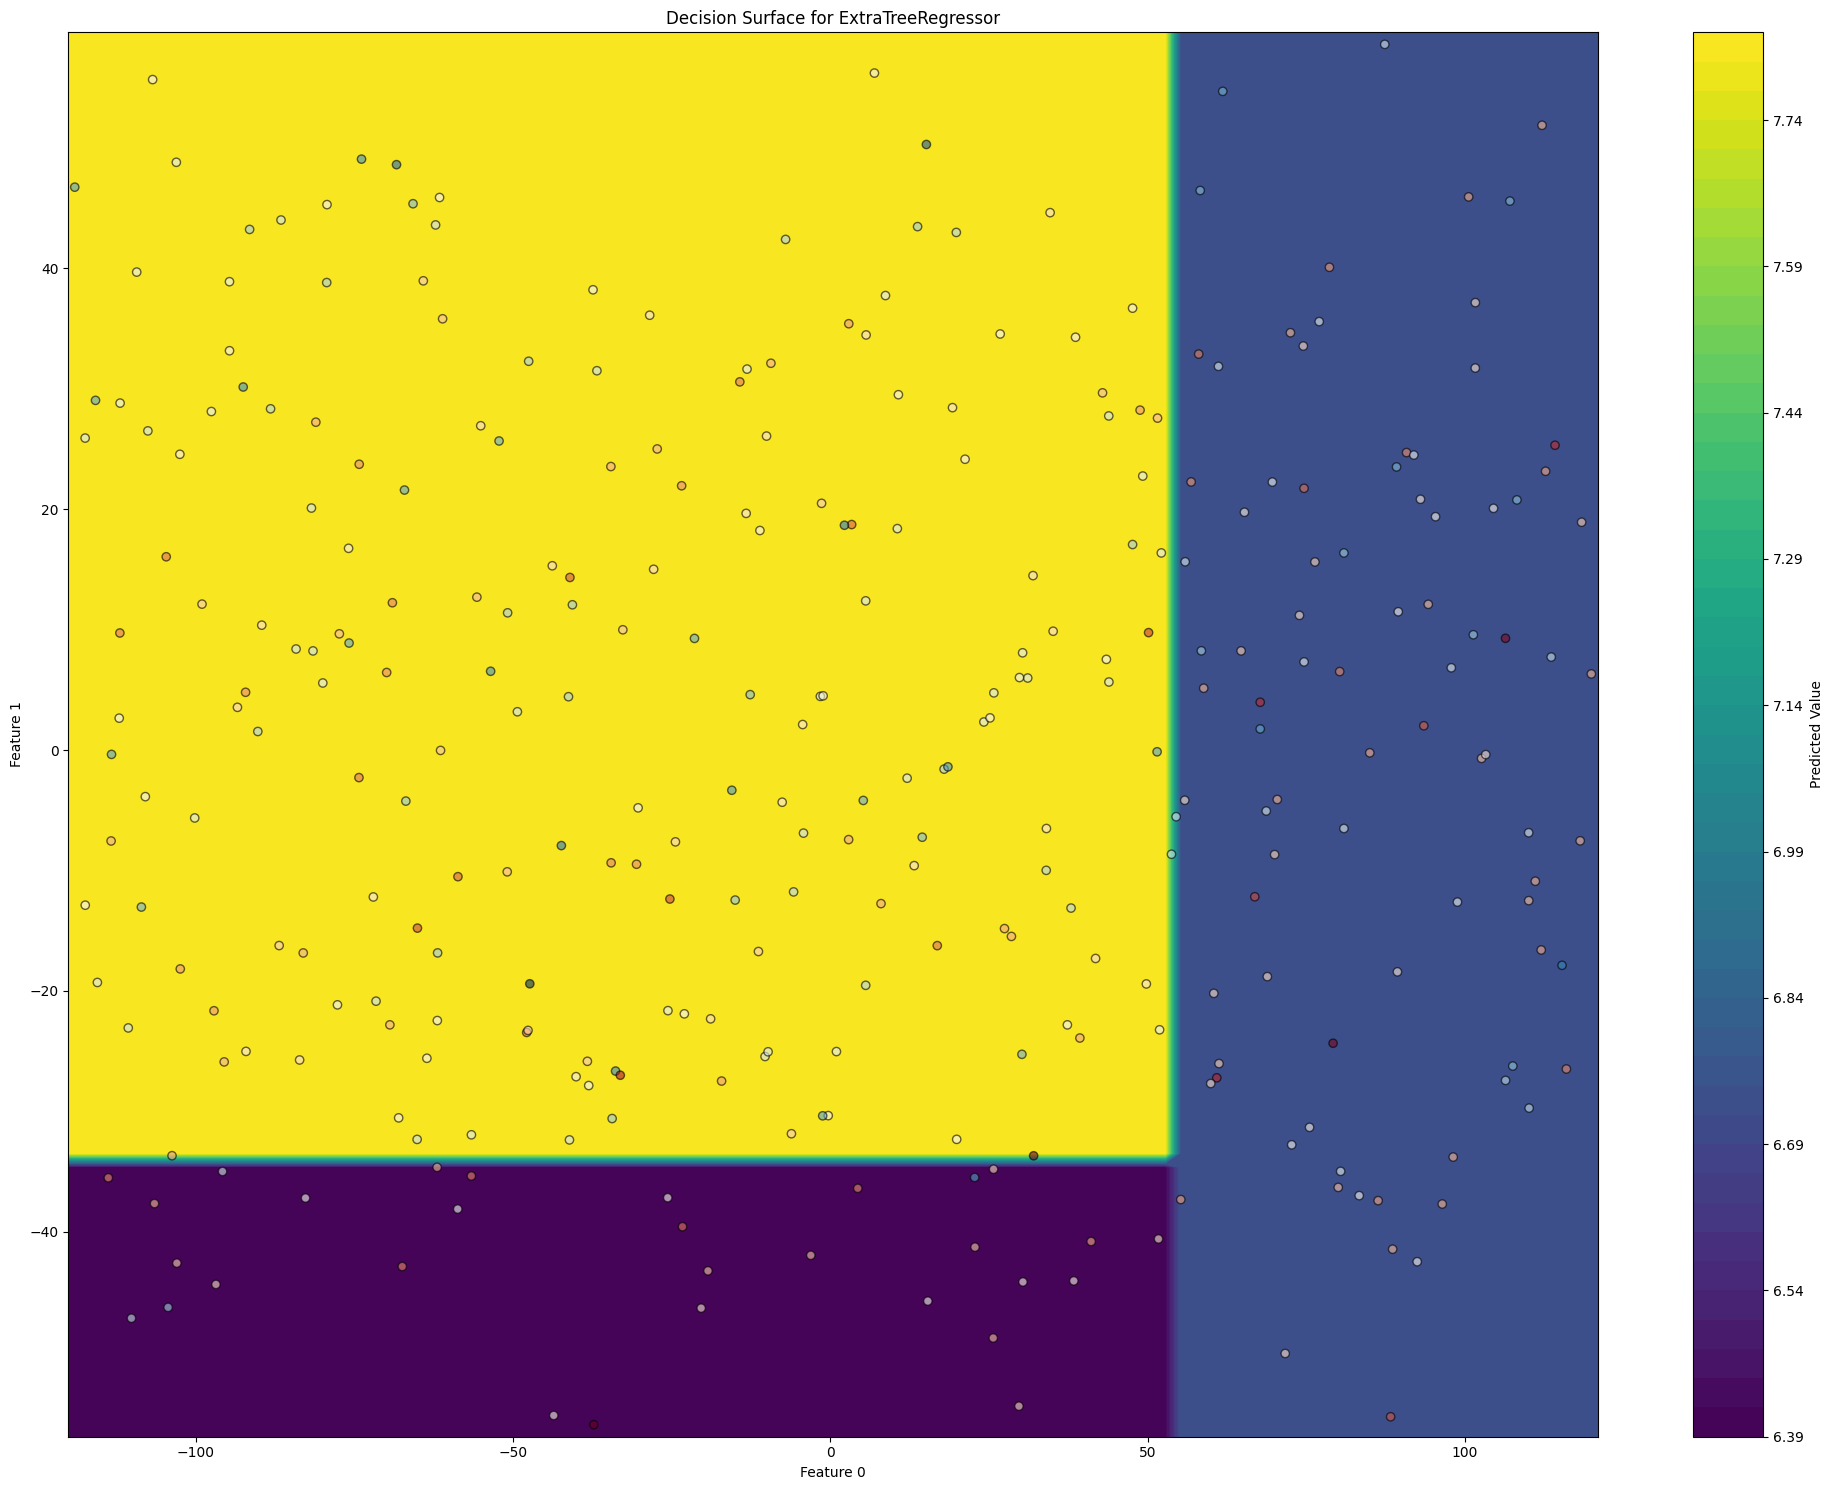

----------------------------------------------------------------------------------------------------


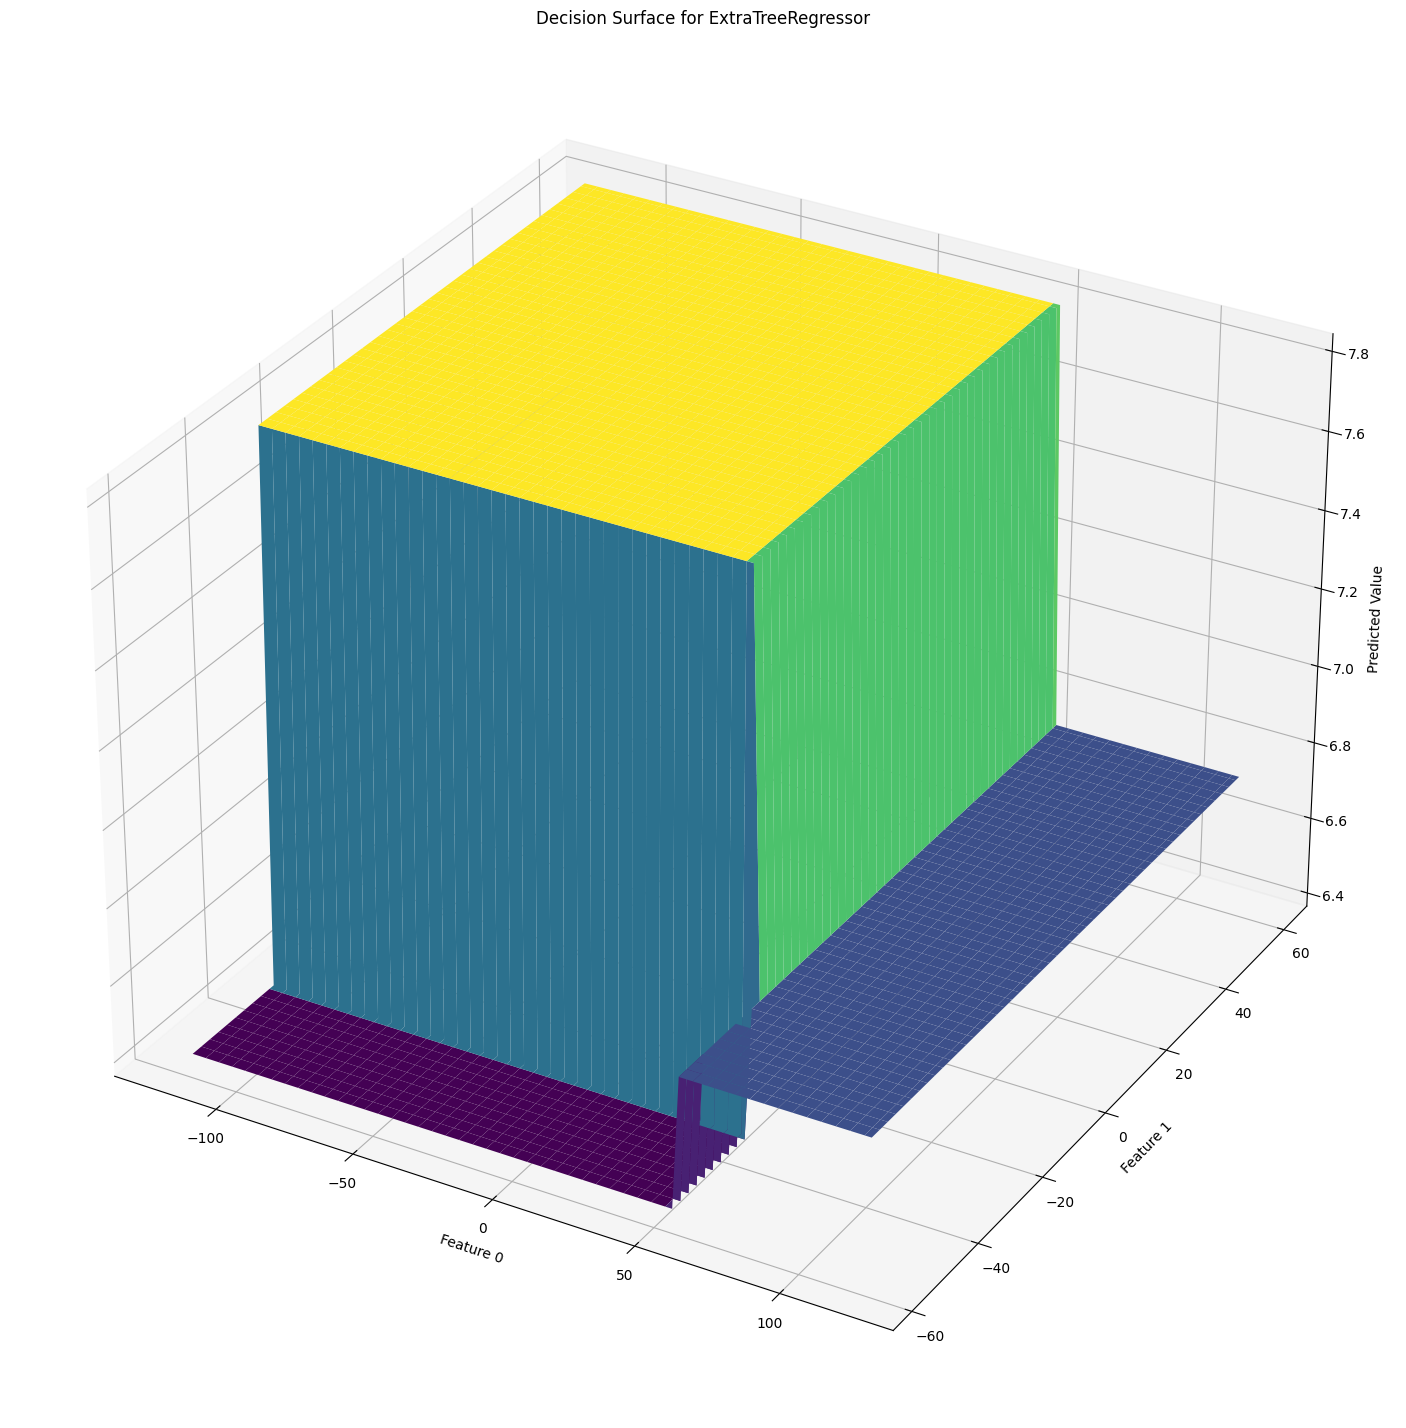

In [ ]:
mesh_points = np.zeros((x1.size, x_train.shape[1]))
mesh_points[:, feature_1_idx] = x1.ravel()
mesh_points[:, feature_2_idx] = x2.ravel()
    
for i in range(x_train.shape[1]):
    if i not in [feature_1_idx, feature_2_idx]:
        mesh_points[:, i] = x_train[:, i].mean()

predictions = best_model.predict(mesh_points)
predictions = predictions.reshape(x1.shape)

plt.figure(figsize=(20, 15))
plt.contourf(x1, x2, predictions, cmap='viridis', levels=50)
plt.colorbar(label='Predicted Value')
plt.scatter(x_train[:, feature_1_idx], x_train[:, feature_2_idx], c=y_train, edgecolor='k', cmap='RdBu', alpha=0.6)
plt.xlabel(feature_1_name)
plt.ylabel(feature_2_name)
plt.title(f'Decision Surface for {name}')
plt.tight_layout()
plt.show()
print('-'*100)

fig = plt.figure(figsize=(25, 18))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(x1, x2, predictions, cmap='viridis')
ax.set_xlabel(feature_1_name)
ax.set_ylabel(feature_2_name)
ax.set_zlabel('Predicted Value')
plt.title(f'Decision Surface for {name}')
plt.show()

**Decision Surface Comparison**

The visualization of the decision surface for the Extra Tree Regressor before tuning shows a highly complex, granular, and irregular surface, indicative of a model that perfectly fits the training data (overfitting) by creating many small, distinct prediction regions.

In contrast, the decision surface after tuning is significantly smoother and features larger, less numerous prediction regions. This transformation demonstrates the effectiveness of the regularization hyperparameters. The optimized model sacrifices some training accuracy for better generalization by simplifying the decision boundaries, making it less sensitive to noise and local fluctuations in the training data.

**Goodness of Fit Before and After Hyperparameters Tuning**

**Goodness of Fit Extra Tree Before Hyperparameters Tuning (First Feature)**

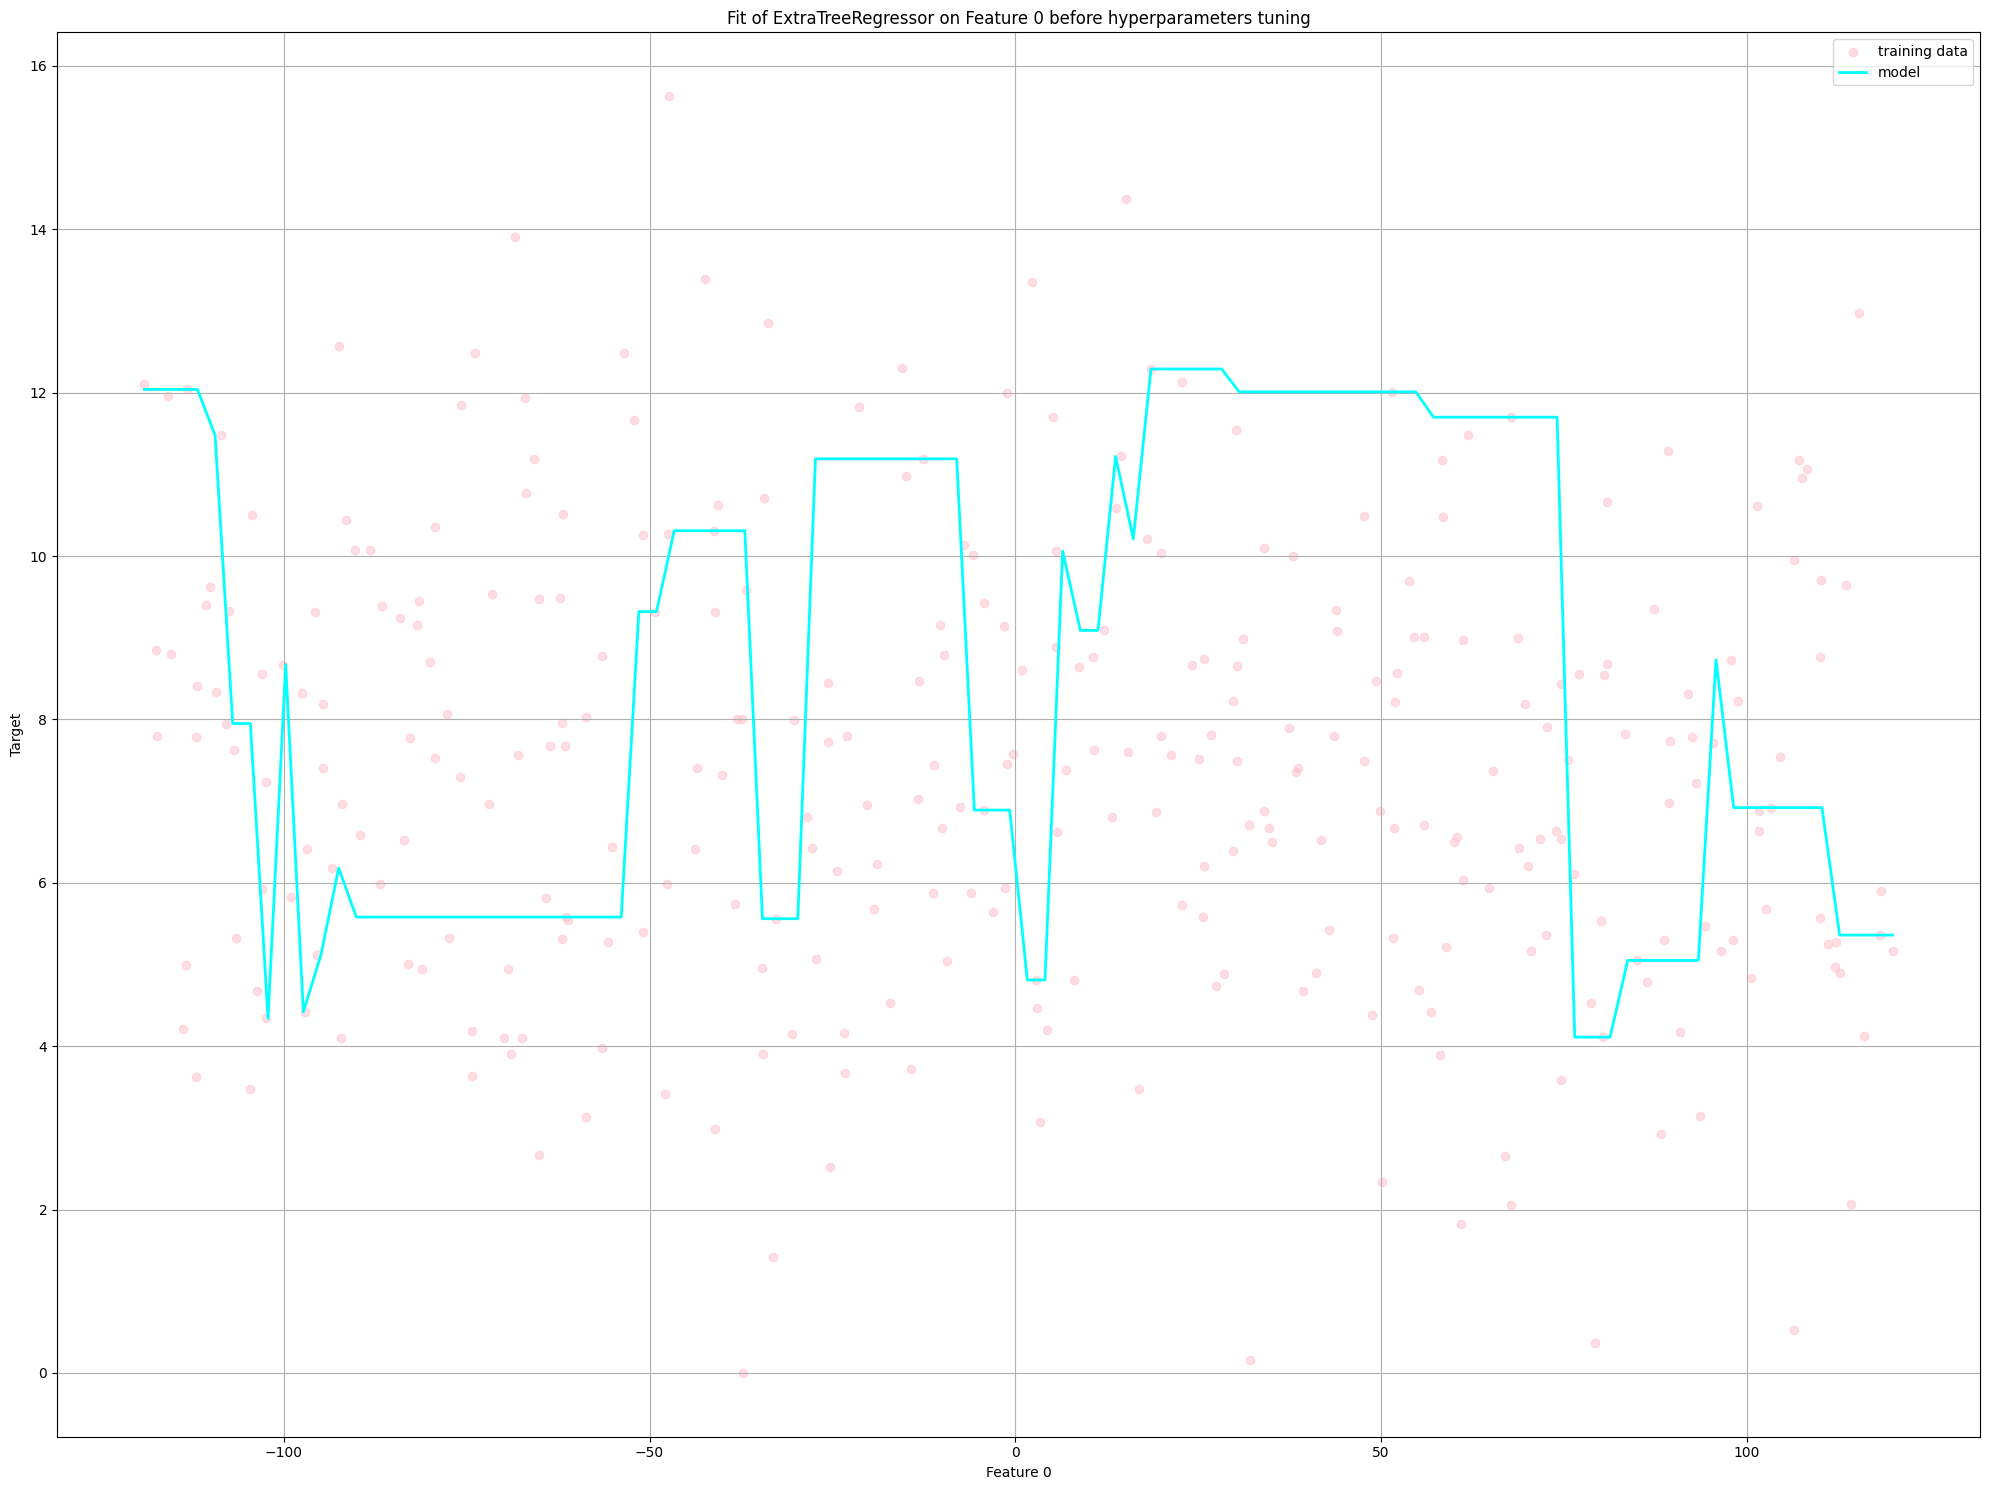

In [ ]:
if isinstance(x_train, pd.DataFrame):
    x_train = x_train.values
if isinstance(y_train, pd.Series):
    y_train = y_train.values

feature_idx = 0
feature_name = f"Feature {feature_idx}" if not isinstance(x_train, pd.DataFrame) else x_train.columns[feature_idx]
x_feature = x_train[:, feature_idx]

x_range = np.linspace(x_feature.min(), x_feature.max(), 100)

n_features = x_train.shape[1]
x_range_full = np.zeros((x_range.shape[0], n_features))
x_range_full[:, feature_idx] = x_range

for i in range(n_features):
    if i != feature_idx:
        x_range_full[:, i] = x_train[:, i].mean()

model = ExtraTreeRegressor(random_state=42)
model = model.fit(x_train, y_train)
y_pred = model.predict(x_range_full)

plt.figure(figsize=(20, 15))
plt.scatter(x_feature, y_train, color='pink', alpha=0.5, label='training data')
plt.plot(x_range, y_pred, color='cyan', label='model', linewidth=2)
plt.xlabel(feature_name)
plt.ylabel('Target')
plt.title(f'Fit of ExtraTreeRegressor on {feature_name} before hyperparameters tuning')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**Goodness of Fit Extra Tree After Hyperparameters Tuning (First Feature)**

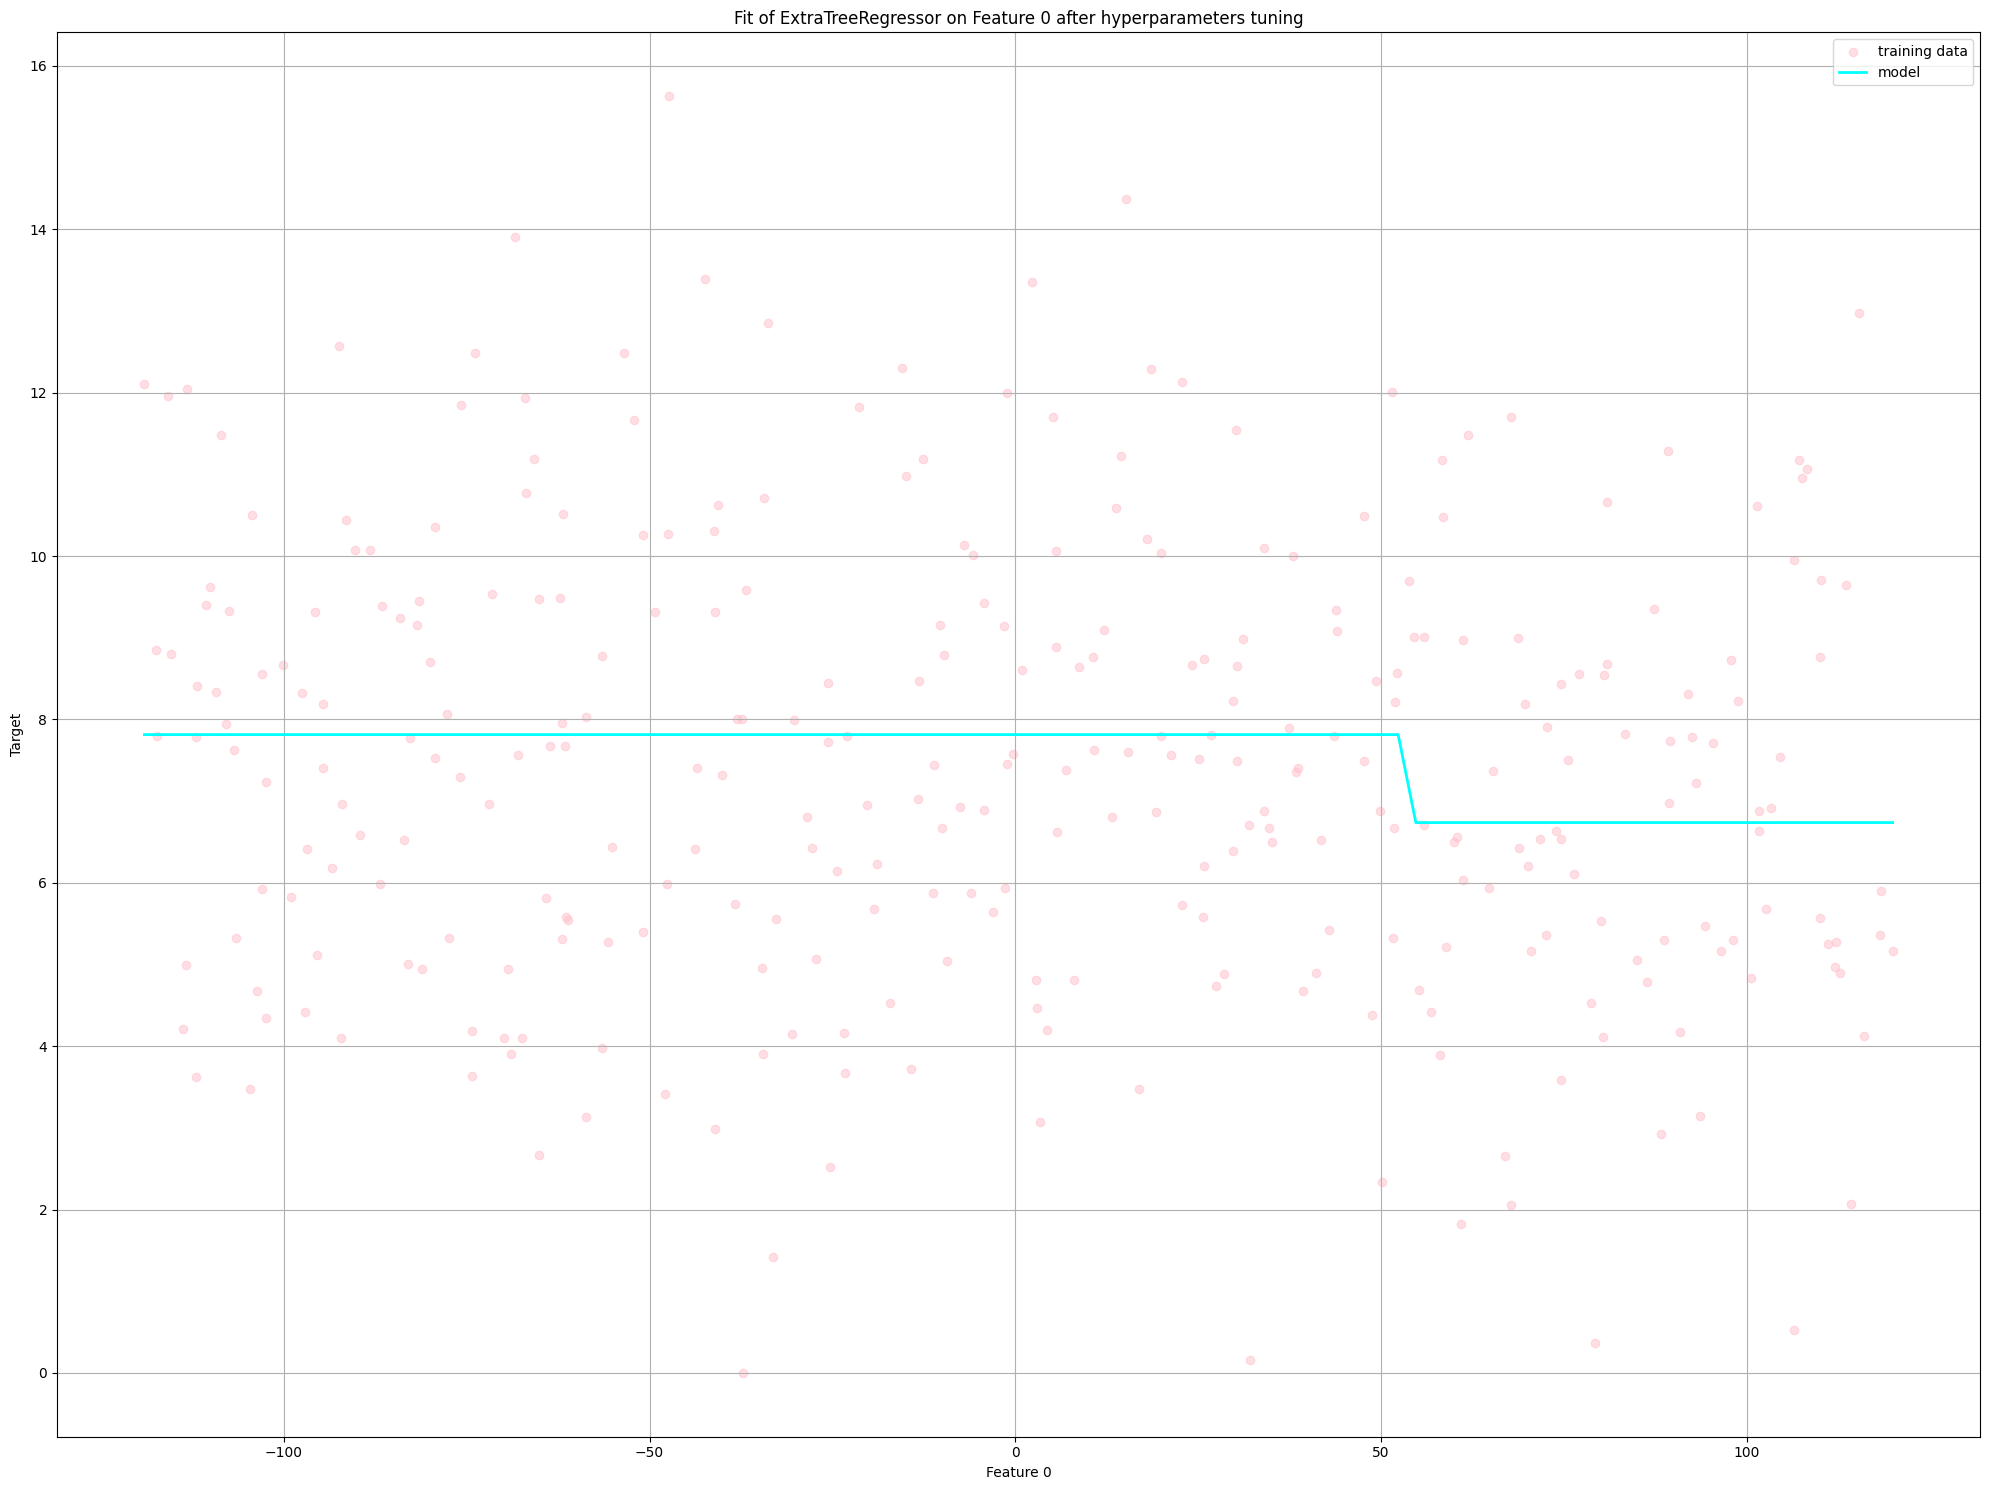

In [ ]:
if isinstance(x_train, pd.DataFrame):
    x_train = x_train.values
if isinstance(y_train, pd.Series):
    y_train = y_train.values

feature_idx = 0
feature_name = f"Feature {feature_idx}" if not isinstance(x_train, pd.DataFrame) else x_train.columns[feature_idx]
x_feature = x_train[:, feature_idx]

x_range = np.linspace(x_feature.min(), x_feature.max(), 100)

n_features = x_train.shape[1]
x_range_full = np.zeros((x_range.shape[0], n_features))
x_range_full[:, feature_idx] = x_range

for i in range(n_features):
    if i != feature_idx:
        x_range_full[:, i] = x_train[:, i].mean()

y_pred = best_model.predict(x_range_full)

plt.figure(figsize=(20, 15))
plt.scatter(x_feature, y_train, color='pink', alpha=0.5, label='training data')
plt.plot(x_range, y_pred, color='cyan', label='model', linewidth=2)
plt.xlabel(feature_name)
plt.ylabel('Target')
plt.title(f'Fit of ExtraTreeRegressor on {feature_name} after hyperparameters tuning')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**Goodness of Fit Extra Tree Before Hyperparameters Tuning (Second Feature)**

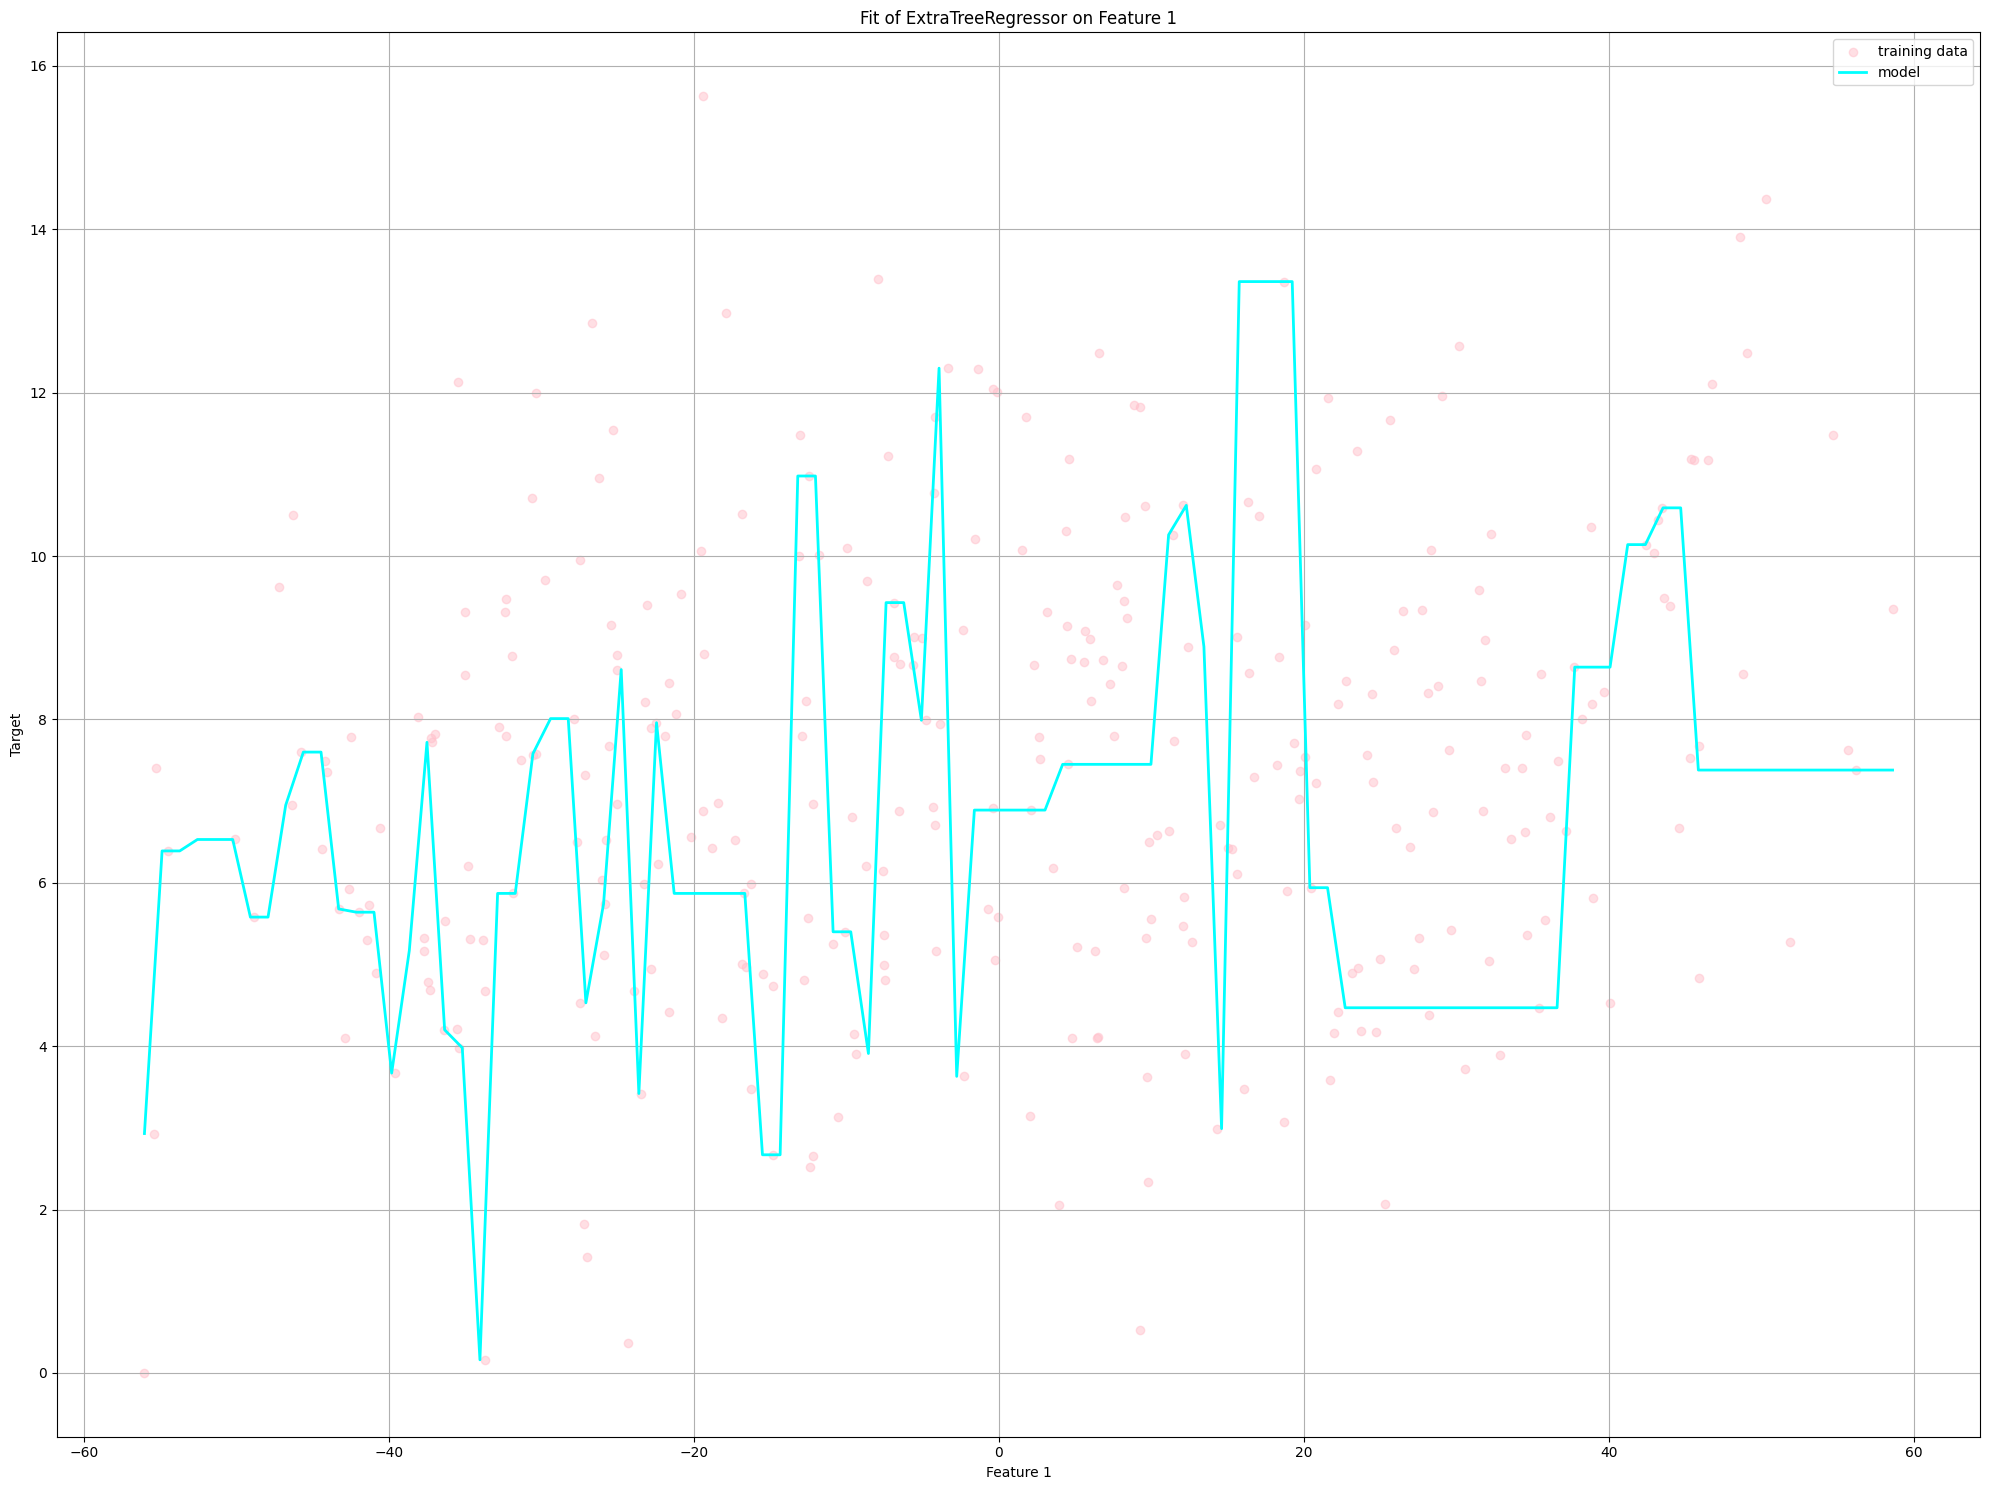

In [ ]:
if isinstance(x_train, pd.DataFrame):
    x_train = x_train.values
if isinstance(y_train, pd.Series):
    y_train = y_train.values

feature_idx = 1
feature_name = f"Feature {feature_idx}" if not isinstance(x_train, pd.DataFrame) else x_train.columns[feature_idx]
x_feature = x_train[:, feature_idx]

x_range = np.linspace(x_feature.min(), x_feature.max(), 100)

n_features = x_train.shape[1]
x_range_full = np.zeros((x_range.shape[0], n_features))
x_range_full[:, feature_idx] = x_range

for i in range(n_features):
    if i != feature_idx:
        x_range_full[:, i] = x_train[:, i].mean()

model = ExtraTreeRegressor(random_state=42)
model = model.fit(x_train, y_train)
y_pred = model.predict(x_range_full)

plt.figure(figsize=(20, 15))
plt.scatter(x_feature, y_train, color='pink', alpha=0.5, label='training data')
plt.plot(x_range, y_pred, color='cyan', label='model', linewidth=2)
plt.xlabel(feature_name)
plt.ylabel('Target')
plt.title(f'Fit of ExtraTreeRegressor on {feature_name}')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**Goodness of Fit Extra Tree After Hyperparameters Tuning (Second Feature)**

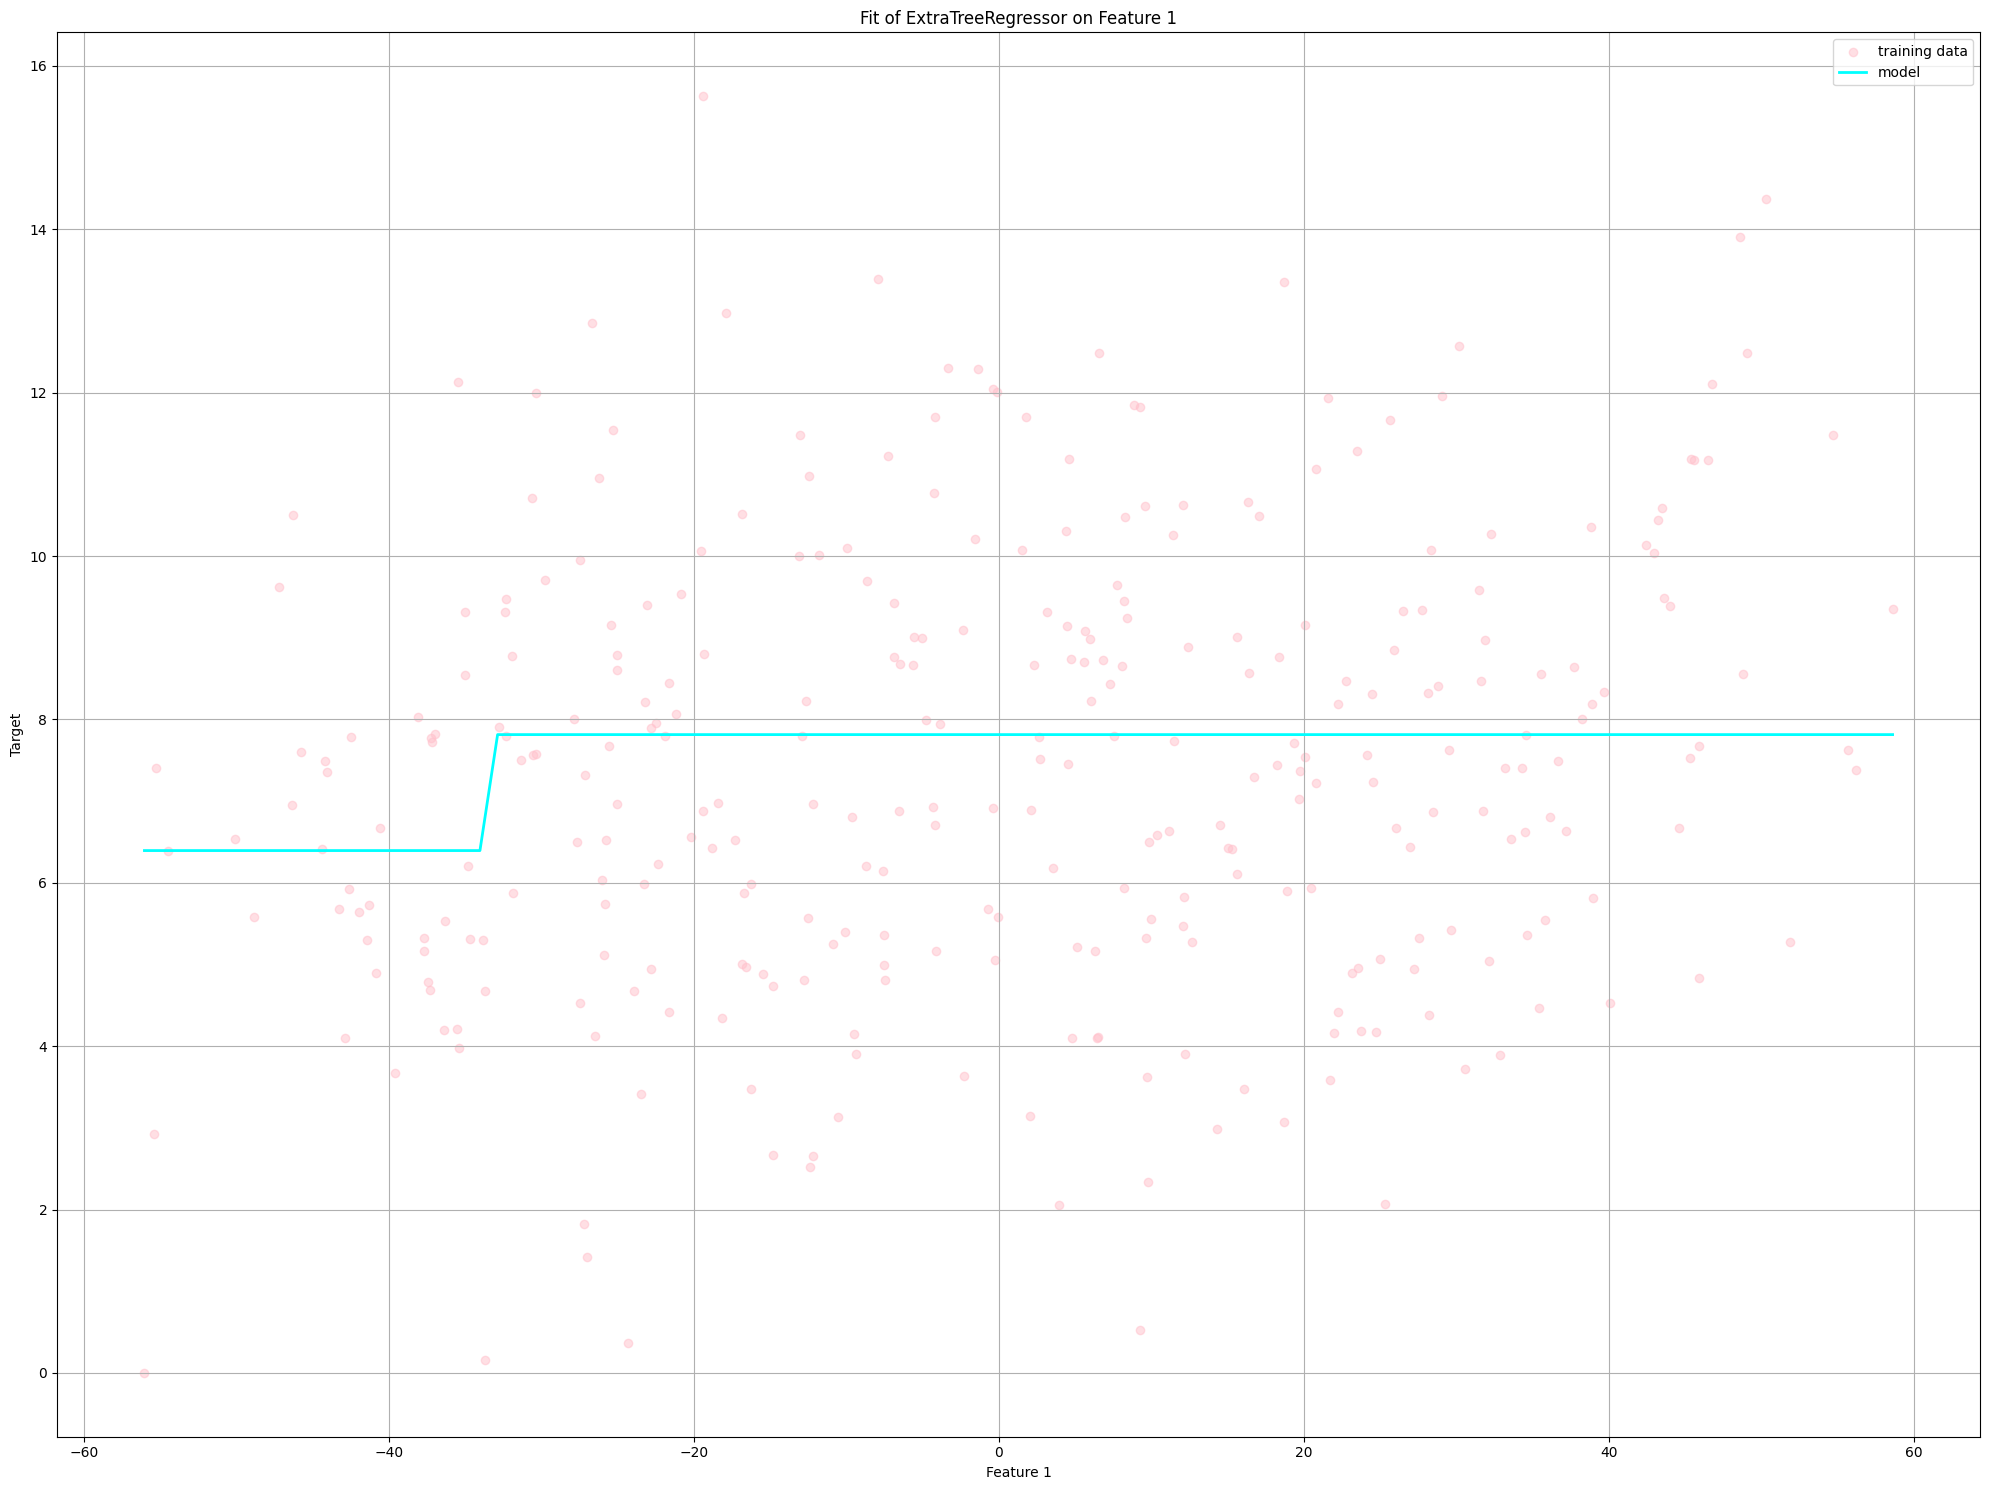

In [ ]:
if isinstance(x_train, pd.DataFrame):
    x_train = x_train.values
if isinstance(y_train, pd.Series):
    y_train = y_train.values

feature_idx = 1
feature_name = f"Feature {feature_idx}" if not isinstance(x_train, pd.DataFrame) else x_train.columns[feature_idx]
x_feature = x_train[:, feature_idx]

x_range = np.linspace(x_feature.min(), x_feature.max(), 100)

n_features = x_train.shape[1]
x_range_full = np.zeros((x_range.shape[0], n_features))
x_range_full[:, feature_idx] = x_range

for i in range(n_features):
    if i != feature_idx:
        x_range_full[:, i] = x_train[:, i].mean()

y_pred = best_model.predict(x_range_full)

plt.figure(figsize=(20, 15))
plt.scatter(x_feature, y_train, color='pink', alpha=0.5, label='training data')
plt.plot(x_range, y_pred, color='cyan', label='model', linewidth=2)
plt.xlabel(feature_name)
plt.ylabel('Target')
plt.title(f'Fit of ExtraTreeRegressor on {feature_name}')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**1D Fit Comparison**

The 1D plots, which visualize the model's predicted values against individual features, highlight the change in flexibility.

- Before Tuning (Unoptimized): The regression line is extremely jagged, showing rapid, high-frequency steps. This aggressive segmentation attempts to precisely capture every point, characteristic of high variance and overfitting.
- After Tuning (Optimized): The regression line still displays the step-wise nature inherent to tree models, but the steps are broader and fewer. The fit appears more generalized, capturing the overall trend of the data rather than chasing individual training points. This smoothed fit confirms that the regularization parameters (like max_depth and ccp_alpha) successfully constrained the model's complexity, leading to a more robust and generalized regression function.

# Model Evaluation

**Regression Metrics Evaluation**

Model evaluation is the final step in the machine learning workflow, where the model's predictive capabilities are rigorously assessed on unseen data (the test set). This process verifies how well the model generalizes beyond the training examples and provides a measure of its expected performance in a real-world scenario.The evaluation utilizes standard regression metrics:
- Mean Squared Error (MSE) and Root Mean Squared Error (RMSE): These quantify the average squared and square-rooted squared differences between the predicted and actual values. They heavily penalize larger errors, making them sensitive indicators of outliers.
- Mean Absolute Error (MAE): This measures the average magnitude of the errors, providing a linear measure of prediction deviation that is less sensitive to outliers than MSE.
- $R^2$ Score (Coefficient of Determination): This metric indicates the proportion of the variance in the dependent variable that is predictable from the independent variables. An $R^2$ of $1.0$ indicates a perfect fit, while an $R^2$ near $0.0$ suggests the model explains little of the variability. A negative $R^2$ score implies the model performs worse than simply predicting the mean of the target data.

**Model Training with Best Hyperparameters (Extra Tree)**

In [ ]:
best_params = {
    'criterion': 'squared_error',
    'max_depth': 15,
    'min_samples_split': 5,
    'min_samples_leaf': 2,
    'max_features': 'sqrt',
    'min_impurity_decrease': 0.05,
    'ccp_alpha': 0.01
}
best_model = ExtraTreeRegressor(random_state=42, **best_params)
best_model.fit(x_train, y_train)

y_test_pred = best_model.predict(x_test)

def evaluate_regression(y_true, y_pred, dataset_name):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    print(f"{dataset_name} Metrics:")
    print(f"R² Score: {r2:.4f}")
    print(f"Mean Absolute Error (MAE): {mae:.4f}")
    print(f"Mean Squared Error (MSE): {mse:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}\n")
    return r2, mae, mse, rmse

evaluate_regression(y_test, y_test_pred, "Test Set")

Test Set Metrics:
R² Score: -0.1223
Mean Absolute Error (MAE): 2.6290
Mean Squared Error (MSE): 11.1068
Root Mean Squared Error (RMSE): 3.3327



(-0.1223297799958083,
 2.6289679597701157,
 11.106802757082566,
 3.3326870175704415)

**Interpretation of Results**

Quantitative MetricsThe model evaluation on the test set yields the following results: $R^2$ Score: $-0.1223$, MAE: $2.6290$, MSE: $11.1068$, and RMSE: $3.3327$.

The negative $R^2$ score is the most critical finding, indicating that the optimized Extra Tree Regressor performs worse on the unseen test data than a naive model that simply predicts the average of the target variable. This result strongly suggests that even after hyperparameter tuning, the model suffers from poor generalization, possibly due to remaining overfitting to the training data or fundamental limitations in capturing the true relationship within the dataset. The RMSE of $3.3327$ means the average prediction error magnitude, in the original units of the target, is around $3.33$.

**Decision Boundary**

The visualization phase interprets the model's behavior by projecting its complex, multi-dimensional decision function onto two and one-dimensional spaces. The Decision Surface Plot (2D and 3D) illustrates the model's predicted output across a grid formed by two selected features, holding other features constant at their mean values. The Actual vs. Predicted Plot and Residual Plot are essential tools for diagnosing model quality:
- The Actual vs. Predicted Plot shows the correlation between the true values and the model's predictions. Points tightly clustered along the $45^\circ$ perfect prediction line indicate high accuracy.
- The Residual Plot displays the difference between the true and predicted values (residuals) against the predicted values. For an ideal regression model, residuals should be randomly scattered around the zero horizontal line, indicating that the model's errors are random and not dependent on the magnitude of the prediction.

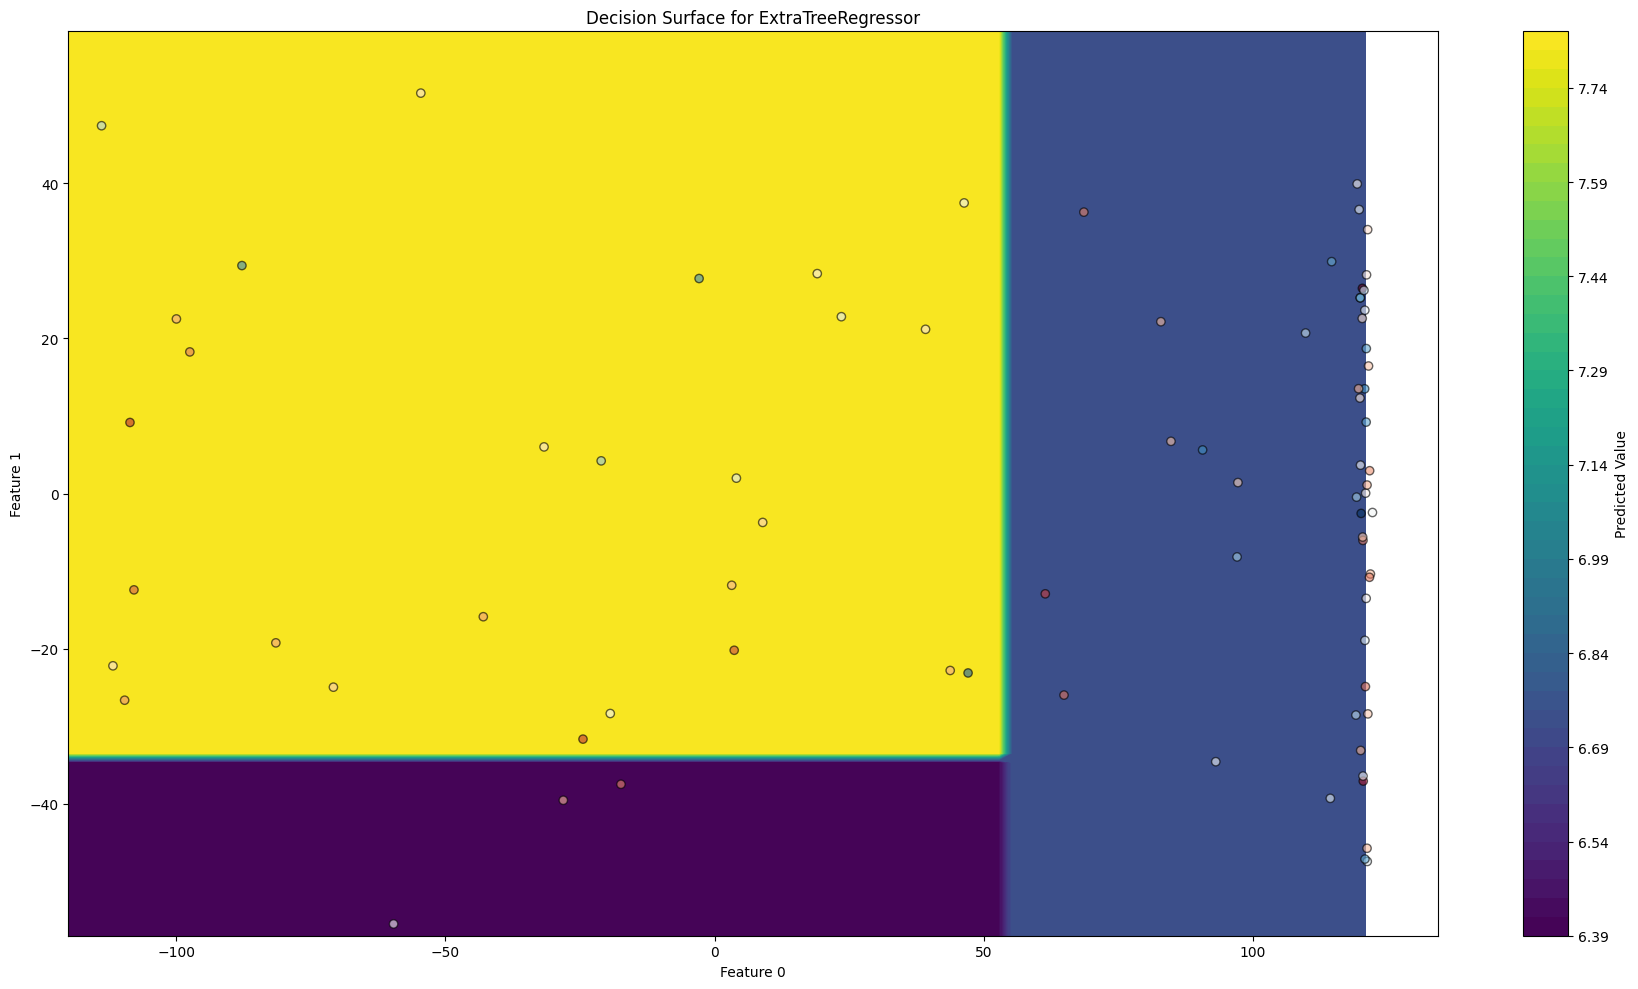

----------------------------------------------------------------------------------------------------


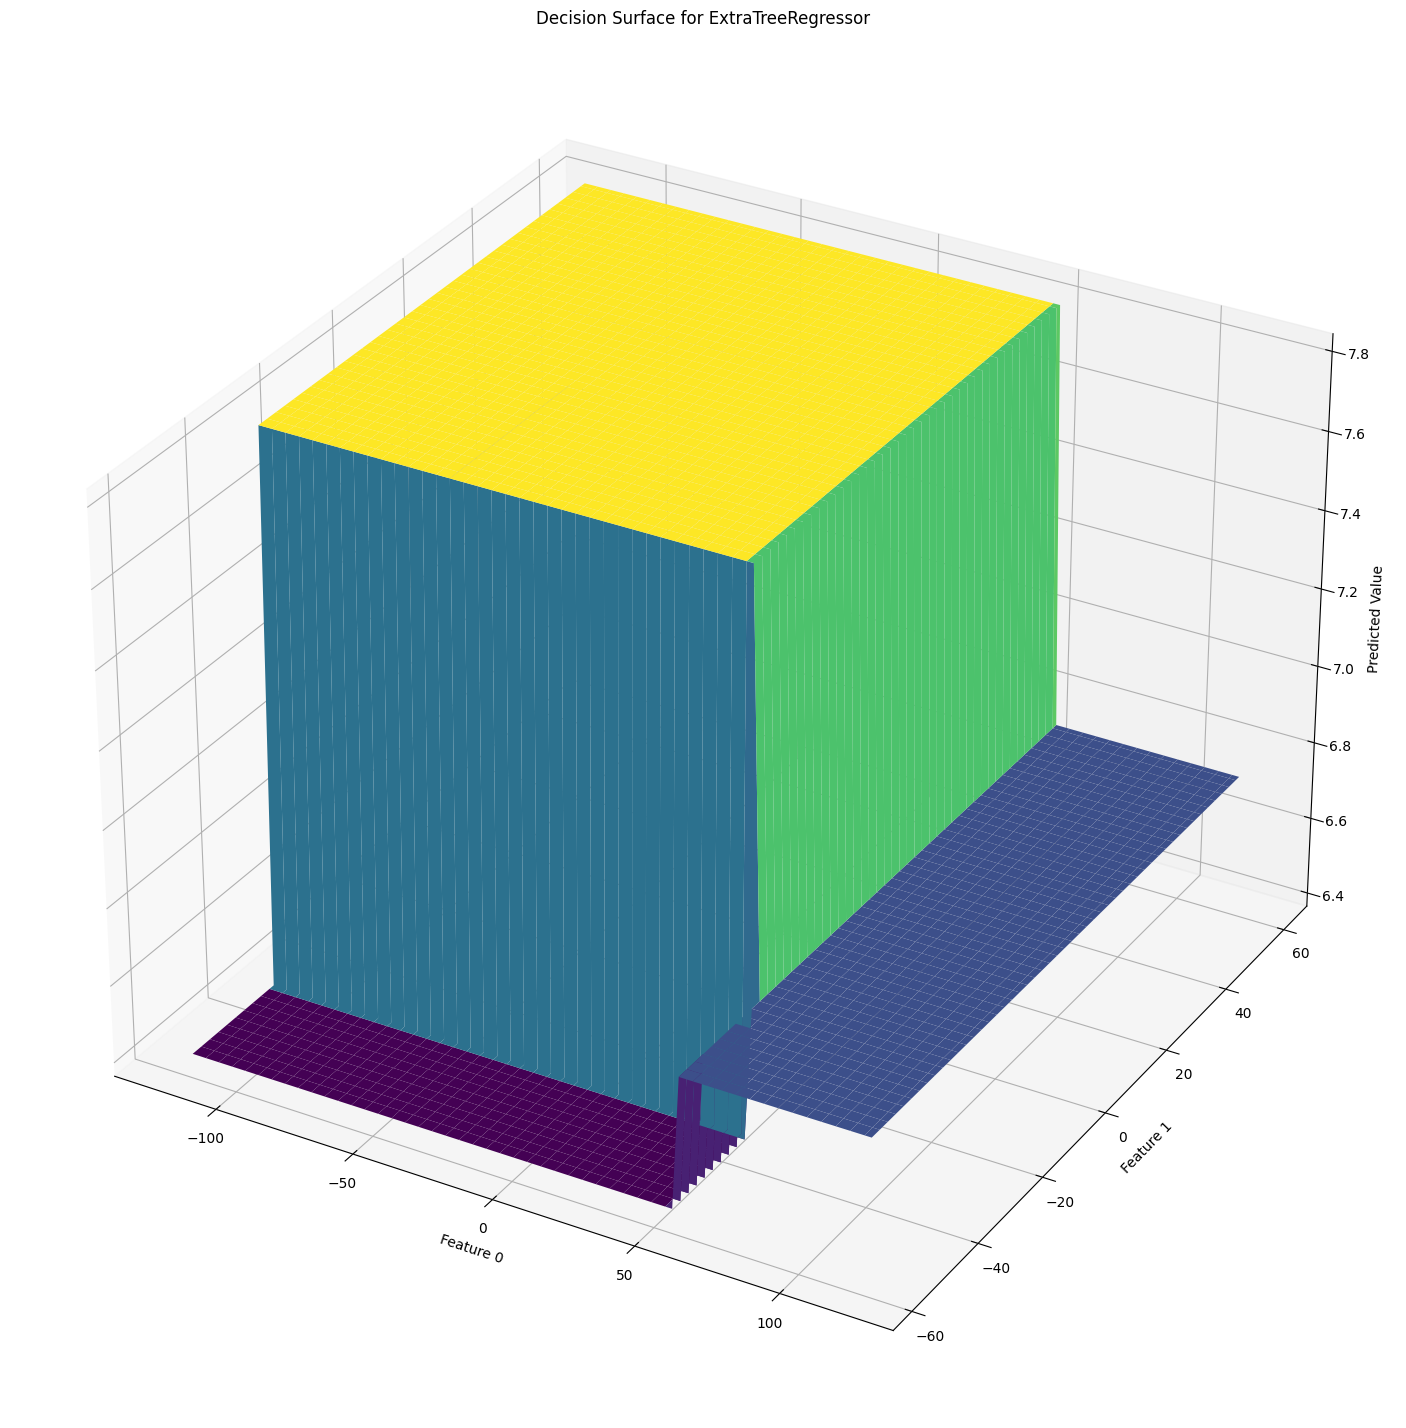

In [ ]:
mesh_points = np.zeros((x1.size, x_test.shape[1]))
mesh_points[:, feature_1_idx] = x1.ravel()
mesh_points[:, feature_2_idx] = x2.ravel()

for i in range(x_test.shape[1]):
    if i not in [feature_1_idx, feature_2_idx]:
        mesh_points[:, i] = x_train[:, i].mean()

predictions = best_model.predict(mesh_points)
predictions = predictions.reshape(x1.shape)

plt.figure(figsize=(18, 10))
plt.contourf(x1, x2, predictions, cmap='viridis', levels=50)
plt.colorbar(label='Predicted Value')
plt.scatter(x_test[:, feature_1_idx], x_test[:, feature_2_idx], c=y_test, edgecolor='k', cmap='RdBu', alpha=0.6)
plt.xlabel(feature_1_name)
plt.ylabel(feature_2_name)
plt.title(f'Decision Surface for {name}')
plt.tight_layout()
plt.show()
print('-'*100)

fig = plt.figure(figsize=(25, 18))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(x1, x2, predictions, cmap='viridis')
ax.set_xlabel(feature_1_name)
ax.set_ylabel(feature_2_name)
ax.set_zlabel('Predicted Value')
plt.title(f'Decision Surface for {name}')
plt.show()

**Decision Boundary and Generalization**

The Decision Surface Plot on the test data visually confirms the challenge. While the surfaces are smoother than the unoptimized model (as observed in the previous step), they still exhibit regions of high local variability and sharp, unnatural steps. These artifacts suggest that the model's prediction function, although regularized, is still too complex for the given data volume or noise level. The test data points, overlaid on the surface, show significant scatter across the predicted regions, aligning with the low performance metrics.

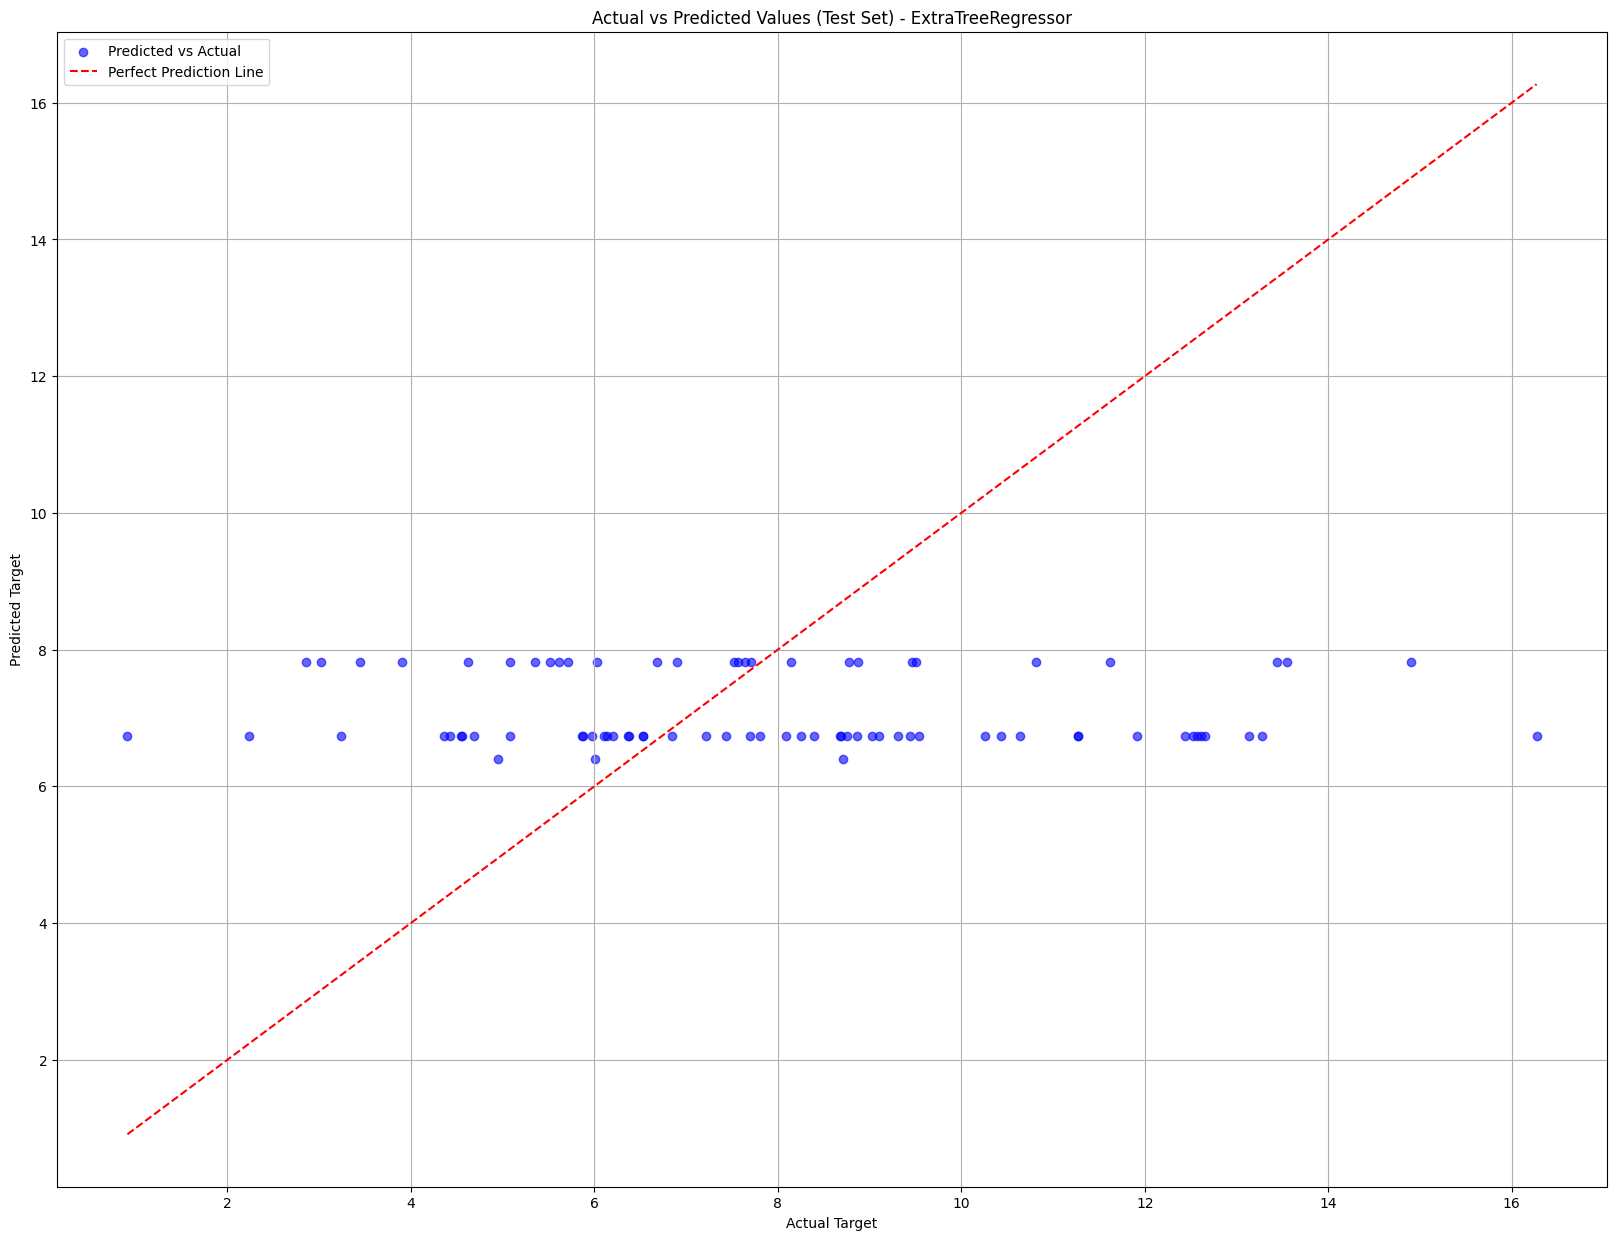

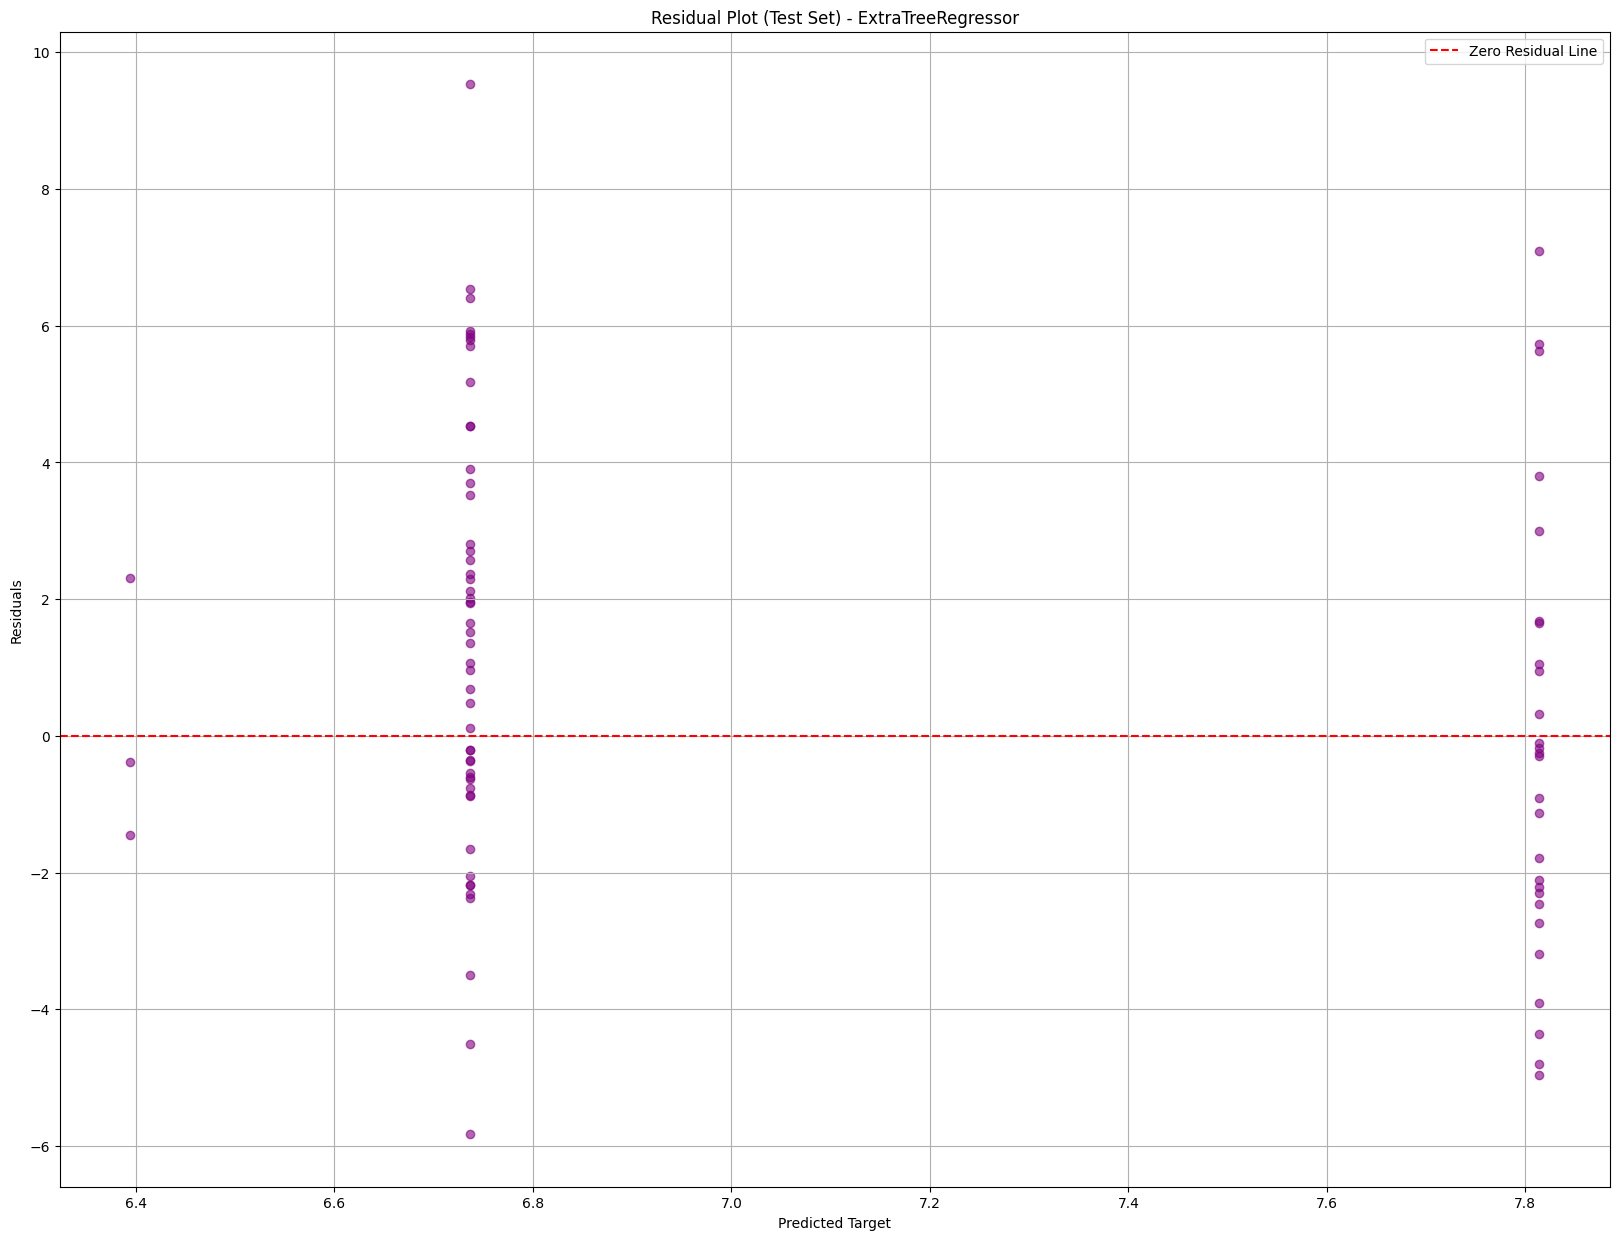

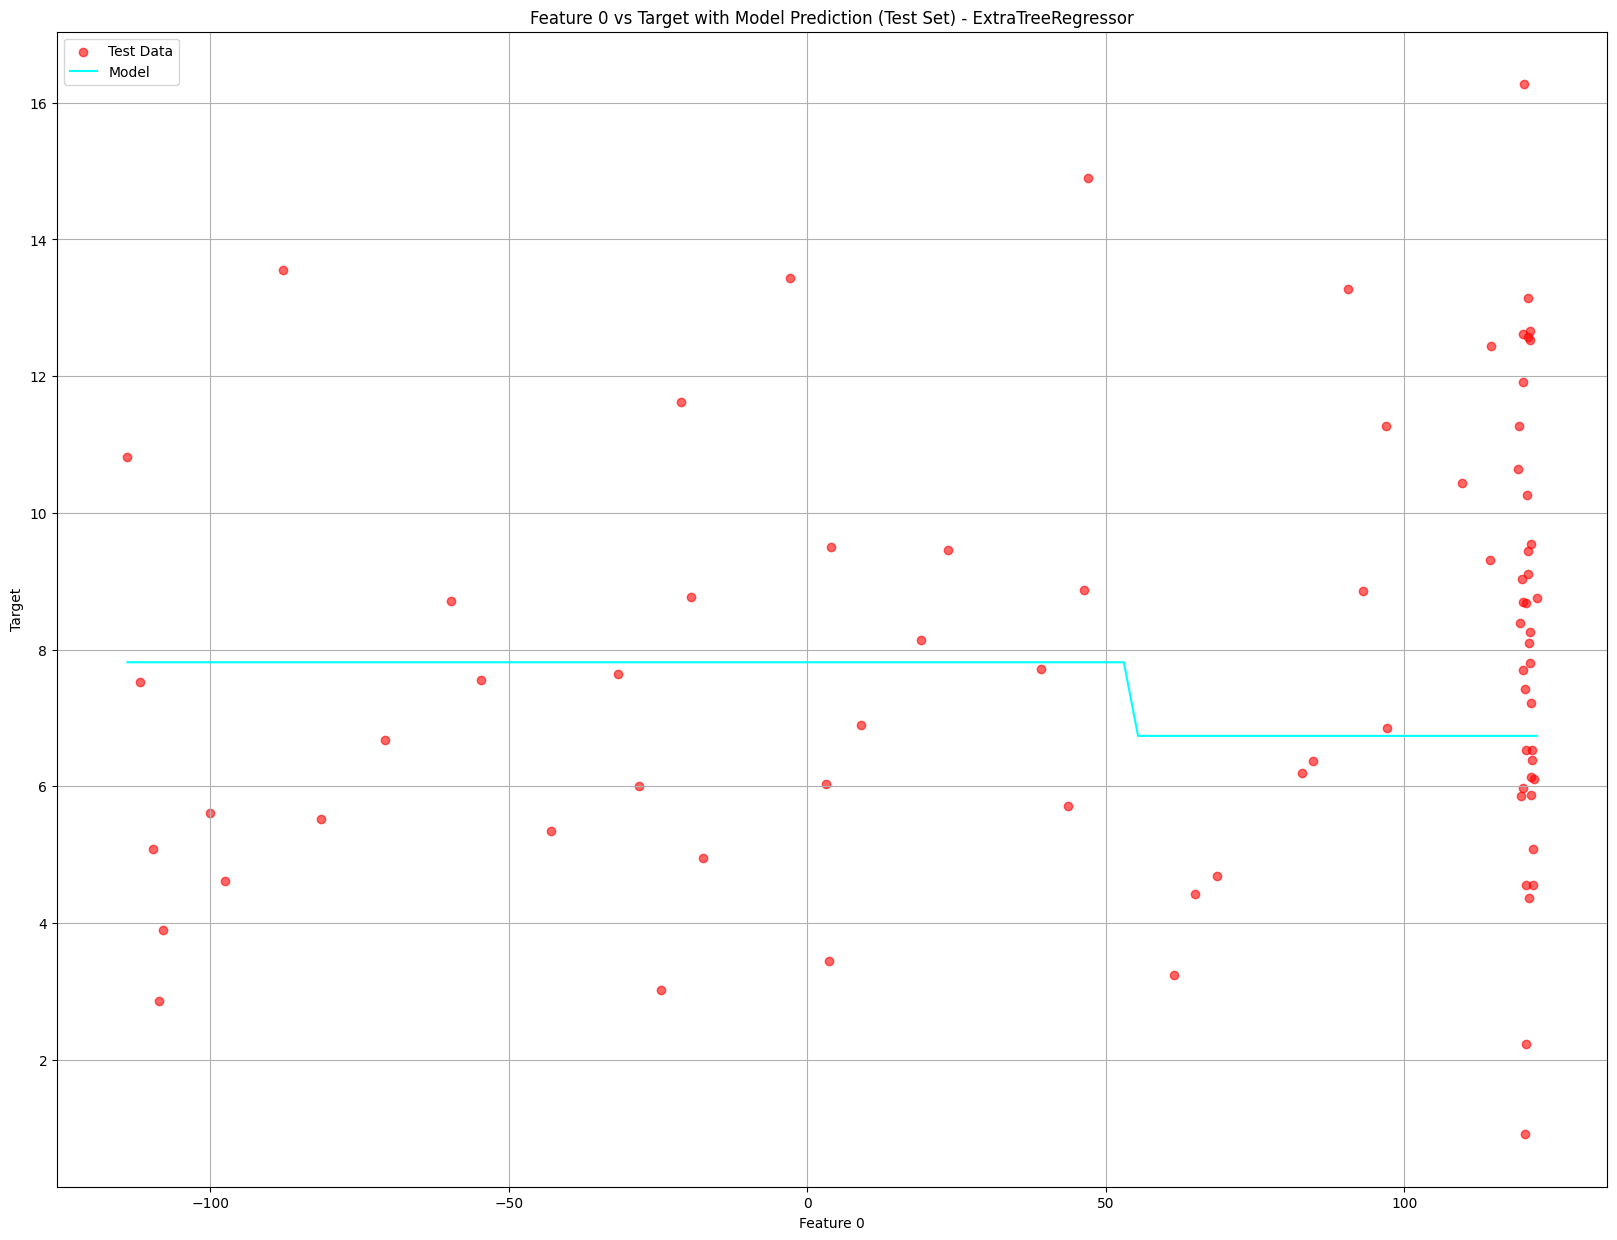

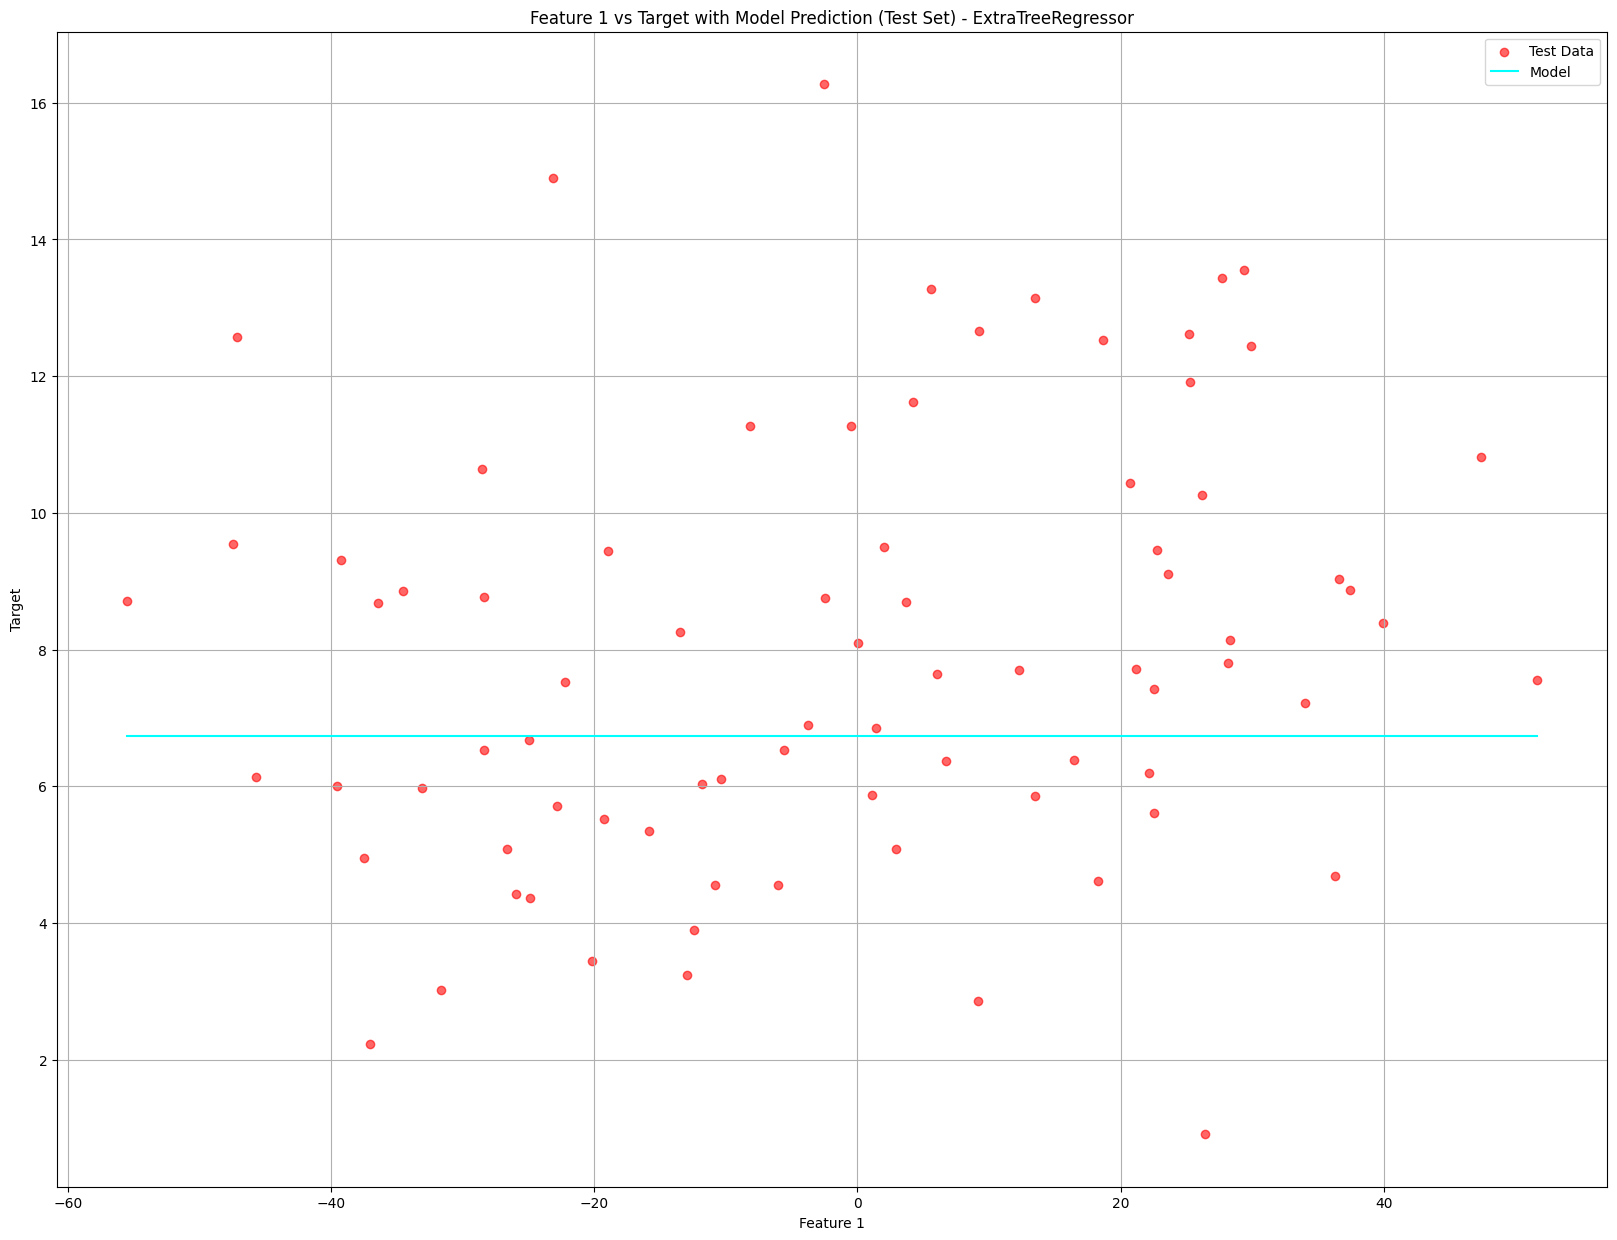

In [ ]:
plt.figure(figsize=(20, 15))
plt.scatter(y_test, y_test_pred, color="blue", label="Predicted vs Actual", alpha=0.6)

plt.plot([min(y_test.min(), y_test_pred.min()), max(y_test.max(), y_test_pred.max())],
         [min(y_test.min(), y_test_pred.min()), max(y_test.max(), y_test_pred.max())], 'r--', label="Perfect Prediction Line")
plt.xlabel("Actual Target")
plt.ylabel("Predicted Target")
plt.title("Actual vs Predicted Values (Test Set) - ExtraTreeRegressor")
plt.legend()
plt.grid(True)
plt.show()

residuals = y_test - y_test_pred
plt.figure(figsize=(20, 15))
plt.scatter(y_test_pred, residuals, color="purple", alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--', label="Zero Residual Line")
plt.xlabel("Predicted Target")
plt.ylabel("Residuals")
plt.title("Residual Plot (Test Set) - ExtraTreeRegressor")
plt.legend()
plt.grid(True)
plt.show()

feature_idx = 0
feature_name = f"Feature {feature_idx}" if not isinstance(x_test, pd.DataFrame) else x_test.columns[feature_idx]

x_test_array = x_test.values if isinstance(x_test, pd.DataFrame) else x_test

plt.figure(figsize=(20, 15))
plt.scatter(x_test_array[:, feature_idx], y_test, color="red", label="Test Data", alpha=0.6)

x_range = np.linspace(x_test_array[:, feature_idx].min(), x_test_array[:, feature_idx].max(), 100)

x_full = np.zeros((100, x_test_array.shape[1]))
x_full[:, feature_idx] = x_range

for i in range(x_test_array.shape[1]):
    if i != feature_idx:
        x_full[:, i] = x_test_array[:, i].mean()

y_pred_line = best_model.predict(x_full)

plt.plot(x_range, y_pred_line, color="cyan", label="Model")
plt.xlabel(feature_name)
plt.ylabel("Target")
plt.title(f"{feature_name} vs Target with Model Prediction (Test Set) - ExtraTreeRegressor")
plt.legend()
plt.grid(True)
plt.show()

feature_idx = 1
feature_name = f"Feature {feature_idx}" if not isinstance(x_test, pd.DataFrame) else x_test.columns[feature_idx]

x_test_array = x_test.values if isinstance(x_test, pd.DataFrame) else x_test

plt.figure(figsize=(20, 15))
plt.scatter(x_test_array[:, feature_idx], y_test, color="red", label="Test Data", alpha=0.6)

x_range = np.linspace(x_test_array[:, feature_idx].min(), x_test_array[:, feature_idx].max(), 100)

x_full = np.zeros((100, x_test_array.shape[1]))
x_full[:, feature_idx] = x_range

for i in range(x_test_array.shape[1]):
    if i != feature_idx:
        x_full[:, i] = x_test_array[:, i].mean()

y_pred_line = best_model.predict(x_full)

plt.plot(x_range, y_pred_line, color="cyan", label="Model")
plt.xlabel(feature_name)
plt.ylabel("Target")
plt.title(f"{feature_name} vs Target with Model Prediction (Test Set) - ExtraTreeRegressor")
plt.legend()
plt.grid(True)
plt.show()

**Prediction and Residual Analysis**

The Actual vs. Predicted Plot shows a significant spread of the blue predicted points away from the red perfect prediction line ($45^\circ$). This scatter indicates a high degree of variance in prediction accuracy, where the model frequently underestimates high target values and overestimates low target values, failing to establish a strong linear relationship.The Residual Plot displays a non-random pattern, with residuals tending to be systematically positive (underestimation) or negative (overestimation) across different ranges of predicted values. The ideal random scatter is absent, suggesting a systematic error or bias remains in the model structure or features, rather than purely random noise. The prediction error is structurally related to the predicted value, a classic sign of model inadequacy.

**1D Feature Fit**

The 1D scatter plots, showing the model's fitted line against Feature 0 and Feature 1 on the test set, confirm the rigid, step-wise nature of the Extra Tree Regressor. The fitted cyan lines show discrete jumps rather than smooth transitions, which is inherent to tree-based models. However, the alignment of these steps relative to the test data suggests that the model's discrete predicted values do not accurately follow the underlying trend of the scattered test data points, further explaining the poor $R^2$ performance.

# Conclusion

This tutorial establishes a comprehensive methodology for implementing and interpreting Decision Tree and Extra Trees Regression. The key insights derived from this process are that tree-based regressors intrinsically produce piecewise constant predictions, resulting in distinct step-like boundaries. While ExtraTreeRegressor offers advantages in speed and robustness through its randomized splitting, both models require meticulous control over complexity. The use of cost-complexity pruning and dedicated hyperparameter optimization are essential practices for controlling the variance and bias trade-off, ensuring the resulting model is stable, interpretable, and generalizes effectively to new data. The approach adheres strictly to best practices derived from official scikit-learn documentation.

# References

- [DecisionTreeRegressor Scikit-Learn](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html)
- [Decision Tree Regression Scikit-Learn](https://scikit-learn.org/stable/auto_examples/tree/plot_tree_regression.html)
- [Implementing Decision Tree Regression using Scikit-Learn](https://www.geeksforgeeks.org/machine-learning/python-decision-tree-regression-using-sklearn/)
- [Simple Decision Tree Regression in Python with scikit-learn](https://medium.com/@nandiniverma78988/simple-decision-tree-regression-in-python-with-scikit-learn-0bdf72550049)
- [ExtraTreesRegressor Scikit-Learn](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.ExtraTreesRegressor.html)
- [ExtraTreeRegressor Scikit-Learn](https://scikit-learn.org/stable/modules/generated/sklearn.tree.ExtraTreeRegressor.html)
- [Extra Trees, Explained: A Visual Guide with Code Examples](https://medium.com/@samybaladram/extra-trees-explained-a-visual-guide-with-code-examples-4c2967cedc75)